In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import os, sys
from matplotlib.lines import Line2D
from scipy.stats import pearsonr, spearmanr

# ═══════════════════════════════════════════════════════════
# CONFIG — change these paths, everything else follows
# ═══════════════════════════════════════════════════════════
RESULTS_DIR = '../results'
PLOT_DIR = 'plots'
os.makedirs(PLOT_DIR, exist_ok=True)

MODEL_KEYS = ['qwen35_9b', 'qwen35_4b', 'llama_31_8b', 'llama_32_3b', 'gemma_4_e4b', 'gemma_4_e2b']
MODEL_LABELS = {
    'qwen35_9b': 'Qwen 3.5 9B', 'qwen35_4b': 'Qwen 3.5 4B',
    'llama_31_8b': 'Llama 3.1 8B', 'llama_32_3b': 'Llama 3.2 3B',
    'gemma_4_e4b': 'Gemma 4 E4B', 'gemma_4_e2b': 'Gemma 4 E2B',
}

# Representative (HMM, param) for single-param plots
TARGETS = [
    ('Mess3', 'a=0.01, x=0.02'),
    # ('Arch', 'a=0.9'),
    ('Arch', 'a=0.99'),
    ('Wing', 'a=0.98, x=0.4'),
    ('Strata', 'a=0.97, t0=0.38, t1=0.54'),
]
HMM_ORDER = ['Mess3', 'Arch', 'Wing', 'Strata']

# ═══════════════════════════════════════════════════════════
# Style
# ═══════════════════════════════════════════════════════════
matplotlib.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'font.weight': 'light',
})
sns.set_context('notebook')
tab10 = sns.color_palette('tab10')

def fmt_tick(v):
    if v == int(v): return str(int(v))
    s = f'{v:.2g}'
    if '.' in s and abs(v) < 1: s = s.lstrip('0')
    return s

# ═══════════════════════════════════════════════════════════
# Loaders
# ═══════════════════════════════════════════════════════════
def load_csv(prefix, model_key):
    path = os.path.join(RESULTS_DIR, f'{prefix}_{model_key}.csv')
    if not os.path.exists(path):
        print(f'  MISSING: {path}')
        return None
    return pd.read_csv(path)

def load_npz(prefix, model_key):
    path = os.path.join(RESULTS_DIR, f'{prefix}_{model_key}.npz')
    if not os.path.exists(path):
        print(f'  MISSING: {path}')
        return None
    return np.load(path, allow_pickle=True)

def harmonize_cross(df):
    if df is None: return None
    if 'source' in df.columns:
        df = df.rename(columns={'source': 'train', 'target': 'test'})
    return df

def harmonize_wing_labels(cross_df, gt_df):
    if cross_df is None or gt_df is None: return cross_df, gt_df
    for name in ['Wing']:
        c_params = set(cross_df[cross_df['hmm']==name]['train'].unique()) if name in cross_df['hmm'].values else set()
        g_params = set(gt_df[gt_df['hmm']==name]['train'].unique()) if name in gt_df['hmm'].values else set()
        if c_params and g_params and c_params != g_params:
            mask = gt_df['hmm'] == name
            for col in ['train', 'test']:
                gt_df.loc[mask, col] = (gt_df.loc[mask, col]
                    .str.replace('x=', 'ALPHA=').str.replace('y=', 'x=').str.replace('ALPHA=', 'a='))
    return cross_df, gt_df

# ═══════════════════════════════════════════════════════════
# Auto-load all R² files
# ═══════════════════════════════════════════════════════════
r2_files = {}
for mk in MODEL_KEYS:
    df = load_csv('r2', mk)
    if df is not None:
        r2_files[mk] = df
        print(f'{MODEL_LABELS[mk]}: {len(df)} rows, HMMs={sorted(df["hmm"].unique())}')
print(f'\n{len(r2_files)} models loaded')

## Analyses

In [ ]:
peaks = []

for model_short, df in r2_files.items():
    model_name = MODEL_LABELS.get(model_short, model_short)
    real = df[(df['target'] == 'real') & (df['hmm'] != 'Spiral')]

    for hmm_name in sorted(real['hmm'].unique()):
        for param in sorted(real[real['hmm'] == hmm_name]['param'].unique()):
            sub = real[(real['hmm'] == hmm_name) & (real['param'] == param)]
            peak_r2 = sub.groupby('layer')['R2'].mean().max()
            peaks.append({'model': model_name, 'hmm': hmm_name, 'param': param, 'peak_R2': peak_r2})

peaks_df = pd.DataFrame(peaks)
print(f'Grand mean peak R² = {peaks_df["peak_R2"].mean():.4f} ± {peaks_df["peak_R2"].std():.4f}')
print(f'Range: [{peaks_df["peak_R2"].min():.4f}, {peaks_df["peak_R2"].max():.4f}]')
print(f'N = {len(peaks_df)} (model × HMM × param)')

## General figures

In [ ]:
# 4x10 grid: all 40 recovered belief geometries for one model, each at its best layer.
from sklearn.decomposition import PCA

MODEL = 'qwen35_9b'
gd = load_npz('geom', MODEL)
v = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2]])     # 3-state simplex vertices

fam_params = {h: sorted({k[len(h)+2:].rsplit('_', 1)[0]
                         for k in gd.keys()
                         if k.startswith(h + '__') and k.endswith('_pred')})
              for h in HMM_ORDER}
ncol = max(len(p) for p in fam_params.values())

fig, axes = plt.subplots(len(HMM_ORDER), ncol,
                         figsize=(1.7 * ncol, 2 * len(HMM_ORDER)), squeeze=False)

for ri, hmm in enumerate(HMM_ORDER):
    params = fam_params[hmm]
    for ci in range(ncol):
        ax = axes[ri, ci]
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values(): sp.set_visible(False)
        if ci >= len(params):
            ax.axis('off'); continue
        pp   = params[ci]
        pred = gd[f'{hmm}__{pp}_pred']
        bl   = int(gd[f'{hmm}__{pp}_best_layer'])
        r2   = float(gd[f'{hmm}__{pp}_r2'])
        col  = np.clip(pred[:, :3], 0, 1)
        xy   = pred @ v if pred.shape[1] == 3 else PCA(n_components=2).fit_transform(pred)
        ax.scatter(xy[:, 0], xy[:, 1], s=0.4, c=col, alpha=0.5, rasterized=True)
        ax.set_aspect('equal')
        # two-line label UNDER the panel (xlabel sits below; tight_layout reserves its space)
        ax.set_xlabel(f'$R^2$ = {r2:.2f} (L{bl})', fontsize=12, color='0.2', labelpad=4)
        if ci == 0:
            ax.set_ylabel(hmm, fontsize=23, labelpad=8)

fig.tight_layout(h_pad=1.5, w_pad=0.3)
plt.savefig(f'{PLOT_DIR}/geometry_grid_{MODEL}.pdf', bbox_inches='tight')
plt.show(); plt.close()

In [ ]:
# ═══════════════════════════════════════════════════════════
# Figure 1 — Method panels (data-driven parts)
# Combine with HMM/LLM schematic drawn externally
# ═══════════════════════════════════════════════════════════
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

MODEL = 'qwen35_9b'
gd = load_npz('geom', 'qwen35_9b')
r2_df = load_csv('r2', 'qwen35_9b')

hmm = 'Mess3'
beliefs_true = gd[f'{hmm}_true']
beliefs_pred = gd[f'{hmm}_pred']

# Simplex vertices for 3-state
v = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2]])

# RGB colors from belief coordinates
colors_true = np.clip(beliefs_true[:, :3], 0, 1)
colors_pred = np.clip(beliefs_pred[:, :3], 0, 1)

# ── Load activations for 3D PCA panel ──
# We'll simulate this from the probe: acts ≈ beliefs @ W_inv (conceptual)
# For the real version, you'd load actual activations from a forward pass
# For now, use predicted beliefs as a stand-in to show the concept

fig = plt.figure(figsize=(15, 4))

# ── Panel 1: Ground Truth Belief Geometry ──
ax1 = fig.add_subplot(1, 3, 1)
xy_true = beliefs_true @ v
ax1.scatter(xy_true[:, 0], xy_true[:, 1], s=0.5, c=colors_true, alpha=0.5, rasterized=True)
# Draw simplex outline
ax1.set_xlim(-0.05, 1.05)
ax1.set_ylim(-0.05, np.sqrt(3)/2 + 0.05)
ax1.set_aspect('equal')
ax1.set_xticks([]); ax1.set_yticks([])
for spine in ax1.spines.values(): spine.set_visible(False)
ax1.set_title('Ground Truth\n(Bayesian belief state)', fontsize=12)

# ── Panel 2: Empirical Geometry from Probe ──
ax2 = fig.add_subplot(1, 3, 2)
xy_pred = beliefs_pred @ v
ax2.scatter(xy_pred[:, 0], xy_pred[:, 1], s=0.5, c=colors_pred, alpha=0.5, rasterized=True)
ax2.set_xlim(-0.05, 1.05)
ax2.set_ylim(-0.05, np.sqrt(3)/2 + 0.05)
ax2.set_aspect('equal')
ax2.set_xticks([]); ax2.set_yticks([])
for spine in ax2.spines.values(): spine.set_visible(False)
ax2.set_title('Empirical\n(linear probe from activations)', fontsize=12)

# Arrow between panels
fig.text(0.38, 0.5, '→', fontsize=30, ha='center', va='center',
         fontweight='bold', color='0.4')
fig.text(0.38, 0.38, 'Linear\nprobe $W$', fontsize=10, ha='center', va='center',
         color='0.4', style='italic')

# ── Panel 3: Steering Intervention ──
ax3 = fig.add_subplot(1, 3, 3)

# Faded geometry
ax3.scatter(xy_pred[:, 0], xy_pred[:, 1], s=20, c=colors_pred, alpha=0.15, edgecolors='none')

# Pick two points: "before" and "after" steering
idx_before = np.argmin(np.linalg.norm(beliefs_pred - [0.6, 0.3, 0.1], axis=1))
idx_after = np.argmin(np.linalg.norm(beliefs_pred - [0.15, 0.15, 0.7], axis=1))

pt_before = xy_pred[idx_before]
pt_after = xy_pred[idx_after]

# Large saturated points
ax3.scatter(*pt_before, s=120, c=[colors_true[idx_before]], edgecolors='black',
            linewidths=1.5, zorder=10)
ax3.scatter(*pt_after, s=120, c=[colors_true[idx_after]], edgecolors='black',
            linewidths=1.5, zorder=10)

# Arrow
ax3.annotate('', xy=pt_after, xytext=pt_before,
             arrowprops=dict(arrowstyle='->', color='black', lw=2,
                             connectionstyle='arc3,rad=0.2'))

ax3.text(pt_before[0] - 0.06, pt_before[1] - 0.04, 'before', fontsize=9,
         ha='center', va='top', fontweight='bold')
ax3.text(pt_after[0] + 0.06, pt_after[1] + 0.04, 'after', fontsize=9,
         ha='center', va='bottom', fontweight='bold')

ax3.set_xlim(-0.05, 1.05)
ax3.set_ylim(-0.05, np.sqrt(3)/2 + 0.05)
ax3.set_aspect('equal')
ax3.set_xticks([]); ax3.set_yticks([])
for spine in ax3.spines.values(): spine.set_visible(False)
ax3.set_title('Causal Intervention\n(steering $\\Delta h = W \\cdot \\Delta b$)', fontsize=12)

plt.tight_layout(w_pad=3)
plt.savefig(f'{PLOT_DIR}/method_panels.pdf', bbox_inches='tight')
plt.show(); plt.close()

In [ ]:
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

MODEL = 'qwen35_9b'
gd = load_npz('geom', 'qwen35_9b')

hmm = 'Mess3'
beliefs_true = gd[f'{hmm}_true']
beliefs_pred = gd[f'{hmm}_pred']

v = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2]])
colors_true = np.clip(beliefs_true[:, :3], 0, 1)
colors_pred = np.clip(beliefs_pred[:, :3], 0, 1)

# ── Synthesize "activations" for 3D PCA concept ──
# Embed beliefs into higher-d with a random projection + noise
# This simulates what the residual stream looks like
rng = np.random.default_rng(42)
d_high = 50
W_rand = rng.standard_normal((3, d_high)) * 0.5  # belief subspace
bias = rng.standard_normal(d_high) * 0.1
noise = rng.standard_normal((len(beliefs_true), d_high)) * 0.08
acts_synth = beliefs_true @ W_rand + bias + noise

# PCA to 3D
pca3 = PCA(n_components=3)
acts_3d = pca3.fit_transform(acts_synth)

# ── Figure: 4 panels ──
fig = plt.figure(figsize=(18, 4.5))

# Panel 1: Ground truth simplex
ax1 = fig.add_subplot(1, 4, 1)
xy_true = beliefs_true @ v
ax1.scatter(xy_true[:, 0], xy_true[:, 1], s=1, c=colors_true, alpha=0.5,
            edgecolors='none', rasterized=True)
ax1.set_xlim(-0.05, 1.05)
ax1.set_ylim(-0.05, np.sqrt(3)/2 + 0.05)
ax1.set_aspect('equal')
ax1.set_xticks([]); ax1.set_yticks([])
for spine in ax1.spines.values(): spine.set_visible(False)
ax1.set_title('Ground Truth\n(Bayesian belief state)', fontsize=12)

# Panel 2: 3D PCA of "activations" — the residual stream
ax2 = fig.add_subplot(1, 4, 2, projection='3d')
subsample = rng.choice(len(acts_3d), 2000, replace=False)
ax2.scatter(acts_3d[subsample, 0], acts_3d[subsample, 1], acts_3d[subsample, 2],
            s=1.5, c=colors_true[subsample], alpha=0.4, edgecolors='none', rasterized=True)

# Fit a plane to the first 2 PCA components and draw it
xlim = [acts_3d[:, 0].min(), acts_3d[:, 0].max()]
ylim = [acts_3d[:, 1].min(), acts_3d[:, 1].max()]
zmean = acts_3d[:, 2].mean()
corners = np.array([[xlim[0], ylim[0], zmean],
                     [xlim[1], ylim[0], zmean],
                     [xlim[1], ylim[1], zmean],
                     [xlim[0], ylim[1], zmean]])
poly = Poly3DCollection([corners], alpha=0.15, facecolor='steelblue', edgecolor='steelblue')
ax2.add_collection3d(poly)

ax2.set_xticklabels([]); ax2.set_yticklabels([]); ax2.set_zticklabels([])
ax2.set_xlabel('PC1', fontsize=9, labelpad=-10)
ax2.set_ylabel('PC2', fontsize=9, labelpad=-10)
ax2.set_zlabel('PC3', fontsize=9, labelpad=-10)
ax2.view_init(elev=25, azim=135)
ax2.set_title('Residual Stream\n(3D PCA of activations)', fontsize=12)

# Arrow: probe projects onto subspace
fig.text(0.52, 0.5, '→', fontsize=30, ha='center', va='center',
         fontweight='bold', color='0.4')
fig.text(0.52, 0.38, 'Linear\nprobe $W$', fontsize=10, ha='center', va='center',
         color='0.4', style='italic')

# Panel 3: Empirical geometry from probe
ax3 = fig.add_subplot(1, 4, 3)
xy_pred = beliefs_pred @ v
ax3.scatter(xy_pred[:, 0], xy_pred[:, 1], s=1, c=colors_pred, alpha=0.5,
            edgecolors='none', rasterized=True)
ax3.set_xlim(-0.05, 1.05)
ax3.set_ylim(-0.05, np.sqrt(3)/2 + 0.05)
ax3.set_aspect('equal')
ax3.set_xticks([]); ax3.set_yticks([])
for spine in ax3.spines.values(): spine.set_visible(False)
ax3.set_title('Empirical\n(probe projection)', fontsize=12)

# Panel 4: Steering intervention
ax4 = fig.add_subplot(1, 4, 4)
ax4.scatter(xy_pred[:, 0], xy_pred[:, 1], s=20, c=colors_pred, alpha=0.15, edgecolors='none')

idx_before = np.argmin(np.linalg.norm(beliefs_pred - [0.6, 0.3, 0.1], axis=1))
idx_after = np.argmin(np.linalg.norm(beliefs_pred - [0.15, 0.15, 0.7], axis=1))
pt_before = xy_pred[idx_before]
pt_after = xy_pred[idx_after]

ax4.scatter(*pt_before, s=120, c=[colors_true[idx_before]], edgecolors='black',
            linewidths=1.5, zorder=10)
ax4.scatter(*pt_after, s=120, c=[colors_true[idx_after]], edgecolors='black',
            linewidths=1.5, zorder=10)

ax4.annotate('', xy=pt_after, xytext=pt_before,
             arrowprops=dict(arrowstyle='->', color='black', lw=2,
                             connectionstyle='arc3,rad=0.2'))
ax4.text(pt_before[0] - 0.06, pt_before[1] - 0.04, 'before', fontsize=9,
         ha='center', va='top', fontweight='bold')
ax4.text(pt_after[0] + 0.06, pt_after[1] + 0.04, 'after', fontsize=9,
         ha='center', va='bottom', fontweight='bold')

ax4.set_xlim(-0.05, 1.05)
ax4.set_ylim(-0.05, np.sqrt(3)/2 + 0.05)
ax4.set_aspect('equal')
ax4.set_xticks([]); ax4.set_yticks([])
for spine in ax4.spines.values(): spine.set_visible(False)
ax4.set_title('Causal Intervention\n(steering $\\Delta h = W \\cdot \\Delta b$)', fontsize=12)

plt.tight_layout(w_pad=2)
plt.savefig(f'{PLOT_DIR}/method_panels.pdf', bbox_inches='tight')
plt.show(); plt.close()

## R^2

In [ ]:
for model_key, df in r2_files.items():
    model_name = MODEL_LABELS.get(model_key, model_key)
    data = df[df['hmm'] != 'Spiral']
    hmms = [h for h in HMM_ORDER if h in data['hmm'].values]

    # Shared y-ranges
    real_global_min = data[data['target'] == 'real'].groupby(['hmm', 'param', 'layer'])['R2'].mean().min()
    ctrl = data[data['target'].isin(['shuffle', 'random'])]
    ctrl_means = ctrl.groupby(['hmm', 'param', 'layer'])['R2'].mean()
    ctrl_lo, ctrl_hi = ctrl_means.min(), ctrl_means.max()
    ctrl_pad = 0.15 * max(ctrl_hi - ctrl_lo, 0.01)

    fig = plt.figure(figsize=(13, 8))
    fig.patch.set_facecolor('white')
    fig.patch.set_edgecolor('white')
    fig.patch.set_linewidth(0)
    outer = fig.add_gridspec(2, 2, wspace=0.55, hspace=0.3)

    axes_pairs = []
    for j, hmm_name in enumerate(hmms[:4]):
        r, c = divmod(j, 2)
        inner = outer[r, c].subgridspec(2, 1, height_ratios=[70, 30], hspace=0.08)
        ax_top = fig.add_subplot(inner[0])
        ax_bot = fig.add_subplot(inner[1])
        axes_pairs.append((ax_top, ax_bot, hmm_name, r, c))

        hmm_data = data[data['hmm'] == hmm_name]
        params = sorted(hmm_data['param'].unique())
        n_p = len(params)
        tp = np.linspace(0.3, 0.9, n_p)
        colors_real = plt.cm.viridis(tp)
        colors_shuf = plt.cm.Blues(tp)
        colors_rand = plt.cm.Reds(tp)

        for i, param in enumerate(params):
            for target, colors, ls, lw, alpha in [
                ('shuffle', colors_shuf, '-', 0.6, 0.5),
                ('random',  colors_rand, '-', 0.6, 0.5),
                ('real',    colors_real, '-', 1.5, 1.0),
            ]:
                sub = hmm_data[(hmm_data['param'] == param) & (hmm_data['target'] == target)]
                stats = sub.groupby('layer')['R2'].agg(['mean', 'sem']).reset_index()
                for ax in [ax_top, ax_bot]:
                    ax.plot(stats['layer'], stats['mean'], ls=ls, color=colors[i],
                            lw=lw, alpha=alpha)
                    ax.fill_between(stats['layer'],
                                    stats['mean'] - 1.96 * stats['sem'],
                                    stats['mean'] + 1.96 * stats['sem'],
                                    color=colors[i], alpha=0.15, linewidth=0)

        # Track actual plotted bounds
        real_lo, real_hi = np.inf, -np.inf
        ctrl_lo_panel, ctrl_hi_panel = np.inf, -np.inf
        for i, param in enumerate(params):
            for target in ['real', 'shuffle', 'random']:
                sub = hmm_data[(hmm_data['param'] == param) & (hmm_data['target'] == target)]
                stats = sub.groupby('layer')['R2'].agg(['mean', 'sem']).reset_index()
                lo = (stats['mean'] - 1.96 * stats['sem']).min()
                hi = (stats['mean'] + 1.96 * stats['sem']).max()
                if target == 'real':
                    real_lo = min(real_lo, lo)
                    real_hi = max(real_hi, hi)
                else:
                    ctrl_lo_panel = min(ctrl_lo_panel, lo)
                    ctrl_hi_panel = max(ctrl_hi_panel, hi)

        real_pad = 0.02 * (real_hi - real_lo)
        ctrl_pad = 0.05 * (ctrl_hi_panel - ctrl_lo_panel)
        ax_bot.set_ylim(ctrl_lo_panel - ctrl_pad, ctrl_hi_panel + ctrl_pad)
        ax_top.set_ylim(real_lo - real_pad, real_hi + 3 * real_pad)

        ax_top.spines['bottom'].set_visible(False)
        ax_bot.spines['top'].set_visible(False)
        ax_top.tick_params(axis='x', bottom=False, labelbottom=False)
        ax_top.tick_params(axis='y', labelsize=13, length=3)
        ax_bot.tick_params(axis='both', labelsize=13, length=3)

        n_layers = int(hmm_data['layer'].max())
        xticks = np.arange(0, n_layers + 1, 5)
        for ax in [ax_top, ax_bot]:
            ax.set_xlim(-0.5, n_layers + 0.5)
            ax.set_xticks(xticks)
            ax.grid(True, alpha=0.2, linewidth=0.5)
            ax.patch.set_edgecolor('none')

        d = 0.015
        bk = dict(color='k', clip_on=False, lw=matplotlib.rcParams['axes.linewidth'])
        for x_frac in [0, 1]:
            ax_top.plot((x_frac - d, x_frac + d), (-d, -d),
                        transform=ax_top.transAxes, **bk)
            ax_bot.plot((x_frac - d, x_frac + d), (1 + d, 1 + d),
                        transform=ax_bot.transAxes, **bk)

        ax_top.set_title(hmm_name, fontsize=16)
        if r == 1: ax_bot.set_xlabel('Layer', fontsize=14)

        # Legend to the right — sits in the wspace gap
        param_handles = [Line2D([], [], color=colors_real[i], lw=3, label=p)
                         for i, p in enumerate(params)]
        param_handles.append(Line2D([], [], color='tab:blue', lw=3, label='Shuffled'))
        param_handles.append(Line2D([], [], color='tab:red', lw=3, label='Random'))
        ax_top.legend(handles=param_handles, fontsize=9.5, ncol=1,
                      loc='center left', bbox_to_anchor=(1.02, 0.3),
                      frameon=True, edgecolor='0.8',
                      borderpad=0.4, handlelength=1.2, labelspacing=0.3)

    # R² ylabel centered across each row
    fig.canvas.draw()
    for row_idx in range(2):
        row_axes = [(at, ab) for at, ab, _, r, c in axes_pairs if r == row_idx and c == 0]
        if not row_axes: continue
        at, ab = row_axes[0]
        y_mid = (at.get_position().y1 + ab.get_position().y0) / 2
        x_left = ab.get_position().x0
        fig.text(x_left - 0.05, y_mid, 'R²', fontsize=15,
                 va='center', ha='center', rotation=90)

    fig.suptitle(model_name, fontsize=16, y=0.98)
    plt.savefig(f'{PLOT_DIR}/r2_controls_{model_key}.pdf', bbox_inches='tight')
    plt.show(); plt.close()

## KL

In [ ]:
MODEL = 'qwen35_9b'
kl_df = load_csv('kl', MODEL)
print(f'KL: {len(kl_df)} rows') if kl_df is not None else None

In [ ]:
# Compute KL summary from kl_df directly
last5k = kl_df[kl_df['position'] >= 15000]

per_seed = (last5k
    .groupby(['hmm', 'param', 'source', 'seed'])['KL']
    .mean().reset_index().rename(columns={'KL': 'KL_mean'}))

summary = (per_seed
    .groupby(['hmm', 'param', 'source'])
    .agg(KL_mean=('KL_mean', 'mean'), KL_std=('KL_mean', 'std'))
    .reset_index())

print(summary)


In [ ]:
target_set = set(TARGETS)
kl_repr = summary[(summary['source'] == 'LLM') &
                   (summary['hmm'] != 'Spiral') &
                   summary.apply(lambda r: (r['hmm'], r['param']) in target_set, axis=1)]
print(kl_repr[['hmm', 'param', 'KL_mean', 'KL_std']].to_string(index=False))


In [ ]:
# ── Compute KL vs k inline from HMM definitions ──
# No external file needed — pure HMM computation

def _stationary(T_matrices):
    T_full = sum(T_matrices); eigvals, eigvecs = np.linalg.eig(T_full.T)
    idx = np.argmin(np.abs(eigvals - 1.0)); pi = np.real(eigvecs[:, idx])
    return pi / pi.sum()

def _sample(T_matrices, pi, n, seed=0):
    rng = np.random.default_rng(seed); n_states, n_tok = len(pi), len(T_matrices)
    state = rng.choice(n_states, p=pi); tokens = []
    for _ in range(n):
        tp = np.array([T_matrices[z][state].sum() for z in range(n_tok)]); tp /= tp.sum()
        z = rng.choice(n_tok, p=tp); tokens.append(z)
        nsp = T_matrices[z][state] / T_matrices[z][state].sum()
        state = rng.choice(n_states, p=nsp)
    return np.array(tokens)

def _beliefs(tokens, T_stack, pi):
    n = len(tokens); b = pi.copy(); beliefs = np.zeros((n, len(pi)))
    for t in range(n):
        b = b @ T_stack[tokens[t]]; b /= b.sum(); beliefs[t] = b
    return beliefs

def _ntp(beliefs, T_matrices):
    M = np.stack([T.sum(axis=1) for T in T_matrices], axis=1)
    return beliefs @ M

def _kl(p, q, eps=1e-12):
    return np.sum(p * np.log((p + eps) / (q + eps)), axis=-1)

# ── HMM definitions (minimal, for KL vs k only) ──
def mess3(a, x):
    b = (1-a)/2; y = 1-2*x; return [
        np.array([[a*y,b*x,b*x],[a*x,b*y,b*x],[a*x,b*x,b*y]]),
        np.array([[b*y,a*x,b*x],[b*x,a*y,b*x],[b*x,a*x,b*y]]),
        np.array([[b*y,b*x,a*x],[b*x,b*y,a*x],[b*x,b*x,a*y]])]

def arch(a):
    b = (1-a)/3; return [
        np.array([[0.8*a,0,0,0],[0,0.2*a,0,0],[0,0,0.4*a,0],[0,0,0,0.6*a]]),
        np.array([[0,0,0,0],[0,0.4*a,0,0.4*b],[0,0,0.3*a,0],[0,0,0,0.16*a]]),
        np.array([[0.2*a,b,b,b],[b,0.4*a,b,0.6*b],[b,b,0.3*a,b],[b,b,b,0.24*a]])]

def wing(a, x):
    b = (1-a)/2; return [
        np.array([[0,b,0],[0,x*a,0.5*b],[b,0,0]]),
        np.array([[a,0,b],[b,(1-x)*a,0.5*b],[0,b,a]])]

def strata(a, t0, t1):
    b = (1-a)/2; return [
        np.array([[t0*a,0,0],[0,t1*a,0],[0,0,0]]),
        np.array([[(1-t0)*a,b,b],[b,(1-t1)*a,b],[b,b,a]])]

HMM_FNS = {
    'Mess3': lambda p: mess3(*p), 'Arch': lambda p: arch(*p),
    'Wing': lambda p: wing(*p), 'Strata': lambda p: strata(*p),
}

# Parse param strings back to tuples
def _parse_param(hmm, param_str):
    parts = param_str.split(', ')
    return tuple(float(p.split('=')[1]) for p in parts)

# ── Compute KL(true || k-suffix) for k=1..20 ──
SEQ_LEN, PROBE_START, N_SEEDS, K_MAX = 20000, 15000, 10, 20
kl_k_rows = []

for hmm, param_str in TARGETS:
    param = _parse_param(hmm, param_str)
    T = HMM_FNS[hmm](param); T_stack = np.stack(T); pi = _stationary(T)

    for seed in range(N_SEEDS):
        tokens = _sample(T, pi, SEQ_LEN, seed=seed).astype(np.int64)
        true_beliefs = _beliefs(tokens, T_stack, pi)
        true_ntp = _ntp(true_beliefs, T)

        for k in range(1, K_MAX + 1):
            # k-suffix beliefs
            n_late = SEQ_LEN - PROBE_START
            k_beliefs = np.zeros((n_late, len(pi)))
            for i in range(n_late):
                t = PROBE_START + i; s = max(0, t - k + 1)
                b = pi.copy()
                for j in range(s, t + 1):
                    b = b @ T_stack[tokens[j]]; b /= b.sum()
                k_beliefs[i] = b
            k_ntp = _ntp(k_beliefs, T)
            kl_vals = _kl(true_ntp[PROBE_START:], k_ntp)
            kl_k_rows.append({'hmm': hmm, 'param': param_str, 'k': k,
                              'seed': seed, 'KL': kl_vals.mean()})

kl_k = pd.DataFrame(kl_k_rows).groupby(['hmm', 'param', 'k']).agg(
    mean=('KL', 'mean'), std=('KL', 'std')).reset_index()

# ── Crossover k ──
kl_llm = summary[(summary['source'] == 'LLM') & (summary['hmm'] != 'Spiral')]
crossover_rows = []
for _, row in kl_llm.iterrows():
    sub = kl_k[(kl_k['hmm'] == row['hmm']) & (kl_k['param'] == row['param'])].sort_values('k')
    if len(sub) == 0: continue
    match_k = sub[sub['mean'] <= row['KL_mean']]['k']
    k_val = int(match_k.min()) if len(match_k) > 0 else '>20'
    crossover_rows.append({'hmm': row['hmm'], 'param': row['param'],
                           'KL_LLM': row['KL_mean'],
                           'KL_k1': sub[sub['k']==1]['mean'].values[0],
                           'crossover_k': k_val})
crossover = pd.DataFrame(crossover_rows)
print(crossover.to_string(index=False))

for hmm in HMM_ORDER:
    sub = crossover[crossover['hmm'] == hmm]
    numeric = sub[sub['crossover_k'] != '>20']['crossover_k'].astype(int)
    if len(numeric):
        print(f'  {hmm}: median k={numeric.median():.0f}, range=[{numeric.min()}, {numeric.max()}]')


In [ ]:
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerBase
from matplotlib.ticker import LogLocator, LogFormatterMathtext

matplotlib.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'font.weight': 'light',
})
sns.set_context('notebook')

# ── single green->red ramp indexed by k (0-HMM = k=0, 1-HMM = k=1, curve = k>=0) ──
# k=0 is a real point of "KL vs k" (the order-0 HMM), so we PREPEND it to the curve
# using the 0-HMM converged KL -> the 0-HMM color (green) appears on the curve, the
# 1-HMM color is the next step, and everything (baselines, curve, handle) is one ramp.
ramp = plt.get_cmap('RdYlGn_r')              # green (low k) -> yellow -> red (high k)
KMAX = float(kl_k['k'].max())

def kcolor(k):
    # warp so k=0 (green) and k=1 (yellow-green) are clearly distinct, then ramp to red
    t = (k / KMAX) ** 0.4
    return ramp(min(max(t, 0.0), 1.0))

C_ORDER0 = kcolor(0)    # 0-HMM = green
C_ORDER1 = kcolor(1)    # 1-HMM = next step of the same ramp

fig = plt.figure(figsize=(8, 3.75))
outer = fig.add_gridspec(2, 2)        # same 2x2 cells as plt.subplots(2, 2)

labels = {'LLM': 'LLM', 'Order-1': '1-HMM', 'Order-0': '0-HMM'}
tab10 = sns.color_palette('tab10')
colors = {'LLM': 'black', 'Order-1': C_ORDER1, 'Order-0': C_ORDER0}
n_seeds = 10

for i, (hmm, param) in enumerate(TARGETS):
    row, col = divmod(i, 2)
    inner = outer[row, col].subgridspec(1, 2, wspace=0.1, width_ratios=[0.6, 0.4])
    ax_pos = fig.add_subplot(inner[0])
    ax_k   = fig.add_subplot(inner[1], sharey=ax_pos)

    # ----- LEFT: KL vs token position -----
    sub = kl_df[(kl_df['hmm'] == hmm) & (kl_df['param'] == param)]
    for source in ['Order-0', 'Order-1', 'LLM']:
        s = sub[sub['source'] == source]
        stats = s.groupby('position')['KL'].agg(['mean', 'sem']).reset_index()
        lw = 2.5 if source == 'LLM' else 1.5
        ax_pos.plot(stats['position'], stats['mean'], color=colors[source], lw=lw, label=labels[source])
        # clip lower band to a positive floor so it stays visible on a log axis
        lo = (stats['mean'] - 1.96 * stats['sem']).clip(lower=stats['mean'].min() * 1e-2)
        hi = stats['mean'] + 1.96 * stats['sem']
        ax_pos.fill_between(stats['position'], lo, hi,
                            color=colors[source], alpha=0.15, linewidth=0)
    ax_pos.axvspan(15000, 20000, alpha=0.2, color='gray', zorder=0)
    ax_pos.set_xticks([0, 5000, 10000, 15000, 20000])
    ax_pos.set_xticklabels(['0', '5k', '10k', '15k', '20k'])
    ax_pos.tick_params(axis='both', labelsize=11, length=3)
    ax_pos.grid(True, alpha=0.2, linewidth=0.5)
    ax_pos.set_yscale('log')                                   # shared y -> ax_k logs too
    ax_pos.yaxis.set_major_locator(LogLocator(base=10, numticks=4))
    ax_pos.yaxis.set_major_formatter(LogFormatterMathtext(base=10))   # ticks as 10^-1, 10^-2, ...
    if row == 1:
        ax_pos.set_xlabel('Token Position', fontsize=11)
    if col == 0:
        ax_pos.set_ylabel('KL Divergence', fontsize=11)

    # ----- RIGHT: k-HMM KL vs k with converged-KL line + crossover -----
    sub_k = kl_k[(kl_k['hmm'] == hmm) & (kl_k['param'] == param)].sort_values('k')
    llm_kl = kl_llm[(kl_llm['hmm'] == hmm) & (kl_llm['param'] == param)]['KL_mean'].values[0]
    sem_k = sub_k['std'] / np.sqrt(n_seeds)

    # k-HMM curve, plus a prepended k=0 point (0-HMM converged KL) so green is on it
    xk0 = sub_k['k'].values.astype(float)
    yk0 = sub_k['mean'].values
    order0_kl = sub[(sub['source'] == 'Order-0') & (sub['position'] >= 15000)]['KL'].mean()
    if np.isfinite(order0_kl):
        xk = np.concatenate([[0.0], xk0]); yk = np.concatenate([[order0_kl], yk0])
    else:
        xk, yk = xk0, yk0
    _pts = np.array([xk, yk]).T.reshape(-1, 1, 2)
    _segs = np.concatenate([_pts[:-1], _pts[1:]], axis=1)
    lc = LineCollection(_segs, colors=[kcolor(k) for k in xk[:-1]], linewidths=3, zorder=3)
    ax_k.add_collection(lc)

    # clip lower band to a positive floor so it stays visible on a log axis
    lo_k = (yk0 - 1.96 * sem_k).clip(lower=yk0.min() * 1e-2)
    hi_k = yk0 + 1.96 * sem_k
    ax_k.fill_between(xk0, lo_k, hi_k, alpha=0.15, color='black', zorder=1)
    ax_k.axhline(llm_kl, color='black', lw=3, zorder=2)                          # black below k-HMM
    cross = crossover[(crossover['hmm'] == hmm) & (crossover['param'] == param)]
    if len(cross) and cross.iloc[0]['crossover_k'] != '>20':
        k_star = int(cross.iloc[0]['crossover_k'])
        kl_at = sub_k.set_index('k')['mean']
        ka, kb = kl_at[k_star - 1], kl_at[k_star]
        frac = (ka - llm_kl) / (ka - kb)
        k_cross = (k_star - 1) + frac
        ax_k.axvline(k_cross, color='blue', lw=3, zorder=4)                      # blue on top
        _left = (hmm == 'Arch')
        _yfrac = 0.15 if hmm.lower() in ('arch', 'mess3') else 0.75   # lower for Arch & Mess3
        ax_k.annotate(f'$k$={k_cross:.1f}', xy=(k_cross, _yfrac), xycoords=('data', 'axes fraction'),
                      fontsize=11, color='blue',
                      ha='right' if _left else 'left',
                      xytext=(-4 if _left else 4, 0), textcoords='offset points')
    ax_k.set_xticks([0, 5, 10, 15, 20])
    ax_k.yaxis.set_major_locator(LogLocator(base=10, numticks=4))
    ax_k.yaxis.set_minor_locator(plt.NullLocator())   # drop the 2-9 minor ticks
    ax_k.tick_params(axis='both', labelsize=11, length=3, labelleft=False)
    ax_k.grid(True, alpha=0.2, linewidth=0.5)
    if row == 1:
        ax_k.set_xlabel('$k$ (suffix length)', fontsize=11)

    ax_pos.set_title(hmm, fontsize=12, x=1.05, pad=8)   # centered over the pair

# gradient legend handle for the k-HMM curve (spans k=0..KMAX, so 0-HMM green is on it)
class _GradHandle:
    def __init__(self, cmap_colors): self.cmap_colors = cmap_colors

class _GradHandler(HandlerBase):
    def create_artists(self, legend, orig, xd, yd, w, h, fontsize, trans):
        n = len(orig.cmap_colors)
        xs = np.linspace(xd, xd + w, n + 1)
        y = yd + h / 2.0
        segs = [[(xs[j], y), (xs[j + 1], y)] for j in range(n)]
        return [LineCollection(segs, colors=orig.cmap_colors, linewidths=5, transform=trans)]

_kvals = np.arange(0, int(KMAX) + 1)
_grad_handle = _GradHandle([kcolor(k) for k in _kvals])

legend_handles = [
    Line2D([], [], color='black', lw=5),
    Line2D([], [], color=C_ORDER1, lw=5),
    Line2D([], [], color=C_ORDER0, lw=5),
    _grad_handle,
]
legend_labels = ['LLM', '1-HMM', '0-HMM', r'$k$-HMM']
fig.legend(handles=legend_handles, labels=legend_labels, loc='upper center', ncol=4,
           fontsize=11, frameon=False, bbox_to_anchor=(0.5, 0.08),
           columnspacing=1.2, handletextpad=0.5, handlelength=1.5,
           handler_map={_GradHandle: _GradHandler()})

fig.tight_layout(rect=[0, 0.05, 1, 1])   # rect bottom leaves room for the legend
plt.savefig('plots/kl.pdf', bbox_inches='tight')
plt.savefig('plots/kl.png', bbox_inches='tight')
plt.show()
plt.close()

In [ ]:
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerBase
from matplotlib.ticker import LogLocator, LogFormatterMathtext
from matplotlib.colors import LinearSegmentedColormap

matplotlib.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': ['DejaVu Sans'], 'font.weight': 'light',
})
sns.set_context('notebook')

# same palette colors as the original RdYlGn_r ramp, reordered:
# green -> light green -> red -> yellow
_base = plt.get_cmap('RdYlGn_r')
ramp = LinearSegmentedColormap.from_list(
    'gry', [_base(0.0), _base(0.25), _base(0.80), _base(1.0), _base(0.5)])
#          dark green   light green   light red    dark red     yellow
KMAX = float(kl_k['k'].max())
def kcolor(k):
    t = (k / KMAX) ** 0.4
    return ramp(min(max(t, 0.0), 1.0))
C_ORDER0 = kcolor(0)
C_ORDER1 = kcolor(1)

K_MARGIN = 2.5
def _xmax_for(hmm, param):
    c = crossover[(crossover['hmm'] == hmm) & (crossover['param'] == param)]
    if len(c) and c.iloc[0]['crossover_k'] != '>20':
        return int(np.ceil(int(c.iloc[0]['crossover_k']) + K_MARGIN))
    return int(KMAX)
def _kticks(xmax):
    # at least 4 ticks, preferring the sparsest of {5,4,2,1} that achieves it
    for step in (5, 4, 2, 1):
        ticks = list(range(0, int(xmax) + 1, step))
        if len(ticks) >= 4:
            return ticks
    return list(range(0, int(xmax) + 1))

def _add_log_minor(ax):                                   # log minor ticks (marks, no labels)
    ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1, numticks=100))
    ax.yaxis.set_minor_formatter(plt.NullFormatter())

Y_FLOOR = 5e-3

fig = plt.figure(figsize=(8, 3.75))
outer = fig.add_gridspec(2, 2)

labels = {'LLM': 'LLM', 'Order-1': '1-HMM', 'Order-0': '0-HMM'}
tab10 = sns.color_palette('tab10')
colors = {'LLM': 'black', 'Order-1': C_ORDER1, 'Order-0': C_ORDER0}
n_seeds = 10

for i, (hmm, param) in enumerate(TARGETS):
    row, col = divmod(i, 2)
    inner = outer[row, col].subgridspec(1, 2, wspace=0.1, width_ratios=[0.6, 0.4])
    ax_pos = fig.add_subplot(inner[0])
    ax_k   = fig.add_subplot(inner[1], sharey=ax_pos)

    # ----- LEFT: KL vs token position -----
    sub = kl_df[(kl_df['hmm'] == hmm) & (kl_df['param'] == param)]
    for source in ['Order-0', 'Order-1', 'LLM']:
        s = sub[sub['source'] == source]
        stats = s.groupby('position')['KL'].agg(['mean', 'sem']).reset_index()
        lw = 2 if source == 'LLM' else 1.5
        ax_pos.plot(stats['position'], stats['mean'], color=colors[source], lw=lw, label=labels[source])
        lo = (stats['mean'] - 1.96 * stats['sem']).clip(lower=stats['mean'].min() * 1e-2)
        hi = stats['mean'] + 1.96 * stats['sem']
        ax_pos.fill_between(stats['position'], lo, hi, color=colors[source], alpha=0.15, linewidth=0)
    ax_pos.axvspan(15000, 20000, alpha=0.2, color='gray', zorder=0)
    ax_pos.set_xticks([0, 5000, 10000, 15000, 20000])
    ax_pos.set_xticklabels(['0', '5k', '10k', '15k', '20k'])
    ax_pos.tick_params(axis='both', labelsize=11, length=3)
    ax_pos.grid(True, alpha=0.2, linewidth=0.5)
    ax_pos.set_yscale('log')
    ax_pos.set_ylim(bottom=Y_FLOOR)
    ax_pos.yaxis.set_major_locator(LogLocator(base=10, numticks=4))
    ax_pos.yaxis.set_major_formatter(LogFormatterMathtext(base=10))
    _add_log_minor(ax_pos)
    ax_pos.tick_params(axis='y', which='minor', length=2)
    if row == 1:
        ax_pos.set_xlabel('Token Position', fontsize=11)
    if col == 0:
        ax_pos.set_ylabel('KL Divergence', fontsize=11)

    # ----- RIGHT: k-HMM KL vs k -----
    xmax = _xmax_for(hmm, param)
    sub_k = kl_k[(kl_k['hmm'] == hmm) & (kl_k['param'] == param)].sort_values('k')
    llm_kl = kl_llm[(kl_llm['hmm'] == hmm) & (kl_llm['param'] == param)]['KL_mean'].values[0]

    xk0 = sub_k['k'].values.astype(float)
    yk0 = sub_k['mean'].values
    sem_k = (sub_k['std'] / np.sqrt(n_seeds)).values
    m = xk0 <= xmax
    xk0, yk0, sem_k = xk0[m], yk0[m], sem_k[m]

    order0_kl = sub[(sub['source'] == 'Order-0') & (sub['position'] >= 15000)]['KL'].mean()
    if np.isfinite(order0_kl):
        xk = np.concatenate([[0.0], xk0]); yk = np.concatenate([[order0_kl], yk0])
    else:
        xk, yk = xk0, yk0
    _pts = np.array([xk, yk]).T.reshape(-1, 1, 2)
    _segs = np.concatenate([_pts[:-1], _pts[1:]], axis=1)
    lc = LineCollection(_segs, colors=[kcolor(k) for k in xk[:-1]], linewidths=3, zorder=3)
    ax_k.add_collection(lc)

    lo_k = (yk0 - 1.96 * sem_k).clip(min=yk0.min() * 1e-2)
    hi_k = yk0 + 1.96 * sem_k
    ax_k.fill_between(xk0, lo_k, hi_k, alpha=0.15, color='black', zorder=1)
    ax_k.axhline(llm_kl, color='black', lw=3, zorder=2)
    cross = crossover[(crossover['hmm'] == hmm) & (crossover['param'] == param)]
    if len(cross) and cross.iloc[0]['crossover_k'] != '>20':
        k_star = int(cross.iloc[0]['crossover_k'])
        kl_at = sub_k.set_index('k')['mean']
        ka, kb = kl_at[k_star - 1], kl_at[k_star]
        frac = (ka - llm_kl) / (ka - kb)
        k_cross = (k_star - 1) + frac
        if k_cross <= xmax:
            ax_k.axvline(k_cross, color='blue', lw=3, zorder=4)
            _left  = hmm in ('Arch', 'Wing', 'Strata')            # all but Mess3: LEFT of the line
            _yfrac = 0.80 if hmm in ('Wing', 'Strata') else 0.75  # Wing/Strata slightly higher
            ax_k.annotate(f'$k$={k_cross:.1f}', xy=(k_cross, _yfrac), xycoords=('data', 'axes fraction'),
                          fontsize=11, color='blue', ha='right' if _left else 'left',
                          xytext=(-4 if _left else 4, 0), textcoords='offset points')
    ax_k.set_xlim(-0.5, xmax + 0.5)
    ax_k.set_xticks(_kticks(xmax))
    ax_k.yaxis.set_major_locator(LogLocator(base=10, numticks=4))
    _add_log_minor(ax_k)
    ax_k.tick_params(axis='both', labelsize=11, length=3, labelleft=False)
    ax_k.tick_params(axis='y', which='minor', length=2, labelleft=False)
    ax_k.grid(True, alpha=0.2, linewidth=0.5)
    if row == 1:
        ax_k.set_xlabel('$k$ (suffix length)', fontsize=11)

    ax_pos.set_title(hmm, fontsize=12, x=1.05, pad=8)

class _GradHandle:
    def __init__(self, cmap_colors): self.cmap_colors = cmap_colors
class _GradHandler(HandlerBase):
    def create_artists(self, legend, orig, xd, yd, w, h, fontsize, trans):
        n = len(orig.cmap_colors); xs = np.linspace(xd, xd + w, n + 1); y = yd + h / 2.0
        segs = [[(xs[j], y), (xs[j + 1], y)] for j in range(n)]
        return [LineCollection(segs, colors=orig.cmap_colors, linewidths=5, transform=trans)]

_kvals = np.arange(0, int(KMAX) + 1)
_grad_handle = _GradHandle([kcolor(k) for k in _kvals])
legend_handles = [Line2D([], [], color='black', lw=5), Line2D([], [], color=C_ORDER1, lw=5),
                  Line2D([], [], color=C_ORDER0, lw=5), _grad_handle]
legend_labels = ['LLM', '1-HMM', '0-HMM', r'$k$-HMM']
fig.legend(handles=legend_handles, labels=legend_labels, loc='upper center', ncol=4,
           fontsize=11, frameon=False, bbox_to_anchor=(0.5, 0.08),
           columnspacing=1.2, handletextpad=0.5, handlelength=1.5,
           handler_map={_GradHandle: _GradHandler()})

fig.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('plots/kl.pdf', bbox_inches='tight')
plt.savefig('plots/kl.png', bbox_inches='tight')
plt.show(); plt.close()

In [ ]:
# ── Crossover-k histogram per family, per model: one crossover per parametrization ──
# Matches the main-text definition (cell 12): seed-AVERAGED k-HMM curve crossed against
# the seed-AVERAGED LLM converged KL (15k-20k); first k where the averaged k-curve <= LLM.
# Reuses the analytic k-curve machinery from the kl_k cell (run AFTER it):
#   _stationary, _sample, _beliefs, _ntp, _kl, HMM_FNS, _parse_param
import matplotlib
from matplotlib.ticker import MaxNLocator
matplotlib.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'font.weight': 'light',
})
sns.set_context('notebook')

SEQ_LEN, PROBE_START, N_SEEDS, K_MAX = 20000, 15000, 10, 20

def _param_kcurve(hmm, param_str):
    """Seed-averaged k-HMM KL for k=1..K_MAX. Vectorized over positions (einsum)."""
    param = _parse_param(hmm, param_str)
    T = HMM_FNS[hmm](param); T_stack = np.stack(T); pi = _stationary(T)
    m = len(pi); n_late = SEQ_LEN - PROBE_START
    per_k = np.zeros((N_SEEDS, K_MAX))
    for seed in range(N_SEEDS):
        tokens = _sample(T, pi, SEQ_LEN, seed=seed).astype(np.int64)
        true_ntp = _ntp(_beliefs(tokens, T_stack, pi), T)[PROBE_START:]
        late = np.arange(PROBE_START, PROBE_START + n_late)
        M = T_stack[tokens]
        for ki, k in enumerate(range(1, K_MAX + 1)):
            B = np.tile(pi, (n_late, 1))
            for off in range(k):
                Msel = M[late - (k - 1) + off]
                B = np.einsum('ns,nsj->nj', B, Msel)
                B /= B.sum(1, keepdims=True)
            per_k[seed, ki] = _kl(true_ntp, _ntp(B, T)).mean()
    return np.arange(1, K_MAX + 1), per_k.mean(axis=0)

def _crossover(k_arr, kl_mean, llm_kl):
    """First k where seed-avg k-curve <= seed-avg LLM KL, linearly interpolated."""
    if not np.isfinite(llm_kl):
        return np.nan
    below = np.where(kl_mean <= llm_kl)[0]
    if len(below) == 0:
        return np.nan
    j = below[0]
    if j == 0:
        return float(k_arr[0])
    a, b = kl_mean[j - 1], kl_mean[j]
    frac = (a - llm_kl) / (a - b) if a != b else 0.0
    return float(k_arr[j - 1] + frac * (k_arr[j] - k_arr[j - 1]))

for model_key in MODEL_KEYS:
    model_name = MODEL_LABELS.get(model_key, model_key)
    kdf = load_csv('kl', model_key)
    if kdf is None:
        continue
    kdf = kdf[kdf['hmm'] != 'Spiral']
    llm_pp = (kdf[(kdf['source'] == 'LLM') & (kdf['position'] >= PROBE_START)]
              .groupby(['hmm', 'param'])['KL'].mean())
    hmms = [h for h in HMM_ORDER if h in kdf['hmm'].values]

    fig, axes = plt.subplots(1, len(hmms), figsize=(16, 5), squeeze=False, sharey=True)
    axes = axes[0]
    for ai, hmm in enumerate(hmms):
        ax = axes[ai]
        params = sorted(kdf[kdf['hmm'] == hmm]['param'].unique())
        xs, n_never = [], 0
        for pp in params:
            if (hmm, pp) not in llm_pp.index:
                continue
            k_arr, kl_mean = _param_kcurve(hmm, pp)
            c = _crossover(k_arr, kl_mean, float(llm_pp.loc[(hmm, pp)]))
            if np.isfinite(c):
                xs.append(c)
            else:
                n_never += 1
        xs = np.array(xs)
        if len(xs):
            bins = np.arange(0, np.ceil(np.nanmax(xs)) + 1.5, 1.0)
            ax.hist(xs, bins=bins, color='#4575b4', edgecolor='white', linewidth=0.6)
            ax.axvline(np.median(xs), color='black', lw=3, ls='--')   # median: dashed black
            ax.axvline(np.mean(xs),  color='black', lw=3, ls='-')     # mean:   solid black
            # boxed legend BELOW this panel (anchored under the x-axis label)
            _h = [Line2D([], [], color='black', lw=3, ls='--', label=f'median = {np.median(xs):.1f}'),
                  Line2D([], [], color='black', lw=3, ls='-',  label=f'mean = {np.mean(xs):.1f}')]
            ax.legend(handles=_h, fontsize=14, loc='upper center',
                      bbox_to_anchor=(0.5, -0.28), frameon=True)
        ttl = f'{hmm}  (n={len(xs)} params'
        ttl += f', {n_never} never cross)' if n_never else ')'
        ax.set_title(ttl, fontsize=23, pad=18, y=0.95)
        ax.set_xlabel('crossover $k$', fontsize=22)
        if ai == 0:
            ax.set_ylabel('count', fontsize=22)
        ax.tick_params(axis='both', labelsize=22, length=3)
        ax.grid(True, axis='y', alpha=0.2, linewidth=0.5); ax.set_axisbelow(True)
        ax.yaxis.set_major_locator(MaxNLocator(nbins=3, min_n_ticks=3, integer=True))

    fig.suptitle(model_name, fontsize=22, y=1.02)
    plt.tight_layout(w_pad=0)
    plt.savefig(f'{PLOT_DIR}/crossover_hist_{model_key}.pdf', bbox_inches='tight')
    plt.show(); plt.close()

In [ ]:
# ── Crossover summary table: per model × family -> range, median, never-crossed ──
# Run AFTER the crossover-hist cell (reuses _param_kcurve, _crossover) and cell 12.
_kcurve_cache = {}
def _kcurve_cached(hmm, pp):
    if (hmm, pp) not in _kcurve_cache:
        _kcurve_cache[(hmm, pp)] = _param_kcurve(hmm, pp)
    return _kcurve_cache[(hmm, pp)]

rows = []
for model_key in MODEL_KEYS:
    kdf = load_csv('kl', model_key)
    if kdf is None:
        continue
    kdf = kdf[kdf['hmm'] != 'Spiral']
    llm_pp = (kdf[(kdf['source'] == 'LLM') & (kdf['position'] >= PROBE_START)]
              .groupby(['hmm', 'param'])['KL'].mean())
    for hmm in HMM_ORDER:
        if hmm not in kdf['hmm'].values:
            continue
        xs, n_never = [], 0
        for pp in sorted(kdf[kdf['hmm'] == hmm]['param'].unique()):
            if (hmm, pp) not in llm_pp.index:
                continue
            k_arr, kl_mean = _kcurve_cached(hmm, pp)
            c = _crossover(k_arr, kl_mean, float(llm_pp.loc[(hmm, pp)]))
            if np.isfinite(c):
                xs.append(c)
            else:
                n_never += 1
        xs = np.array(xs)
        rows.append({
            'model': MODEL_LABELS.get(model_key, model_key),
            'family': hmm,
            'n': len(xs), 'n_never': n_never,
            'min': xs.min() if len(xs) else np.nan,
            'max': xs.max() if len(xs) else np.nan,
            'median': np.median(xs) if len(xs) else np.nan,
        })

summary = pd.DataFrame(rows)
pd.set_option('display.float_format', lambda v: f'{v:.1f}')
print(summary.to_string(index=False))

print('\n— per model (all families pooled) —')
print(summary.groupby('model').apply(
    lambda g: pd.Series({'min': g['min'].min(), 'max': g['max'].max(),
                         'median_of_medians': g['median'].median(),
                         'n_never': g['n_never'].sum()})).to_string())

print('\n— per family (all models pooled) —')
print(summary.groupby('family').apply(
    lambda g: pd.Series({'min': g['min'].min(), 'max': g['max'].max(),
                         'median_of_medians': g['median'].median(),
                         'n_never': g['n_never'].sum()})).to_string())

In [ ]:
model_key = [k for k in MODEL_KEYS if 'e2b' in k.lower()][0]
print('using:', model_key)
kdf = load_csv('kl', model_key); kdf = kdf[kdf['hmm'] != 'Spiral']
llm_pp = (kdf[(kdf['source'] == 'LLM') & (kdf['position'] >= PROBE_START)]
          .groupby(['hmm', 'param'])['KL'].mean())
for hmm in HMM_ORDER:
    cs = []
    for pp in sorted(kdf[kdf['hmm'] == hmm]['param'].unique()):
        if (hmm, pp) not in llm_pp.index: continue
        k_arr, kl_mean = _kcurve_cached(hmm, pp)
        cs.append(_crossover(k_arr, kl_mean, float(llm_pp.loc[(hmm, pp)])))
    cs = np.array(cs)
    print(f'{hmm:8s} crossovers: {np.sort(np.round(cs,1))}   n<=1.05: {(cs<=1.05).sum()}/10')

In [ ]:
# KL divergence across all parameterizations and models

for model_key in MODEL_KEYS:
    model_name = MODEL_LABELS.get(model_key, model_key)
    kl_df = load_csv('kl', model_key)
    if kl_df is None:
        continue

    data = kl_df[kl_df['hmm'] != 'Spiral']
    hmms = [h for h in HMM_ORDER if h in data['hmm'].values]

    fig = plt.figure(figsize=(13, 8))
    fig.patch.set_facecolor('white')
    fig.patch.set_edgecolor('white')
    fig.patch.set_linewidth(0)
    outer = fig.add_gridspec(2, 2, wspace=0.55, hspace=0.3)

    all_axes = []
    for j, hmm in enumerate(hmms[:4]):
        r, c = divmod(j, 2)
        ax = fig.add_subplot(outer[r, c])
        all_axes.append((ax, hmm, r, c))

        hmm_data = data[data['hmm'] == hmm]
        params = sorted(hmm_data['param'].unique())
        n_p = len(params)
        tp = np.linspace(0.3, 0.9, n_p)
        colors_llm = plt.cm.viridis(tp)
        colors_ord1 = plt.cm.Blues(tp)
        colors_ord0 = plt.cm.Reds(tp)

        for i, param in enumerate(params):
            for source, colors, lw, alpha in [
                ('Order-0', colors_ord0, 0.6, 0.5),
                ('Order-1', colors_ord1, 0.6, 0.5),
                ('LLM',     colors_llm,  1.5, 1.0),
            ]:
                sub = hmm_data[(hmm_data['param'] == param) & (hmm_data['source'] == source)]
                stats = sub.groupby('position')['KL'].agg(['mean']).reset_index()
                ax.plot(stats['position'], stats['mean'], '-', color=colors[i],
                        lw=lw, alpha=alpha)

        ax.axvspan(15000, 20000, alpha=0.08, color='gray', zorder=0)
        ax.set_title(hmm, fontsize=16)
        ax.set_xticks([0, 5000, 10000, 15000, 20000])
        ax.set_xticklabels(['0', '5k', '10k', '15k', '20k'])
        ax.tick_params(axis='both', labelsize=13, length=3)
        ax.grid(True, alpha=0.2, linewidth=0.5)

        ax.set_yscale('log')
        if r == 1: ax.set_xlabel('Token Position', fontsize=14)

        # Legend to the right
        param_handles = [Line2D([], [], color=colors_llm[i], lw=3, label=p)
                         for i, p in enumerate(params)]
        param_handles.append(Line2D([], [], color='tab:blue', lw=3, label='1-HMM'))
        param_handles.append(Line2D([], [], color='tab:red', lw=3, label='0-HMM'))
        ax.legend(handles=param_handles, fontsize=9.5, ncol=1, 
                  loc='center left', bbox_to_anchor=(1.02, 0.5),
                  frameon=True, edgecolor='0.8',
                  borderpad=0.4, handlelength=1.2, labelspacing=0.3)

    # ylabel centered per row
    fig.canvas.draw()
    for row_idx in range(2):
        row_axes = [ax for ax, _, r, c in all_axes if r == row_idx and c == 0]
        if not row_axes: continue
        ax = row_axes[0]
        pos = ax.get_position()
        fig.text(pos.x0 - 0.05, (pos.y0 + pos.y1) / 2,
                 'KL Divergence', fontsize=15,
                 va='center', ha='center', rotation=90)

    fig.suptitle(model_name, fontsize=16, y=0.98)
    plt.savefig(f'{PLOT_DIR}/kl_all_{model_key}.png', bbox_inches='tight')
    plt.show(); plt.close()

## R2 + shuffle + random

In [ ]:
# Load R² + geometry — change model key as needed
MODEL = 'qwen35_9b'
r2_df = load_csv('r2', MODEL)
gd = load_npz('geom', MODEL)
print(f'R²: {len(r2_df)} rows') if r2_df is not None else None

In [ ]:
import matplotlib
matplotlib.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'font.weight': 'light',
})

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_context('notebook')

tab10 = sns.color_palette('tab10')
target_styles = {
    'real': ('black', 4, 'Activations → Beliefs'),
    'shuffle': (tab10[0], 4, 'Activations → Shuffled Beliefs'),
    'random': (tab10[3], 4, 'Activations → Random Beliefs'),
}

CONN_COLOR = '0.55'

fig = plt.figure(figsize=(13, 6.5))
fig.patch.set_facecolor('white')
fig.patch.set_edgecolor('white')
fig.patch.set_linewidth(0)
outer = fig.add_gridspec(2, 2, wspace=0.2, hspace=0.3)

# Shared legend at top
from matplotlib.lines import Line2D
legend_handles = []
for target, (color, lw, label) in target_styles.items():
    legend_handles.append(Line2D([], [], color=color, lw=5, label=label))
fig.legend(handles=legend_handles, loc='upper center', ncol=3,
           fontsize=15, frameon=False, bbox_to_anchor=(0.5, 0.025))

# First pass: create R² axes only
r2_axes = {}
for i, (hmm, param) in enumerate(TARGETS):
    row, col = divmod(i, 2)

    inner = outer[row, col].subgridspec(1, 2, width_ratios=[3, 1.2], wspace=0.05)
    inner_left = inner[0].subgridspec(2, 1, height_ratios=[70, 30], hspace=0.08)

    ax_top = fig.add_subplot(inner_left[0])
    ax_bot = fig.add_subplot(inner_left[1])

    # Placeholder for right column position
    inner_right_spec = inner[1]

    r2_axes[hmm] = (ax_top, ax_bot, inner_right_spec, i, row, col)

# Draw once to get positions
fig.canvas.draw()

for hmm, param in TARGETS:
    ax_top, ax_bot, inner_right_spec, i, row, col = r2_axes[hmm]

    # Get the right column bounds from the gridspec
    renderer = fig.canvas.get_renderer()
    right_bbox = inner_right_spec.get_position(fig)

    # Full height from top of ax_top to bottom of ax_bot's tick labels
    pos_top = ax_top.get_position()
    pos_bot = ax_bot.get_position()
    
    # Get tight bbox of ax_bot to include tick labels and xlabel
    renderer = fig.canvas.get_renderer()
    bot_tight = ax_bot.get_tightbbox(renderer).transformed(fig.transFigure.inverted())

    # Right column x bounds, full y span
    x0 = right_bbox.x0
    width = right_bbox.width
    y_bottom = bot_tight.y0
    y_top = pos_top.y1
    full_h = y_top - y_bottom
    gap = 0.01

    # ---- Load geometry data early for panel sizing ----
    beliefs_true = gd[f'{hmm}_true']
    beliefs_pred = gd[f'{hmm}_pred']
    n_states = beliefs_true.shape[1]

    pca = None
    if n_states >= 4:
        from sklearn.decomposition import PCA
        pca = PCA(n_components=2)
        pca.fit(beliefs_true)

    if n_states <= 3:
        v = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2]])

    # Two equal panels spanning full height, sized to fill space
    half_h = (full_h - gap) / 2
    
    # Compute data aspect ratio to size panels correctly
    all_xy_list = []
    for beliefs in [beliefs_pred, beliefs_true]:
        if n_states <= 3:
            all_xy_list.append(beliefs @ v)
        else:
            all_xy_list.append(pca.transform(beliefs))
    all_xy = np.concatenate(all_xy_list, axis=0)
    data_w = all_xy[:, 0].ptp()
    data_h = all_xy[:, 1].ptp()
    data_aspect = data_h / data_w if data_w > 0 else 1.0
    
    # Figure aspect ratio (inches)
    fig_w, fig_h = fig.get_size_inches()
    
    # Available box in inches
    avail_w_in = width * fig_w
    avail_h_in = half_h * fig_h
    
    # Scale to fill: either width-limited or height-limited
    if avail_h_in / avail_w_in > data_aspect:
        # Width-limited: use full width, compute height
        panel_w = width
        panel_h = width * data_aspect * (fig_w / fig_h)
    else:
        # Height-limited: use full height, compute width
        panel_h = half_h
        panel_w = half_h / data_aspect * (fig_h / fig_w)
    
    # Center within available space
    x_offset = (width - panel_w) / 2
    y_offset_top = (half_h - panel_h) / 2
    
    ax_emp = fig.add_axes([x0 + x_offset, y_bottom + half_h + gap + y_offset_top, panel_w, panel_h])
    ax_gt = fig.add_axes([x0 + x_offset, y_bottom + y_offset_top, panel_w, panel_h])

    sub = r2_df[(r2_df['hmm'] == hmm) & (r2_df['param'] == param)]
    best_layer = int(sub[sub['target'] == 'real'].groupby('layer')['R2'].mean().idxmax())

    for target, (color, lw, label) in target_styles.items():
        s = sub[sub['target'] == target]
        stats = s.groupby('layer')['R2'].agg(['mean', 'sem']).reset_index()
        for ax in [ax_top, ax_bot]:
            ax.plot(stats['layer'], stats['mean'], color=color, lw=lw)
            ax.fill_between(stats['layer'],
                            stats['mean'] - 1.96 * stats['sem'],
                            stats['mean'] + 1.96 * stats['sem'],
                            color=color, alpha=0.15, linewidth=0)

    real_vals = sub[sub['target'] == 'real'].groupby('layer')['R2'].mean()
    ctrl_vals = sub[sub['target'].isin(['shuffle', 'random'])].groupby('layer')['R2'].mean()

    ax_top.set_ylim(real_vals.min() - 0.02, real_vals.max() + 0.01)
    ctrl_range = ctrl_vals.max() - ctrl_vals.min()
    ax_bot.set_ylim(ctrl_vals.min() - 0.15 * ctrl_range, max(ctrl_vals.max() + 0.15 * ctrl_range, 0.15))

    ax_top.yaxis.set_major_locator(plt.MaxNLocator(4))
    ax_bot.yaxis.set_major_locator(plt.MaxNLocator(3))

    # Shared x-ticks for aligned gridlines across break
    n_layers = int(sub['layer'].max())
    xticks = np.arange(0, n_layers + 1, 5)
    for ax in [ax_top, ax_bot]:
        ax.grid(True, alpha=0.2, linewidth=0.5)
        ax.patch.set_edgecolor('none')
        ax.set_xticks(xticks)
        ax.set_xlim(-0.5, n_layers + 0.5)

    ax_top.spines['bottom'].set_visible(False)
    ax_bot.spines['top'].set_visible(False)
    ax_top.tick_params(axis='x', bottom=False, labelbottom=False)
    ax_top.tick_params(axis='y', right=False, labelright=False)
    ax_bot.tick_params(axis='y', right=False, labelright=False)

    # Break marks — exactly 2 per side, matching spine thickness
    spine_lw = matplotlib.rcParams['axes.linewidth']
    kwargs = dict(color='k', clip_on=False, lw=spine_lw)
    for x_frac in [0, 1]:
        ax_top.plot((x_frac - 0.015, x_frac + 0.015), (-0.015, -0.015),
                    transform=ax_top.transAxes, **kwargs)
        ax_bot.plot((x_frac - 0.015, x_frac + 0.015), (1.015, 1.015),
                    transform=ax_bot.transAxes, **kwargs)

    best_r2 = real_vals[best_layer]
    ax_top.plot(best_layer, best_r2, 'o', color=CONN_COLOR, markeredgecolor=CONN_COLOR,
                markersize=5, markeredgewidth=0, zorder=10)

    ax_top.set_title(hmm, fontsize=16)
    ax_top.tick_params(axis='y', labelsize=13, length=3)
    ax_bot.tick_params(axis='both', labelsize=13, length=3)

    if row == 1:
        ax_bot.set_xlabel('Layer', fontsize=14)

    # R² label centered across both halves
    if col == 0:
        mid_y = (pos_top.y1 + pos_bot.y0) / 2
        fig.text(pos_bot.x0 - 0.05, mid_y, 'R²', fontsize=15,
                 va='center', ha='center', rotation=90)

    # ---- Geometry panels (data already loaded above) ----
    for ax, beliefs, title in [(ax_emp, beliefs_pred, 'Empirical'),
                                (ax_gt, beliefs_true, 'Ground-Truth')]:
        if n_states <= 3:
            v = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2]])
            xy = beliefs @ v
        else:
            xy = pca.transform(beliefs)

        colors_rgb = np.clip(beliefs[:, :3], 0, 1)
        ax.scatter(xy[:, 0], xy[:, 1], s=0.3, c=colors_rgb,
                   alpha=0.5, rasterized=True)

    # Compute shared limits across both panels
    all_xy = []
    for beliefs in [beliefs_pred, beliefs_true]:
        if n_states <= 3:
            all_xy.append(beliefs @ v)
        else:
            all_xy.append(pca.transform(beliefs))
    all_xy = np.concatenate(all_xy, axis=0)
    pad = 0.05 * max(all_xy[:, 0].ptp(), all_xy[:, 1].ptp())
    shared_xlim = (all_xy[:, 0].min() - pad, all_xy[:, 0].max() + pad)
    shared_ylim = (all_xy[:, 1].min() - pad, all_xy[:, 1].max() + pad)

    for ax, title in [(ax_emp, 'Empirical'), (ax_gt, 'Ground-Truth')]:
        ax.set_xlim(shared_xlim)
        ax.set_ylim(shared_ylim)
        ax.set_aspect('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.tick_params(left=False, right=False, top=False, bottom=False,
                       labelleft=False, labelright=False, labeltop=False, labelbottom=False)
        ax.xaxis.set_visible(False)
        ax.yaxis.set_visible(False)
        
        # Border: dashed for empirical, solid for ground truth
        ls = '--' if title == 'Empirical' else '-'
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor(CONN_COLOR)
            spine.set_linewidth(1.2)
            spine.set_linestyle(ls)

        # Label on right side
        ax.annotate(title, xy=(1.05, 0.5), xycoords='axes fraction',
                    fontsize=13, rotation=270, va='center', ha='left')
        
        ax_emp.annotate(f'R² = {best_r2:.2f}', xy=(0.5, 1.05), xycoords='axes fraction',
                    fontsize=13, color='black', ha='center', va='bottom')

    # Dashed connector from best layer dot to empirical panel
    from matplotlib.patches import ConnectionPatch
    for y_frac in [0, 1]:
        con = ConnectionPatch(
            xyA=(best_layer, best_r2), coordsA=ax_top.transData,
            xyB=(0, y_frac), coordsB=ax_emp.transAxes,
            color=CONN_COLOR, ls='--', lw=1.2)
        fig.add_artist(con)

plt.savefig('plots/r2.pdf', bbox_inches='tight')
plt.show()
plt.close()

## Within-HMM Cross

In [ ]:
# Load cross-R² data — change model key as needed
MODEL = 'qwen35_9b'
cross_df = harmonize_cross(load_csv('cross', MODEL))
gt_df = harmonize_cross(load_csv('gt_cross', MODEL))
cross_df, gt_df = harmonize_wing_labels(cross_df, gt_df)

# Exclude Spiral
if cross_df is not None: cross_df = cross_df[cross_df['hmm'] != 'Spiral']
if gt_df is not None: gt_df = gt_df[gt_df['hmm'] != 'Spiral']

def fmt_tick(v):
    if abs(v - round(v)) < 1e-9:
        return str(int(round(v)))          # 1.0 / 0.99999 -> "1", 10 -> "10"
    s = f'{v:.2f}'.rstrip('0').rstrip('.')  # ".rstrip('.')" kills any leftover dot
    if -1 < v < 1:
        s = s.lstrip('0')                   # 0.9 -> ".9"
    return s

In [ ]:
from matplotlib.ticker import MaxNLocator

cross_df = cross_df[cross_df['hmm'] != 'Spiral']
gt_df = gt_df[gt_df['hmm'] != 'Spiral']

hmm_order = ['Mess3', 'Arch', 'Wing', 'Strata']

VERT_COLOR = 'blue'
diag_color = 'black'
offdiag_color = tab10[3]

# figsize height = 7.6 * (0.75 + 1.8) / (0.75 + 1.8 + 1) so rows 0,1 keep their size
fig = plt.figure(figsize=(16, 6.1))
fig.patch.set_facecolor('white')
fig.patch.set_edgecolor('white')
fig.patch.set_linewidth(0)

outer = fig.add_gridspec(2, 4, height_ratios=[0.75, 1.8], hspace=0.3, wspace=0.3)

# Precompute
all_pearson = []
precomputed = {}

for hmm in hmm_order:
    c = cross_df[cross_df['hmm'] == hmm]
    g = gt_df[gt_df['hmm'] == hmm]
    params = sorted(c['train'].unique())
    n_params = len(params)
    layers = sorted(c['layer'].unique())

    gt_matrix = np.zeros((n_params, n_params))
    for pi, p_train in enumerate(params):
        for pj, p_test in enumerate(params):
            gt_matrix[pi, pj] = g[(g['train'] == p_train) & (g['test'] == p_test)]['R2'].mean()

    gt_vec = gt_matrix.ravel()   # correlate the FULL heatmaps (all cells)

    pearson_vals = []
    emp_matrices = {}
    for layer in layers:
        emp_matrix = np.zeros((n_params, n_params))
        for pi, p_train in enumerate(params):
            for pj, p_test in enumerate(params):
                emp_matrix[pi, pj] = c[(c['train'] == p_train) & (c['test'] == p_test) & (c['layer'] == layer)]['R2'].mean()
        emp_matrices[layer] = emp_matrix
        emp_vec = emp_matrix.ravel()
        pr, _ = pearsonr(gt_vec, emp_vec)
        pearson_vals.append(pr)

    pearson_vals = np.array(pearson_vals)
    all_pearson.extend(pearson_vals)

    best_layer_idx = np.argmax(pearson_vals)
    best_layer = layers[best_layer_idx]

    hmm_vmin = min(gt_matrix.min(), emp_matrices[best_layer].min())
    hmm_vmax = max(gt_matrix.max(), emp_matrices[best_layer].max())

    precomputed[hmm] = {
        'layers': layers, 'params': params,
        'pearson': pearson_vals,
        'gt_matrix': gt_matrix, 'emp_best': emp_matrices[best_layer],
        'best_layer': best_layer,
        'vmin': hmm_vmin, 'vmax': hmm_vmax,
    }

# Shared y limits (Pearson only)
shared_ylim = (min(all_pearson) - 0.05, max(all_pearson) + 0.02)

for i, hmm in enumerate(hmm_order):
    d = precomputed[hmm]
    layers = d['layers']
    best_layer = d['best_layer']

    ax_corr = fig.add_subplot(outer[0, i])

    inner_bot = outer[1, i].subgridspec(1, 2, wspace=0.08)
    ax_emp_hm = fig.add_subplot(inner_bot[0])
    ax_gt_hm = fig.add_subplot(inner_bot[1])

    # Correlation curves
    ax_corr.plot(layers, d['pearson'], color='gray', lw=5)
    ax_corr.axvline(best_layer, color=VERT_COLOR, lw=4, zorder=5)

    best_layer_idx = list(layers).index(best_layer)
    best_r = d['pearson'][best_layer_idx]

    # lowered to the axis bottom; Wing & Strata to the right of the line, others to the left
    annot_y = shared_ylim[0] + 0.1
    if hmm in ('Strata', 'Wing'):
        xy = (best_layer + 1, annot_y); ha = 'left'
    else:  # Mess3, Arch -> left of the blue line
        xy = (best_layer - 1, annot_y); ha = 'right'
    ax_corr.annotate(f'r = {best_r:.2f}', xy=xy, fontsize=19,
                     color=VERT_COLOR, ha=ha, va='bottom')

    _lo, _hi = shared_ylim[0], max(shared_ylim[1], 1.0)
    ax_corr.set_ylim(_lo, _hi)
    ax_corr.set_title(hmm, fontsize=19, pad=12)
    ax_corr.tick_params(axis='both', labelsize=19, length=3)
    # evenly spaced ticks anchored at 1.0 (1 minus k*step), 3-4 of them
    _step = MaxNLocator(nbins=3, min_n_ticks=3, steps=[1, 2, 2.5, 5, 10]).tick_values(_lo, 1.0)
    _step = _step[1] - _step[0]
    _ticks = [1.0 - k * _step for k in range(4) if 1.0 - k * _step >= _lo]
    ax_corr.set_yticks(sorted(_ticks))
    ax_corr.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: fmt_tick(v)))
    ax_corr.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: fmt_tick(v)))
    ax_corr.grid(True, alpha=0.2, linewidth=0.5)
    ax_corr.set_xticks([0, 10, 20, 30])
    ax_corr.set_xlabel('Layer', fontsize=19, labelpad=2)
    if i == 0:
        ax_corr.set_ylabel('corr(Empirical,\nGround-Truth)', fontsize=14)

    cmap = plt.cm.RdYlGn

    # Separate ranges for empirical and ground-truth
    emp_vmin, emp_vmax = d['emp_best'].min(), d['emp_best'].max()
    gt_vmin, gt_vmax = d['gt_matrix'].min(), d['gt_matrix'].max()

    im_emp = ax_emp_hm.imshow(d['emp_best'], cmap=cmap, vmin=emp_vmin, vmax=emp_vmax, aspect='equal')
    im_gt = ax_gt_hm.imshow(d['gt_matrix'], cmap=cmap, vmin=gt_vmin, vmax=gt_vmax, aspect='equal')

    for ax in [ax_emp_hm, ax_gt_hm]:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.tick_params(left=False, right=False, top=False, bottom=False)
        ax.xaxis.set_visible(False)
        ax.yaxis.set_visible(False)

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor(VERT_COLOR)
            spine.set_linewidth(3.5)

    # ax_emp_hm.annotate('Empirical', xy=(0.45, 1.08), xycoords='axes fraction',
    ax_emp_hm.annotate(f'Empirical\n(L{best_layer})', xy=(0.5, 1.08), xycoords='axes fraction',
                        fontsize=16, ha='center', va='bottom', color='blue')
    ax_gt_hm.annotate('Ground-\nTruth', xy=(0.5, 1.08), xycoords='axes fraction',
                        fontsize=16, ha='center', va='bottom', color='blue')

    params = d['params']
    n_params = len(params)

    # Source HMM on left of empirical heatmap
    ax_emp_hm.yaxis.set_visible(True)
    ax_emp_hm.set_yticks([])
    ax_emp_hm.set_ylabel('Source HMM', fontsize=16)

    # Target HMM centered between the two heatmaps
    mid_x = (ax_emp_hm.get_position().x0 + ax_gt_hm.get_position().x1) / 2
    fig.text(mid_x, ax_emp_hm.get_position().y0 - 0.02, 'Target HMM',
             fontsize=16, ha='center', va='top')

    # Two side-by-side colorbars, one under each heatmap
    pos_emp = ax_emp_hm.get_position()
    pos_gt = ax_gt_hm.get_position()
    cbar_h = pos_emp.height / n_params
    cbar_y = pos_emp.y0 - 0.09

    cbar_ax_emp = fig.add_axes([pos_emp.x0, cbar_y, pos_emp.width, cbar_h])
    fig.colorbar(im_emp, cax=cbar_ax_emp, orientation='horizontal')
    cbar_ax_emp.set_xticks([emp_vmin, emp_vmax])
    cbar_ax_emp.set_xticklabels([fmt_tick(emp_vmin), fmt_tick(emp_vmax)])
    cbar_ax_emp.tick_params(labelsize=17, length=2)
    ticks_emp = cbar_ax_emp.get_xticklabels()
    ticks_emp[0].set_ha('left')
    ticks_emp[1].set_ha('right')

    cbar_ax_gt = fig.add_axes([pos_gt.x0, cbar_y, pos_gt.width, cbar_h])
    fig.colorbar(im_gt, cax=cbar_ax_gt, orientation='horizontal')
    cbar_ax_gt.set_xticks([gt_vmin, gt_vmax])
    cbar_ax_gt.set_xticklabels([fmt_tick(gt_vmin), fmt_tick(gt_vmax)])
    cbar_ax_gt.tick_params(labelsize=17, length=2)
    ticks_gt = cbar_ax_gt.get_xticklabels()
    ticks_gt[0].set_ha('left')
    ticks_gt[1].set_ha('right')

    # R² label to the left of the empirical colorbar
    fig.text(pos_emp.x0 - 0.005, cbar_y + cbar_h / 2, 'R²',
             fontsize=19, ha='right', va='center')

plt.tight_layout()

plt.savefig(f'{PLOT_DIR}/within_r2.pdf', bbox_inches='tight')
plt.show()
plt.close()

In [ ]:
from matplotlib.ticker import MaxNLocator
from matplotlib.offsetbox import TextArea, DrawingArea, HPacker, VPacker, AnchoredOffsetbox
from matplotlib.patches import Rectangle

VERT_COLOR = 'blue'
diag_color = 'black'
offdiag_color = tab10[3]

# row 2 (levels): self = R2(acts_i -> beliefs_i), cross = R2(acts_i -> beliefs_j) for each
# source row's lowest-GT target (the hardest neighbor), averaged across rows.
def _diag_compute(hmm):
    c = cross_df[cross_df['hmm'] == hmm]; g = gt_df[gt_df['hmm'] == hmm]
    prm = sorted(c['train'].unique()); lyrs = sorted(c['layer'].unique())
    gt_pair = {(pt, pe): g[(g['train'] == pt) & (g['test'] == pe)]['R2'].mean()
               for pt in prm for pe in prm if pt != pe}
    row_worst = {pt: min((pe for pe in prm if pe != pt), key=lambda pe: gt_pair[(pt, pe)])
                 for pt in prm}
    worst_pairs = [(prm.index(pt), prm.index(row_worst[pt])) for pt in prm]
    gt_vals = np.concatenate([g[(g['train'] == pt) & (g['test'] == row_worst[pt])]['R2'].values for pt in prm])
    gtm, gtc = gt_vals.mean(), gt_vals.std() / np.sqrt(len(gt_vals))
    sm, ssd, cm, pc = [], [], [], []
    for L in lyrs:
        self_vals = c[(c['train'] == c['test']) & (c['layer'] == L)]['R2'].values
        cross_vals = []
        for pt in prm:
            ovs = c[(c['train'] == pt) & (c['test'] == row_worst[pt]) & (c['layer'] == L)]['R2'].values
            cross_vals.append(ovs)
        cross_vals = np.concatenate(cross_vals)
        sm.append(self_vals.mean());  ssd.append(self_vals.std() / np.sqrt(len(self_vals)))
        cm.append(cross_vals.mean()); pc.append(cross_vals.std() / np.sqrt(len(cross_vals)))
    return (np.array(lyrs), np.array(sm), np.array(ssd), np.array(cm), np.array(pc), gtm, gtc, worst_pairs)

def _draw_diag(ax, data):
    layers, sm, ssd, cm, pc, gtm, gtc, _wp = data
    ax.plot(layers, sm, '-', color=diag_color, lw=5)
    ax.fill_between(layers, sm - 1.96 * ssd, sm + 1.96 * ssd, color=diag_color, alpha=0.15, linewidth=0)
    ax.plot(layers, cm, '-', color=offdiag_color, lw=5)
    ax.fill_between(layers, cm - 1.96 * pc, cm + 1.96 * pc, color=offdiag_color, alpha=0.15, linewidth=0)

for model_key in MODEL_KEYS:
    model_name = MODEL_LABELS.get(model_key, model_key)
    cross_df = harmonize_cross(load_csv('cross', model_key))
    gt_df = harmonize_cross(load_csv('gt_cross', model_key))
    if cross_df is None or gt_df is None:
        continue
    cross_df, gt_df = harmonize_wing_labels(cross_df, gt_df)
    cross_df = cross_df[cross_df['hmm'] != 'Spiral']
    gt_df = gt_df[gt_df['hmm'] != 'Spiral']
    hmm_order = [h for h in ['Mess3', 'Arch', 'Wing', 'Strata'] if h in cross_df['hmm'].values]

    fig = plt.figure(figsize=(16, 8.4))
    fig.patch.set_facecolor('white')
    fig.patch.set_edgecolor('white')
    fig.patch.set_linewidth(0)

    outer = fig.add_gridspec(3, 4, height_ratios=[0.75, 1.8, 1], hspace=0.3, wspace=0.3)
    # FIX: lock the layout BEFORE any get_position() call, so the colorbars /
    # fig.texts placed from panel positions inside the loop are not stale.
    fig.subplots_adjust(left=0.06, right=0.98, top=0.92, bottom=0.07)

    # Precompute
    all_pearson = []
    precomputed = {}

    for hmm in hmm_order:
        c = cross_df[cross_df['hmm'] == hmm]
        g = gt_df[gt_df['hmm'] == hmm]
        params = sorted(c['train'].unique())
        n_params = len(params)
        layers = sorted(c['layer'].unique())

        gt_matrix = np.zeros((n_params, n_params))
        for pi, p_train in enumerate(params):
            for pj, p_test in enumerate(params):
                gt_matrix[pi, pj] = g[(g['train'] == p_train) & (g['test'] == p_test)]['R2'].mean()

        gt_vec = gt_matrix.ravel()   # correlate the FULL heatmaps (all cells)

        pearson_vals = []
        emp_matrices = {}
        for layer in layers:
            emp_matrix = np.zeros((n_params, n_params))
            for pi, p_train in enumerate(params):
                for pj, p_test in enumerate(params):
                    emp_matrix[pi, pj] = c[(c['train'] == p_train) & (c['test'] == p_test) & (c['layer'] == layer)]['R2'].mean()
            emp_matrices[layer] = emp_matrix
            emp_vec = emp_matrix.ravel()
            pr, _ = pearsonr(gt_vec, emp_vec)
            pearson_vals.append(pr)

        pearson_vals = np.array(pearson_vals)
        all_pearson.extend(pearson_vals)

        best_layer_idx = np.argmax(pearson_vals)
        best_layer = layers[best_layer_idx]

        hmm_vmin = min(gt_matrix.min(), emp_matrices[best_layer].min())
        hmm_vmax = max(gt_matrix.max(), emp_matrices[best_layer].max())

        precomputed[hmm] = {
            'layers': layers, 'params': params,
            'pearson': pearson_vals,
            'gt_matrix': gt_matrix, 'emp_best': emp_matrices[best_layer],
            'best_layer': best_layer,
            'vmin': hmm_vmin, 'vmax': hmm_vmax,
        }

    # Shared y limits (Pearson only)
    shared_ylim = (min(all_pearson) - 0.05, max(all_pearson) + 0.02)

    diag_axes = {}
    diag_data = {}

    for i, hmm in enumerate(hmm_order):
        d = precomputed[hmm]
        layers = d['layers']
        best_layer = d['best_layer']

        ax_corr = fig.add_subplot(outer[0, i])

        inner_bot = outer[1, i].subgridspec(1, 2, wspace=0.08)
        ax_emp_hm = fig.add_subplot(inner_bot[0])
        ax_gt_hm = fig.add_subplot(inner_bot[1])

        # Correlation curves
        ax_corr.plot(layers, d['pearson'], color='gray', lw=5)
        ax_corr.axvline(best_layer, color=VERT_COLOR, lw=4, zorder=5)

        best_layer_idx = list(layers).index(best_layer)
        best_r = d['pearson'][best_layer_idx]

        annot_y = shared_ylim[0] + 0.1
        if hmm in ('Strata', 'Wing'):
            xy = (best_layer + 1, annot_y); ha = 'left'
        else:
            xy = (best_layer - 1, annot_y); ha = 'right'
        ax_corr.annotate(f'r = {best_r:.2f}', xy=xy, fontsize=19,
                         color=VERT_COLOR, ha=ha, va='bottom')

        _lo, _hi = shared_ylim[0], max(shared_ylim[1], 1.0)
        ax_corr.set_ylim(_lo, _hi)
        ax_corr.set_title(hmm, fontsize=19, pad=12)
        ax_corr.tick_params(axis='both', labelsize=19, length=3)
        _step = MaxNLocator(nbins=3, min_n_ticks=3, steps=[1, 2, 2.5, 5, 10]).tick_values(_lo, 1.0)
        _step = _step[1] - _step[0]
        _ticks = [1.0 - k * _step for k in range(4) if 1.0 - k * _step >= _lo]
        ax_corr.set_yticks(sorted(_ticks))
        ax_corr.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: fmt_tick(v)))
        ax_corr.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: fmt_tick(v)))
        ax_corr.grid(True, alpha=0.2, linewidth=0.5)
        ax_corr.set_xticks([0, 10, 20, 30])
        ax_corr.set_xlabel('Layer', fontsize=19, labelpad=2)
        if i == 0:
            ax_corr.set_ylabel('corr(Empirical,\nGround-Truth)', fontsize=14)

        cmap = plt.cm.RdYlGn

        emp_vmin, emp_vmax = d['emp_best'].min(), d['emp_best'].max()
        gt_vmin, gt_vmax = d['gt_matrix'].min(), d['gt_matrix'].max()

        im_emp = ax_emp_hm.imshow(d['emp_best'], cmap=cmap, vmin=emp_vmin, vmax=emp_vmax, aspect='equal')
        im_gt = ax_gt_hm.imshow(d['gt_matrix'], cmap=cmap, vmin=gt_vmin, vmax=gt_vmax, aspect='equal')

        _ddata = _diag_compute(hmm); _wp = _ddata[7]
        for _k in range(d['emp_best'].shape[0]):
            ax_emp_hm.add_patch(Rectangle((_k - 0.5, _k - 0.5), 1, 1, fill=False,
                                          edgecolor='black', lw=2, zorder=10))
        for _ri, _cj in _wp:
            ax_emp_hm.add_patch(Rectangle((_cj - 0.5, _ri - 0.5), 1, 1, fill=False,
                                          edgecolor=offdiag_color, lw=2.2, zorder=11))
            ax_gt_hm.add_patch(Rectangle((_cj - 0.5, _ri - 0.5), 1, 1, fill=False,
                                         edgecolor=offdiag_color, lw=2.2, ls='--', zorder=11))

        for ax in [ax_emp_hm, ax_gt_hm]:
            ax.set_xticks([])
            ax.set_yticks([])
            ax.tick_params(left=False, right=False, top=False, bottom=False)
            ax.xaxis.set_visible(False)
            ax.yaxis.set_visible(False)
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_edgecolor(VERT_COLOR)
                spine.set_linewidth(3.5)

        # Labels above heatmaps (two lines; Empirical gets its best layer; centered)
        ax_emp_hm.annotate(f'Empirical\n(L{best_layer})', xy=(0.5, 1.08), xycoords='axes fraction',
                            fontsize=16, ha='center', va='bottom', color='blue')
        ax_gt_hm.annotate('Ground-\nTruth', xy=(0.5, 1.08), xycoords='axes fraction',
                            fontsize=16, ha='center', va='bottom', color='blue')

        params = d['params']
        n_params = len(params)

        ax_emp_hm.yaxis.set_visible(True)
        ax_emp_hm.set_yticks([])
        ax_emp_hm.set_ylabel('Source HMM', fontsize=16)

        mid_x = (ax_emp_hm.get_position().x0 + ax_gt_hm.get_position().x1) / 2
        fig.text(mid_x, ax_emp_hm.get_position().y0 - 0.02, 'Target HMM',
                 fontsize=16, ha='center', va='top')

        pos_emp = ax_emp_hm.get_position()
        pos_gt = ax_gt_hm.get_position()
        cbar_h = pos_emp.height / n_params
        cbar_y = pos_emp.y0 - 0.075

        cbar_ax_emp = fig.add_axes([pos_emp.x0, cbar_y, pos_emp.width, cbar_h])
        fig.colorbar(im_emp, cax=cbar_ax_emp, orientation='horizontal')
        cbar_ax_emp.set_xticks([emp_vmin, emp_vmax])
        cbar_ax_emp.set_xticklabels([fmt_tick(emp_vmin), fmt_tick(emp_vmax)])
        cbar_ax_emp.tick_params(labelsize=17, length=2)
        ticks_emp = cbar_ax_emp.get_xticklabels()
        ticks_emp[0].set_ha('left')
        ticks_emp[1].set_ha('right')

        cbar_ax_gt = fig.add_axes([pos_gt.x0, cbar_y, pos_gt.width, cbar_h])
        fig.colorbar(im_gt, cax=cbar_ax_gt, orientation='horizontal')
        cbar_ax_gt.set_xticks([gt_vmin, gt_vmax])
        cbar_ax_gt.set_xticklabels([fmt_tick(gt_vmin), fmt_tick(gt_vmax)])
        cbar_ax_gt.tick_params(labelsize=17, length=2)
        ticks_gt = cbar_ax_gt.get_xticklabels()
        ticks_gt[0].set_ha('left')
        ticks_gt[1].set_ha('right')

        fig.text(pos_emp.x0 - 0.005, cbar_y + cbar_h / 2, 'R²',
                 fontsize=19, ha='right', va='center')

        # ---- row 2: self / cross levels (no title) ----
        data = _diag_compute(hmm)
        ax_diag = fig.add_subplot(outer[2, i])
        _draw_diag(ax_diag, data)
        ax_diag.set_xticks([0, 10, 20, 30]); ax_diag.tick_params(axis='both', labelsize=19, length=3)
        ax_diag.grid(True, alpha=0.2, linewidth=0.5)
        ax_diag.yaxis.set_major_locator(MaxNLocator(nbins=3, min_n_ticks=3))
        ax_diag.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: fmt_tick(v)))
        ax_diag.set_xlabel('Layer', fontsize=19, labelpad=2)
        if i == 0:
            ax_diag.set_ylabel('R²', fontsize=19)
        diag_axes[hmm] = ax_diag; diag_data[hmm] = data

    # ===== nudge ONLY the diag row: pull it UP toward the heatmap row (closes the
    # row2-row3 gap), and make it slightly shorter =====
    RAISE = 0.025
    DIAG_SHRINK = 0.92
    for _hmm in hmm_order:
        _ax = diag_axes[_hmm]; _p = _ax.get_position()
        _new_h = _p.height * DIAG_SHRINK
        _new_top = _p.y1 + RAISE
        _ax.set_position([_p.x0, _new_top - _new_h, _p.width, _new_h])

    # ===== legend (solid black = self, solid red = cross to hardest neighbor) =====
    def _leg_entry(color, ls, prefix, red_suffix, fs=18):
        da = DrawingArea(46, 18, 0, 0)
        da.add_artist(Line2D([2, 44], [9, 9], color=color, lw=5, ls=ls))
        kids = [da, TextArea(prefix, textprops=dict(color='black', fontsize=fs))]
        if red_suffix:
            kids.append(TextArea(red_suffix, textprops=dict(color=offdiag_color, fontsize=fs)))
        return HPacker(children=kids, align='center', pad=0, sep=4)

    entries = [
        _leg_entry(diag_color, '-', r"Activations (HMM $i$) → Beliefs (HMM $i$)", ""),
        _leg_entry(offdiag_color, '-', r"Activations (HMM $i$) → Beliefs ", r"(HMM $j$)"),
    ]
    leg_grid = HPacker(children=[entries[0], entries[1]], align='center', pad=0, sep=40)
    fig.add_artist(AnchoredOffsetbox(loc='upper center', child=leg_grid, frameon=False,
                                     bbox_to_anchor=(0.5, 0.0), bbox_transform=fig.transFigure,
                                     borderpad=0))

    fig.suptitle(model_name, fontsize=22, y=1.0)
    plt.savefig(f'{PLOT_DIR}/within_r2_{model_key}.pdf', bbox_inches='tight')
    plt.show()
    plt.close()

In [ ]:
# Between-family R² — same format as within plot, 2 columns
# Col 1: Wing → Strata, Col 2: Strata → Wing
# Empirical = activations→cross-family beliefs; Ground-Truth = beliefs→cross-family beliefs

from matplotlib.ticker import MaxNLocator

VERT_COLOR = 'blue'
CROSS_PAIRS = [('Wing', 'Strata'), ('Strata', 'Wing')]

for model_key in MODEL_KEYS:
    model_name = MODEL_LABELS.get(model_key, model_key)
    between_df = load_csv('between', model_key)
    gt_between_df = load_csv('gt_between', model_key)
    if between_df is None or gt_between_df is None:
        continue

    fig = plt.figure(figsize=(8, 5.5))
    fig.patch.set_facecolor('white')
    fig.patch.set_edgecolor('white')
    fig.patch.set_linewidth(0)

    outer = fig.add_gridspec(2, 2, height_ratios=[1, 1.8], hspace=0.3, wspace=0.3)

    # Precompute
    all_pearson = []
    all_spearman = []
    precomputed = {}

    for source, target in CROSS_PAIRS:
        c = between_df[(between_df['source_family'] == source) &
                       (between_df['target_family'] == target)]
        g = gt_between_df[(gt_between_df['source_family'] == source) &
                          (gt_between_df['target_family'] == target)]

        src_params = sorted(c['source_param'].unique())
        tgt_params = sorted(c['target_param'].unique())
        n_src = len(src_params)
        n_tgt = len(tgt_params)
        layers = sorted(c['layer'].unique())

        # Ground-truth matrix (source_param × target_param)
        gt_matrix = np.zeros((n_src, n_tgt))
        for si, sp in enumerate(src_params):
            for ti, tp in enumerate(tgt_params):
                gt_matrix[si, ti] = g[(g['source_param'] == sp) &
                                       (g['target_param'] == tp)]['R2'].mean()

        gt_vec = gt_matrix.flatten()

        pearson_vals = []
        spearman_vals = []
        emp_matrices = {}
        for layer in layers:
            emp_matrix = np.zeros((n_src, n_tgt))
            for si, sp in enumerate(src_params):
                for ti, tp in enumerate(tgt_params):
                    emp_matrix[si, ti] = c[(c['source_param'] == sp) &
                                            (c['target_param'] == tp) &
                                            (c['layer'] == layer)]['R2'].mean()
            emp_matrices[layer] = emp_matrix
            emp_vec = emp_matrix.flatten()
            pr, _ = pearsonr(gt_vec, emp_vec)
            sr, _ = spearmanr(gt_vec, emp_vec)
            pearson_vals.append(pr)
            spearman_vals.append(sr)

        pearson_vals = np.array(pearson_vals)
        spearman_vals = np.array(spearman_vals)
        all_pearson.extend(pearson_vals)
        all_spearman.extend(spearman_vals)

        best_layer_idx = np.argmax(pearson_vals)
        best_layer = layers[best_layer_idx]

        precomputed[(source, target)] = {
            'layers': layers,
            'pearson': pearson_vals, 'spearman': spearman_vals,
            'gt_matrix': gt_matrix, 'emp_best': emp_matrices[best_layer],
            'best_layer': best_layer,
            'n_src': n_src, 'n_tgt': n_tgt,
        }

    # Shared y limits
    all_vals = all_pearson + all_spearman
    shared_ylim = (min(all_vals) - 0.05, max(all_vals) + 0.02)

    # Legend
    legend_handles = [
        Line2D([], [], color='black', lw=5, label='Pearson r'),
        Line2D([], [], color='0.45', lw=5, ls='--', label='Spearman ρ'),
    ]
    fig.legend(handles=legend_handles, loc='lower center', ncol=2,
               fontsize=18, frameon=False, bbox_to_anchor=(0.5, 0.95))

    for i, (source, target) in enumerate(CROSS_PAIRS):
        d = precomputed[(source, target)]
        layers = d['layers']
        best_layer = d['best_layer']

        ax_corr = fig.add_subplot(outer[0, i])

        inner_bot = outer[1, i].subgridspec(1, 2, wspace=0.08)
        ax_emp_hm = fig.add_subplot(inner_bot[0])
        ax_gt_hm = fig.add_subplot(inner_bot[1])

        # Correlation curves
        ax_corr.plot(layers, d['pearson'], color='black', lw=5)
        ax_corr.plot(layers, d['spearman'], color='0.45', lw=5, ls=':')
        ax_corr.axvline(best_layer, color=VERT_COLOR, lw=4, zorder=5)

        best_layer_idx = list(layers).index(best_layer)
        best_r = d['pearson'][best_layer_idx]
        best_rho = d['spearman'][best_layer_idx]

        ax_corr.annotate(f'r = {best_r:.2f}\nρ = {best_rho:.2f}',
                         xy=(best_layer + 1, shared_ylim[0] + 0.08),
                         fontsize=19, color=VERT_COLOR, ha='left', va='bottom')

        _lo, _hi = shared_ylim[0], max(shared_ylim[1], 1.0)
        ax_corr.set_ylim(_lo, _hi)
        ax_corr.set_title(f'{source} → {target}', fontsize=19, pad=12)
        ax_corr.tick_params(axis='both', labelsize=19, length=3)
        # evenly spaced ticks anchored at 1.0 (1 minus k*step), 3-4 of them
        _step = MaxNLocator(nbins=3, min_n_ticks=3, steps=[1, 2, 2.5, 5, 10]).tick_values(_lo, 1.0)
        _step = _step[1] - _step[0]
        _ticks = [1.0 - k * _step for k in range(4) if 1.0 - k * _step >= _lo]
        ax_corr.set_yticks(sorted(_ticks))
        ax_corr.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: fmt_tick(v)))
        ax_corr.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: str(int(v))))
        ax_corr.grid(True, alpha=0.2, linewidth=0.5)
        ax_corr.set_xticks([0, 10, 20, 30])
        ax_corr.set_xlabel('Layer', fontsize=19, labelpad=2)
        if i == 0:
            ax_corr.set_ylabel('corr(Empirical,\nGround-Truth)', fontsize=16)

        cmap = plt.cm.RdYlGn
        emp_vmin, emp_vmax = d['emp_best'].min(), d['emp_best'].max()
        gt_vmin, gt_vmax = d['gt_matrix'].min(), d['gt_matrix'].max()

        im_emp = ax_emp_hm.imshow(d['emp_best'], cmap=cmap, vmin=emp_vmin, vmax=emp_vmax, aspect='equal')
        im_gt = ax_gt_hm.imshow(d['gt_matrix'], cmap=cmap, vmin=gt_vmin, vmax=gt_vmax, aspect='equal')

        for ax in [ax_emp_hm, ax_gt_hm]:
            ax.set_xticks([]); ax.set_yticks([])
            ax.tick_params(left=False, right=False, top=False, bottom=False)
            ax.xaxis.set_visible(False); ax.yaxis.set_visible(False)
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_edgecolor(VERT_COLOR)
                spine.set_linewidth(3.5)

        ax_emp_hm.annotate('Empirical', xy=(0.45, 1.08), xycoords='axes fraction',
                            fontsize=16, ha='center', va='bottom', color='blue')
        ax_gt_hm.annotate('Ground-Truth', xy=(0.55, 1.08), xycoords='axes fraction',
                            fontsize=16, ha='center', va='bottom', color='blue')

        # Source param on left of empirical heatmap
        ax_emp_hm.yaxis.set_visible(True)
        ax_emp_hm.set_yticks([])
        ax_emp_hm.set_ylabel(f'Source ({source})', fontsize=16)

        # Target label centered between heatmaps
        mid_x = (ax_emp_hm.get_position().x0 + ax_gt_hm.get_position().x1) / 2
        fig.text(mid_x, ax_emp_hm.get_position().y0 - 0.02, f'Target ({target})',
                 fontsize=16, ha='center', va='top')

        # Two side-by-side colorbars
        pos_emp = ax_emp_hm.get_position()
        pos_gt = ax_gt_hm.get_position()
        cbar_h = pos_emp.height / d['n_src']
        cbar_y = pos_emp.y0 - 0.1

        cbar_ax_emp = fig.add_axes([pos_emp.x0, cbar_y, pos_emp.width, cbar_h])
        fig.colorbar(im_emp, cax=cbar_ax_emp, orientation='horizontal')
        cbar_ax_emp.set_xticks([emp_vmin, emp_vmax])
        cbar_ax_emp.set_xticklabels([fmt_tick(emp_vmin), fmt_tick(emp_vmax)])
        cbar_ax_emp.tick_params(labelsize=17, length=2)
        te = cbar_ax_emp.get_xticklabels()
        te[0].set_ha('left'); te[1].set_ha('right')

        cbar_ax_gt = fig.add_axes([pos_gt.x0, cbar_y, pos_gt.width, cbar_h])
        fig.colorbar(im_gt, cax=cbar_ax_gt, orientation='horizontal')
        cbar_ax_gt.set_xticks([gt_vmin, gt_vmax])
        cbar_ax_gt.set_xticklabels([fmt_tick(gt_vmin), fmt_tick(gt_vmax)])
        cbar_ax_gt.tick_params(labelsize=17, length=2)
        tg = cbar_ax_gt.get_xticklabels()
        tg[0].set_ha('left'); tg[1].set_ha('right')

        fig.text(pos_emp.x0 - 0.005, cbar_y + cbar_h / 2, 'R²',
                 fontsize=19, ha='right', va='center')

    fig.suptitle(model_name, fontsize=19, y=1.14)
    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/between_r2_{model_key}.pdf', bbox_inches='tight')
    plt.show(); plt.close()

## Reduced resolution R2

In [ ]:
# Load reduced R² CSV — change model key as needed
MODEL = 'qwen35_9b'
redr2_df = load_csv('redr2', MODEL)
print(f'RedR²: {len(redr2_df)} rows') if redr2_df is not None else None


In [ ]:
import matplotlib
from matplotlib.ticker import MaxNLocator
matplotlib.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'font.weight': 'light',
})

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

sns.set_context('notebook')

tab10 = sns.color_palette('tab10')

def fmt_tick(v):
    if v == int(v):
        s = f'{v:.1f}'
    else:
        s = f'{v:.2f}'
    if '.' in s and -1 < v < 1:
        s = s.lstrip('0')
    return s

# Best layer per HMM from regular R² CSV
best_layers = {}
for hmm in ['Mess3', 'Arch', 'Wing', 'Strata']:
    sub = r2_df[(r2_df['hmm'] == hmm) & (r2_df['target'] == 'real')]
    best_layers[hmm] = int(sub.groupby('layer')['R2'].mean().idxmax())

# match the 0-HMM / 1-HMM colors from the kl figure (RdYlGn_r ramp at k=1 and k=0)
_ramp = plt.get_cmap('RdYlGn_r')
_KMAX = float(kl_k['k'].max())
def _kcolor(k):
    return _ramp(min(max((k / _KMAX) ** 0.4, 0.0), 1.0))

dist_colors = {'real': 'black', 'order-1': _kcolor(1), 'order-0': _kcolor(0)}
dist_labels = {'real': 'True HMM Activations → True HMM Beliefs', 'order-1': '1-HMM Activations → True HMM Beliefs', 'order-0': '0-HMM Activations → True HMM Beliefs'}

fig, axes = plt.subplots(1, 4, figsize=(16, 3.3))

for i, (hmm, param) in enumerate(TARGETS):
    ax = axes[i]
    layer = best_layers[hmm]

    for dist_name in ['order-0', 'order-1', 'real']:
        s = redr2_df[(redr2_df['hmm'] == hmm) & (redr2_df['param'] == param) &
                      (redr2_df['dist'] == dist_name) & (redr2_df['layer'] == layer)]
        stats = s.groupby('k')['R2'].agg(['mean', 'sem']).reset_index()
        lw = 5
        ax.plot(stats['k'], stats['mean'], '-',
                color=dist_colors[dist_name], lw=lw, label=dist_labels[dist_name])
        ax.fill_between(stats['k'],
                        stats['mean'] - 1.96 * stats['sem'],
                        stats['mean'] + 1.96 * stats['sem'],
                        color=dist_colors[dist_name], alpha=0.15, linewidth=0)

    ax.set_title(f'{hmm} (L{layer})', fontsize=23, pad=18, y=0.95)
    ax.set_xticks([0, 5, 10, 15, 20])
    ax.set_xlabel('$k$ (suffix length)', fontsize=22)
    ax.tick_params(axis='both', labelsize=22, length=3)
    ax.grid(True, alpha=0.2, linewidth=0.5)
    if i == 0:
        ax.set_ylabel('R²', fontsize=22)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=3, min_n_ticks=3))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: fmt_tick(v)))

# Legend below
legend_handles = [Line2D([], [], color=dist_colors[d], lw=5, label=dist_labels[d])
                  for d in ['real', 'order-1', 'order-0']]
fig.legend(handles=legend_handles, loc='lower center', ncol=2,
           fontsize=22, frameon=False, bbox_to_anchor=(0.5, -0.325))

plt.tight_layout(w_pad=0)
plt.savefig('plots/redr2.pdf', bbox_inches='tight')
plt.show()
plt.close()

In [ ]:
K_ASYMP = 20

for model_key in MODEL_KEYS:
    model_name = MODEL_LABELS.get(model_key, model_key)
    redr2_df = load_csv('redr2', model_key)
    if redr2_df is None:
        continue

    redr2_data = redr2_df[redr2_df['hmm'] != 'Spiral']
    hmms = [h for h in HMM_ORDER if h in redr2_data['hmm'].values]

    fig = plt.figure(figsize=(13, 8))
    fig.patch.set_facecolor('white')
    fig.patch.set_edgecolor('white')
    fig.patch.set_linewidth(0)
    outer = fig.add_gridspec(2, 2, wspace=0.55, hspace=0.3)

    all_axes = []
    for j, hmm in enumerate(hmms[:4]):
        r, c = divmod(j, 2)
        ax = fig.add_subplot(outer[r, c])
        all_axes.append((ax, hmm, r, c))

        hmm_data = redr2_data[redr2_data['hmm'] == hmm]
        params = sorted(hmm_data['param'].unique())
        n_p = len(params)
        tp = np.linspace(0.3, 0.9, n_p)
        colors = plt.cm.Greens(tp)

        for i, param in enumerate(params):
            sub = hmm_data[(hmm_data['param'] == param) & (hmm_data['k'] == K_ASYMP)]

            real = sub[sub['dist'] == 'real'].groupby(['layer', 'seed'])['R2'].first().reset_index()
            ord1 = sub[sub['dist'] == 'order-1'].groupby(['layer', 'seed'])['R2'].first().reset_index()

            merged = real.merge(ord1, on=['layer', 'seed'], suffixes=('_real', '_ord1'))
            merged['delta'] = merged['R2_real'] - merged['R2_ord1']

            stats = merged.groupby('layer')['delta'].agg(['mean', 'sem']).reset_index()

            ax.plot(stats['layer'], stats['mean'], '-', color=colors[i], lw=3,
                    label=param)
            ax.fill_between(stats['layer'],
                            stats['mean'] - 1.96 * stats['sem'],
                            stats['mean'] + 1.96 * stats['sem'],
                            color=colors[i], alpha=0.15, linewidth=0)

        ax.axhline(0, color='black', lw=3, ls='-', zorder=10)
        ax.set_title(hmm, fontsize=16)
        ax.tick_params(axis='both', labelsize=13, length=3)
        ax.grid(True, alpha=0.2, linewidth=0.5)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: fmt_tick(v)))

        n_layers = int(hmm_data['layer'].max())
        ax.set_xlim(-0.5, n_layers + 0.5)
        ax.set_xticks(np.arange(0, n_layers + 1, 5))

        if r == 1: ax.set_xlabel('Layer', fontsize=14)

        # Legend to the right
        param_handles = [Line2D([], [], color=colors[i], lw=3, label=p)
                         for i, p in enumerate(params)]
        ax.legend(handles=param_handles, fontsize=9.5, ncol=1,
                  loc='center left', bbox_to_anchor=(1.02, 0.5),
                  frameon=True, edgecolor='0.8',
                  borderpad=0.4, handlelength=1.2, labelspacing=0.3)

    # ylabel centered per row
    fig.canvas.draw()
    for row_idx in range(2):
        row_axes = [ax for ax, _, r, c in all_axes if r == row_idx and c == 0]
        if not row_axes: continue
        ax = row_axes[0]
        pos = ax.get_position()
        fig.text(pos.x0 - 0.05, (pos.y0 + pos.y1) / 2,
                 '$\Delta$R² (HMM $-$ 1-HMM)', fontsize=15,
                 va='center', ha='center', rotation=90)

    fig.suptitle(model_name, fontsize=16, y=0.98)
    plt.savefig(f'{PLOT_DIR}/rep_gap_k20_{model_key}.pdf', bbox_inches='tight')
    plt.show(); plt.close()

## Obsprob plots

In [ ]:
# Load obsprob CSV — change model key as needed
MODEL = 'qwen35_9b'
r2_df = load_csv('r2', MODEL)
obsprob_df = load_csv('obsprob', MODEL)
print(f'Obsprob: {len(obsprob_df)} rows') if obsprob_df is not None else None


In [ ]:
import matplotlib
from matplotlib.ticker import MaxNLocator
matplotlib.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'font.weight': 'light',
})
sns.set_context('notebook')

def fmt_tick(v):
    if v == int(v):
        s = f'{v:.1f}'
    else:
        s = f'{v:.2f}'
    if '.' in s and -1 < v < 1:
        s = s.lstrip('0')
    return s

_purple = tab10[4]   # purple
_pink   = tab10[6]   # pink
target_styles = {
    'real':            ('black',  5, '-',  'Activations → Beliefs'),
    'act→ntp':         (_purple,  3, '--', 'Activations → NTP'),
    'act→log_ntp':     (_pink,    3, '--', 'Activations → log NTP'),
    'ntp→beliefs':     (_purple,  5, '-',  'NTP → Beliefs'),
    'log_ntp→beliefs': (_pink,    5, '-',  'log NTP → Beliefs'),
}

targets_all = list(TARGETS)                      # include Mess3
fig, axes = plt.subplots(1, len(targets_all), figsize=(16, 3.3))   # match redr2

for i, (hmm, param) in enumerate(targets_all):
    ax = axes[i]

    for tname in ['act→log_ntp', 'log_ntp→beliefs', 'act→ntp', 'ntp→beliefs']:
        color, lw, ls, label = target_styles[tname]
        s = obsprob_df[(obsprob_df['hmm'] == hmm) & (obsprob_df['param'] == param) &
                        (obsprob_df['target'] == tname)]
        stats = s.groupby('layer')['R2'].agg(['mean', 'sem']).reset_index()
        ax.plot(stats['layer'], stats['mean'], ls=ls, color=color, lw=lw)
        ax.fill_between(stats['layer'],
                        stats['mean'] - 1.96 * stats['sem'],
                        stats['mean'] + 1.96 * stats['sem'],
                        color=color, alpha=0.1, linewidth=0)

    # Real R² on top
    r2_sub = r2_df[(r2_df['hmm'] == hmm) & (r2_df['param'] == param) & (r2_df['target'] == 'real')]
    stats = r2_sub.groupby('layer')['R2'].agg(['mean', 'sem']).reset_index()
    ax.plot(stats['layer'], stats['mean'], color='black', lw=5)
    ax.fill_between(stats['layer'],
                    stats['mean'] - 1.96 * stats['sem'],
                    stats['mean'] + 1.96 * stats['sem'],
                    color='black', alpha=0.15, linewidth=0)

    ax.set_title(f'{hmm}', fontsize=23, pad=18, y=0.95)
    ax.set_xlabel('Layer', fontsize=22)
    ax.set_xticks([0, 10, 20, 30])
    ax.tick_params(axis='both', labelsize=22, length=3)
    ax.grid(True, alpha=0.2, linewidth=0.5)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=3, min_n_ticks=3))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: fmt_tick(v)))
    if i == 0:
        ax.set_ylabel('R²', fontsize=22)

# Legend
legend_order = ['real', None, 'ntp→beliefs', 'log_ntp→beliefs', 'act→ntp', 'act→log_ntp']
legend_handles, legend_labels = [], []
for tname in legend_order:
    if tname is None:
        legend_handles.append(Line2D([], [], lw=0, alpha=0)); legend_labels.append('')
    else:
        color, lw, ls, label = target_styles[tname]
        legend_handles.append(Line2D([], [], color=color, lw=5, ls=ls)); legend_labels.append(label)
fig.legend(handles=legend_handles, labels=legend_labels, loc='lower center', ncol=3,
           fontsize=22, frameon=False, bbox_to_anchor=(0.5, -0.325))   # match redr2

plt.tight_layout(w_pad=0)
plt.savefig('plots/obsprob.pdf', bbox_inches='tight')
plt.show(); plt.close()

In [ ]:
# ΔR² = R²(act→beliefs) - R²(NTP→beliefs), ALL families (incl. Mess3)
for model_key in MODEL_KEYS:
    model_name = MODEL_LABELS.get(model_key, model_key)
    obsprob_df = load_csv('obsprob', model_key)
    r2_df_model = load_csv('r2', model_key)
    if obsprob_df is None or r2_df_model is None:
        continue

    hmms = [h for h in HMM_ORDER if h in obsprob_df['hmm'].values]   # incl. Mess3

    fig = plt.figure(figsize=(13, 8))
    fig.patch.set_facecolor('white'); fig.patch.set_edgecolor('white'); fig.patch.set_linewidth(0)
    outer = fig.add_gridspec(2, 2, wspace=0.55, hspace=0.3)
    axes_list = [fig.add_subplot(outer[r, c]) for r in range(2) for c in range(2)]

    for j, hmm in enumerate(hmms[:4]):
        ax = axes_list[j]
        hmm_obs = obsprob_df[obsprob_df['hmm'] == hmm]
        params = sorted(hmm_obs['param'].unique())
        tp = np.linspace(0.3, 0.9, len(params))
        colors = plt.cm.Purples(tp)

        for i, param in enumerate(params):
            act_sub = r2_df_model[(r2_df_model['hmm'] == hmm) &
                                   (r2_df_model['param'] == param) &
                                   (r2_df_model['target'] == 'real')]
            act = act_sub.groupby(['layer', 'seed'])['R2'].first().reset_index()
            ntp_sub = hmm_obs[(hmm_obs['param'] == param) &
                               (hmm_obs['target'] == 'ntp→beliefs')]
            ntp = ntp_sub.groupby(['layer', 'seed'])['R2'].first().reset_index()
            merged = act.merge(ntp, on=['layer', 'seed'], suffixes=('_act', '_ntp'))
            merged['delta'] = merged['R2_act'] - merged['R2_ntp']
            stats = merged.groupby('layer')['delta'].agg(['mean', 'sem']).reset_index()
            ax.plot(stats['layer'], stats['mean'], '-', color=colors[i], lw=3, label=param)
            ax.fill_between(stats['layer'], stats['mean'] - 1.96 * stats['sem'],
                            stats['mean'] + 1.96 * stats['sem'],
                            color=colors[i], alpha=0.15, linewidth=0)

        ax.axhline(0, color='black', lw=4, ls='-', zorder=10)
        ax.set_title(hmm, fontsize=16)
        ax.set_xlabel('Layer', fontsize=14)
        ax.set_xticks([0, 10, 20, 30])
        ax.tick_params(axis='both', labelsize=13, length=3)
        ax.grid(True, alpha=0.2, linewidth=0.5)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: fmt_tick(v)))
        ax.set_xlim(-0.5, int(hmm_obs['layer'].max()) + 0.5)

        param_handles = [Line2D([], [], color=colors[i], lw=3, label=p)
                         for i, p in enumerate(params)]
        ax.legend(handles=param_handles, fontsize=9.5, ncol=1, loc='center left',
                  bbox_to_anchor=(1.02, 0.5), frameon=True, edgecolor='0.8',
                  borderpad=0.4, handlelength=1.2, labelspacing=0.3)

    # ylabel on the two left-column panels
    fig.canvas.draw()
    for ax in (axes_list[0], axes_list[2]):
        pos = ax.get_position()
        fig.text(pos.x0 - 0.05, (pos.y0 + pos.y1) / 2,
                 '$\\Delta$R² (Act→Bel $-$ NTP→Bel)', fontsize=15,
                 va='center', ha='center', rotation=90)

    fig.suptitle(model_name, fontsize=16, y=0.98)
    plt.savefig(f'{PLOT_DIR}/ntp_gap_{model_key}.pdf', bbox_inches='tight')
    plt.show(); plt.close()

In [ ]:
# ΔR² = R²(act→beliefs) - R²(logNTP→beliefs), ALL families (incl. Mess3)
from matplotlib.colors import LinearSegmentedColormap

for model_key in MODEL_KEYS:
    model_name = MODEL_LABELS.get(model_key, model_key)
    obsprob_df = load_csv('obsprob', model_key)
    r2_df_model = load_csv('r2', model_key)
    if obsprob_df is None or r2_df_model is None:
        continue

    hmms = [h for h in HMM_ORDER if h in obsprob_df['hmm'].values]   # incl. Mess3

    fig = plt.figure(figsize=(13, 8))
    fig.patch.set_facecolor('white'); fig.patch.set_edgecolor('white'); fig.patch.set_linewidth(0)
    outer = fig.add_gridspec(2, 2, wspace=0.55, hspace=0.3)
    axes_list = [fig.add_subplot(outer[r, c]) for r in range(2) for c in range(2)]

    pinks = LinearSegmentedColormap.from_list('pinks', ['#fde4ef', '#f8a8cd', '#ef72ac'])

    for j, hmm in enumerate(hmms[:4]):
        ax = axes_list[j]
        hmm_obs = obsprob_df[obsprob_df['hmm'] == hmm]
        params = sorted(hmm_obs['param'].unique())
        colors = pinks(np.linspace(0.3, 0.9, len(params)))

        for i, param in enumerate(params):
            act_sub = r2_df_model[(r2_df_model['hmm'] == hmm) &
                                   (r2_df_model['param'] == param) &
                                   (r2_df_model['target'] == 'real')]
            act = act_sub.groupby(['layer', 'seed'])['R2'].first().reset_index()
            ntp_sub = hmm_obs[(hmm_obs['param'] == param) &
                               (hmm_obs['target'] == 'log_ntp→beliefs')]
            ntp = ntp_sub.groupby(['layer', 'seed'])['R2'].first().reset_index()
            merged = act.merge(ntp, on=['layer', 'seed'], suffixes=('_act', '_ntp'))
            merged['delta'] = merged['R2_act'] - merged['R2_ntp']
            stats = merged.groupby('layer')['delta'].agg(['mean', 'sem']).reset_index()
            ax.plot(stats['layer'], stats['mean'], '-', color=colors[i], lw=3, label=param)
            ax.fill_between(stats['layer'], stats['mean'] - 1.96 * stats['sem'],
                            stats['mean'] + 1.96 * stats['sem'],
                            color=colors[i], alpha=0.15, linewidth=0)

        ax.axhline(0, color='black', lw=4, ls='-', zorder=10)
        ax.set_title(hmm, fontsize=16)
        ax.set_xlabel('Layer', fontsize=14)
        ax.set_xticks([0, 10, 20, 30])
        ax.tick_params(axis='both', labelsize=13, length=3)
        ax.grid(True, alpha=0.2, linewidth=0.5)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: fmt_tick(v)))
        ax.set_xlim(-0.5, int(hmm_obs['layer'].max()) + 0.5)

        param_handles = [Line2D([], [], color=colors[i], lw=3, label=p)
                         for i, p in enumerate(params)]
        ax.legend(handles=param_handles, fontsize=9.5, ncol=1, loc='center left',
                  bbox_to_anchor=(1.02, 0.5), frameon=True, edgecolor='0.8',
                  borderpad=0.4, handlelength=1.2, labelspacing=0.3)

    # ylabel on the two left-column panels
    fig.canvas.draw()
    for ax in (axes_list[0], axes_list[2]):
        pos = ax.get_position()
        fig.text(pos.x0 - 0.05, (pos.y0 + pos.y1) / 2,
                 '$\\Delta$R² (Act→Bel $-$ logNTP→Bel)', fontsize=15,
                 va='center', ha='center', rotation=90)

    fig.suptitle(model_name, fontsize=16, y=0.98)
    plt.savefig(f'{PLOT_DIR}/log_ntp_gap_{model_key}.pdf', bbox_inches='tight')
    plt.show(); plt.close()

## Interventions

In [ ]:
# ── Load all intervention CSVs ──
intervene_dfs = {}
for mk in MODEL_KEYS:
    df = load_csv('intervene', mk)
    if df is not None:
        intervene_dfs[mk] = df
        print(f'{MODEL_LABELS[mk]}: {len(df)} rows')
print(f'\n{len(intervene_dfs)} intervention files loaded')

In [ ]:
# Solid = KL to the injected target (kl_to_target / kl_to_pi_target for random).
# Dotted = KL to the true/factual belief (kl_to_factual) -- the control showing
# the injection redirects prediction away from the real history.
# Bands = +/-1 SEM across the 10 seeds (on the solid target curves only).
import matplotlib.ticker as mticker

SHOW_FACTUAL = True   # set False to drop the dotted control lines
MAIN_KS = [10, 5, 1]  # rows

# colors: past-consistent / past-inconsistent are one family (two oranges);
# random control is a separate hue (light blue, matches tuned-lens controls).
_pc  = '#d94801'   # past-consistent   : dark orange
_pi  = '#fd8d3c'   # past-inconsistent : orange (same family, darker than before)
_rnd = '#8fb3c9'   # random control    : light blue (separate; matches tuned-lens controls)

# (label, condition, target-col, factual-col, color)
_CONDS = [
    ('past-consistent',   'past_consistent',   'kl_to_target',    'kl_to_factual', _pc),
    ('past-inconsistent', 'past_inconsistent', 'kl_to_target',    'kl_to_factual', _pi),
    ('random control',    'random',            'kl_to_pi_target', 'kl_to_factual', _rnd),
]

def _istat(d, cond, col, k, interv, layers):
    s = d[(d.condition == cond) & (d.intervention == interv) & (d.k == k)]
    g = s.groupby(['layer', 'seed'])[col].mean().reset_index()
    return g.groupby('layer')[col].agg(['mean', 'sem']).reindex(layers)

def intervention_transpose_figure(df, model_name, interv, targets=TARGETS, ks=MAIN_KS):
    layers = sorted(df[df.layer >= 0].layer.unique())
    fig, axes = plt.subplots(len(ks), len(targets),
                             figsize=(3.25 * len(targets), 2.3 * len(ks)),
                             sharex=True, sharey='col', squeeze=False)
    col_vals = {ci: [] for ci in range(len(targets))}
    for ci, (fam, param) in enumerate(targets):
        d = df[(df.hmm == fam) & (df.param == param)]
        for ri, k in enumerate(ks):
            ax = axes[ri, ci]
            # z-order: solids on top (pc > pi > random), all dotted below all solids
            for zi, (lab, cond, tcol, fcol, color) in enumerate(_CONDS):
                z_solid = 10 - zi      # pc=10, pi=9, random=8
                z_dot   = 7 - zi       # pc=7,  pi=6, random=5  (all below the solids)
                st = _istat(d, cond, tcol, k, interv, layers)
                band = st['sem']   # +/-1 SEM across the 10 seeds
                _slw = 3.0 if cond == 'random' else 3.5   # random (blue) solid 0.5 thinner
                ax.plot(layers, st['mean'].values, color=color, lw=_slw, zorder=z_solid)
                ax.fill_between(layers, st['mean'] - band, st['mean'] + band,
                                color=color, alpha=0.13, linewidth=0, zorder=2)
                col_vals[ci].append(st['mean'].values)
                if SHOW_FACTUAL:
                    sf = _istat(d, cond, fcol, k, interv, layers)
                    fband = sf['sem']
                    ax.plot(layers, sf['mean'].values, color=color, lw=2, ls=':', zorder=z_dot)
                    ax.fill_between(layers, sf['mean'] - fband, sf['mean'] + fband,
                                    color=color, alpha=0.10, linewidth=0, zorder=2)
                    col_vals[ci].append(sf['mean'].values)
            base = d[d.condition == 'unmodified'].groupby('seed').baseline_kl.mean().mean()
            ax.axhline(base, color='0.5', lw=2.5, ls='-', zorder=1)
            col_vals[ci].append(np.array([base]))
            ax.set_yscale('log')
            # label every decade (e.g. Arch must show 10^-1, not just 10^0 / 10^-2)
            if fam == 'Arch':
                ax.set_yticks([1, 0.1, 0.01])   # drop 10^-3 (too cluttered)
            else:
                ax.yaxis.set_major_locator(mticker.LogLocator(base=10.0, numticks=15))
            # force log minor ticks on every panel (high numticks -> not culled, incl. Arch)
            ax.yaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100))
            ax.yaxis.set_minor_formatter(mticker.NullFormatter())
            ax.set_xticks([0, 10, 20, 30])
            ax.grid(True, which='both', alpha=0.18, linewidth=0.5)
            if ri == 0:            ax.set_title(fam, fontsize=19, pad=8)
            if ri == len(ks) - 1:  ax.set_xlabel('Layer', fontsize=17)
            if ci == 0:
                ax.set_ylabel('Final Token KL', fontsize=13)
                ax.annotate(f'k = {k}', xy=(0, 0.5), xycoords='axes fraction',
                            xytext=(-78, 0), textcoords='offset points',
                            rotation=90, va='center', ha='center', fontsize=20)
            ax.tick_params(axis='both', labelsize=15, length=3)
    # y-axis: shared per family column (sharey='col'); matplotlib autoscales
    # each column to the union of its k-rows.
    fig.suptitle('Patching' if interv == 'patch' else 'Steering', fontsize=19, y=0.94, x=0.575)
    # two-tier legend: color = condition, linestyle = which KL
    cond_h = [
        Line2D([], [], color='0.5', lw=4, ls='-', label='Unmodified'),
        Line2D([], [], color=_pc,  lw=4, label='Past-consistent'),
        Line2D([], [], color=_pi,  lw=4, label='Past-inconsistent'),
        Line2D([], [], color=_rnd, lw=4, label='Random control'),
    ]
    leg1 = fig.legend(handles=cond_h, loc='lower center', ncol=4, fontsize=16,
                      frameon=False, bbox_to_anchor=(0.57, -0.01))
    fig.add_artist(leg1)
    if SHOW_FACTUAL:
        style_h = [
            Line2D([], [], linestyle='none', label='Solid Lines: KL of NTP from target sequence'),
            Line2D([], [], linestyle='none', label='Dotted Lines: KL of NTP from original sequence'),
        ]
        fig.legend(handles=style_h, loc='lower center', ncol=2, fontsize=16,
                   frameon=False, bbox_to_anchor=(0.57, -0.055),
                   handlelength=0, handletextpad=0, columnspacing=2.5)
    fig.tight_layout(rect=[0.07, 0.06 if SHOW_FACTUAL else 0.03, 1, 0.97])
    return fig


# %% [cell 3] Render main-text figures for Qwen 3.5 9B (patching + steering) -----
MAIN_MODEL = 'qwen35_9b'
for _interv in ['patch', 'steer']:
    _fig = intervention_transpose_figure(intervene_dfs[MAIN_MODEL], MODEL_LABELS[MAIN_MODEL], _interv)
    _fig.savefig(f'{PLOT_DIR}/intervene_main_{_interv}.pdf', bbox_inches='tight')
    plt.show(); plt.close(_fig)

In [ ]:
# All-params summary of the intervention effect, per model, patch + steer.
# Per-param scalar Delta = mean over layers >= LAYER_MIN of (KL_to_factual - KL_to_injected_target),
# computed on seed-averaged curves. Delta > 0 => the injection moved predictions toward the
# injected belief and away from the original/factual one (success). Slopegraph: one line per
# parametrization across the three conditions; bold black = mean across params.
from matplotlib.lines import Line2D

LAYER_MIN = 10
# (x-label, condition, injected-target column, intervention-figure color)
_SUMM_CONDS = [
    ('Past-cons.',   'past_consistent',   'kl_to_target',    '#d94801'),  # dark orange
    ('Past-incons.', 'past_inconsistent', 'kl_to_target',    '#fd8d3c'),  # orange
    ('Random',       'random',            'kl_to_pi_target', '#8fb3c9'),  # light blue
]
_COND_COLS = [c for *_, c in _SUMM_CONDS]
_INTERVS = [('patch', 'Patching'), ('steer', 'Steering')]

def _param_delta(d, cond, tcol, interv):
    """Seed-averaged (KL_factual - KL_target) averaged over layers >= LAYER_MIN."""
    s = d[(d.condition == cond) & (d.intervention == interv)]
    if len(s) == 0:
        return np.nan
    tgt = s.groupby('layer')[tcol].mean()
    fac = s.groupby('layer')['kl_to_factual'].mean()
    L = [l for l in tgt.index.intersection(fac.index) if l >= LAYER_MIN]
    if len(L) == 0:
        return np.nan
    return float((fac.loc[L] - tgt.loc[L]).mean())

for model_key in MODEL_KEYS:
    model_name = MODEL_LABELS.get(model_key, model_key)
    df = load_csv('intervene', model_key)
    if df is None:
        continue
    df = df[df['hmm'] != 'Spiral']
    hmms = [h for h in HMM_ORDER if h in df['hmm'].values]

    fig, axes = plt.subplots(len(_INTERVS), len(hmms),
                             figsize=(3.3 * len(hmms), 4 * len(_INTERVS)),
                             squeeze=False)
    x = np.arange(len(_SUMM_CONDS))

    for ri, (interv, interv_name) in enumerate(_INTERVS):
        for ci, hmm in enumerate(hmms):
            ax = axes[ri, ci]
            params = sorted(df[df['hmm'] == hmm]['param'].unique())
            pcols = plt.get_cmap('Oranges')(np.linspace(0.35, 0.95, len(params)))

            col_vals = {xi: [] for xi in range(len(_SUMM_CONDS))}
            for pi, pp in enumerate(params):
                d = df[(df['hmm'] == hmm) & (df['param'] == pp)]
                y = np.array([_param_delta(d, cond, tcol, interv)
                              for _, cond, tcol, _c in _SUMM_CONDS])
                ax.plot(x, y, '-', color=pcols[pi], lw=1.3, alpha=0.7,
                        marker='o', ms=3, zorder=2)
                for xi, v in enumerate(y):
                    if np.isfinite(v):
                        col_vals[xi].append(v)

            ymean = [np.nanmean(col_vals[xi]) if col_vals[xi] else np.nan
                     for xi in range(len(_SUMM_CONDS))]
            ax.plot(x, ymean, '-', color='black', lw=3, zorder=3)
            # condition-colored mean markers (match the intervention figure's palette)
            ax.scatter(x, ymean, c=_COND_COLS, s=70, zorder=4,
                       edgecolor='black', linewidth=3)

            ax.axhline(0, color='0.6', lw=1, zorder=0)
            ax.set_xticks(x)
            ax.set_xticklabels([lab for lab, *_ in _SUMM_CONDS], rotation=30, ha='right', fontsize=11)
            ax.set_xlim(-0.3, len(_SUMM_CONDS) - 0.7)
            ax.tick_params(axis='y', labelsize=12, length=3)
            ax.grid(True, axis='y', alpha=0.2, linewidth=0.5); ax.set_axisbelow(True)
            if ri == 0:
                ax.set_title(hmm, fontsize=15)
            if ci == 0:
                ax.set_ylabel(f'{interv_name}\n$\\Delta$ KL (factual $-$ target)', fontsize=12)

            if ri == len(_INTERVS) - 1:   # per-family param legend below bottom row only
                handles = [Line2D([], [], color=pcols[pi], lw=2, marker='o', ms=3, label=str(pp))
                           for pi, pp in enumerate(params)]
                handles.append(Line2D([], [], color='black', lw=3, marker='o', ms=5, label='mean'))
                ncol = 2 if len(handles) > 6 else 1
                ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.4),
                          ncol=ncol, fontsize=7, frameon=False, handlelength=1.3,
                          columnspacing=1.0, labelspacing=0.3)

    fig.suptitle(f'{model_name}  —  intervention effect across parametrizations  '
                 f'($\\Delta>0$: prediction moved toward injected belief)', fontsize=14, y=1.0)
    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/intervene_all_{model_key}.pdf', bbox_inches='tight')
    plt.show(); plt.close()

## Tuned lens

In [ ]:
# ── Tuned lens: per-lens KL by layer (top) + corr-with-belief bars (bottom) ──
# Controls scored on their own target (kl_self); HMM lens on kl_hmm.
# 1−R² on a REAL right-hand axis (no per-panel rescaling); KL & 1−R² scales fixed
# across all panels — KL labeled on the leftmost, 1−R² on the rightmost.
matplotlib.rcParams.update({'font.family': 'sans-serif',
                            'font.sans-serif': ['DejaVu Sans'], 'font.weight': 'light'})
sns.set_context('notebook')

MODEL = 'qwen35_9b'
SHOW_R2 = True
METRIC = 'pearson'

tl_df = load_csv('tunedlens', MODEL)
r2_df = load_csv('r2', MODEL)

def _klcol(lens):
    return 'kl_hmm' if lens == 'tuned_hmm' else 'kl_self'

_blues = plt.get_cmap('Blues')
_ctrl = [('shuffle', 'TunedLens → Shuffled NTP'), ('random', 'TunedLens → Random NTP')]
_bcols = [_blues(t) for t in np.linspace(0.45, 1.0, len(_ctrl))]
lens_styles = {'tuned_hmm': ('black', 5, '-', 'TunedLens → HMM NTP')}
for (lens, lab), c in zip(_ctrl, _bcols):
    lens_styles[lens] = (c, 5, '-', lab)

_corr_fn = pearsonr if METRIC == 'pearson' else spearmanr
_rng = np.random.default_rng(0)
_bar_lenses = list(lens_styles.keys())
_bar_short = {'tuned_hmm': 'HMM\nNTP', 'shuffle': 'Shuffled\nNTP', 'random': 'Random\nNTP'}

# ---- pre-pass: global fixed limits for KL (left) and 1−R² (right) ----
_kl_all, _omr2_all = [], []
for (hmm, param) in TARGETS:
    d = tl_df[(tl_df['hmm'] == hmm) & (tl_df['param'] == param)]
    for lens in lens_styles:
        m = d[d['lens'] == lens].groupby('layer')[_klcol(lens)].mean()
        if len(m): _kl_all.append(m.values)
    fl = d[(d['lens'] == 'logit') & (d['layer'] == d['layer'].max())]['kl_hmm']
    if len(fl): _kl_all.append(fl.values)
    bel = r2_df[(r2_df['hmm'] == hmm) & (r2_df['param'] == param) &
                (r2_df['target'] == 'real')].groupby('layer')['R2'].mean()
    if len(bel): _omr2_all.append((1 - bel).values)
_kl_all = np.concatenate(_kl_all); _omr2_all = np.concatenate(_omr2_all)
KL_YLIM   = (max(_kl_all[_kl_all > 0].min() * 0.6, 1e-12), _kl_all.max() * 1.6)
_omr2_pos = _omr2_all[_omr2_all > 0]
OMR2_YLIM = (max(_omr2_pos.min() * 0.6, 1e-3), min(_omr2_all.max() * 1.6, 1.0))

fig, axes = plt.subplots(2, 4, figsize=(16, 7.0),
                         gridspec_kw={'height_ratios': [2.5, 2.0]})
_last = len(TARGETS) - 1
_all_corr = []
for i, (hmm, param) in enumerate(TARGETS):
    ax = axes[0, i]
    axb = axes[1, i]
    d = tl_df[(tl_df['hmm'] == hmm) & (tl_df['param'] == param)]

    # ===== TOP-RIGHT axis (twin): 1−R² — create FIRST, push BEHIND so KL grid shows =====
    if SHOW_R2:
        axR = ax.twinx()
        axR.set_yscale('log')
        axR.set_ylim(OMR2_YLIM)
        axR.set_zorder(ax.get_zorder() - 1)     # twin behind the host
        ax.patch.set_visible(False)             # let host grid show through the twin
        axR.patch.set_visible(False)
        rsd = r2_df[(r2_df['hmm'] == hmm) & (r2_df['param'] == param) &
                    (r2_df['target'] == 'real')].groupby('layer')['R2'].agg(['mean', 'sem'])
        mm, sem = rsd['mean'], rsd['sem'].fillna(0)
        om    = np.clip(1 - mm.values, OMR2_YLIM[0], None)
        om_lo = np.clip(1 - (mm + 1.96 * sem).values, OMR2_YLIM[0], None)
        om_hi = np.clip(1 - (mm - 1.96 * sem).values, OMR2_YLIM[0], None)
        axR.plot(mm.index, om, color='red', lw=6, alpha=0.85, zorder=0)
        axR.fill_between(mm.index, om_lo, om_hi, color='red', alpha=0.15, linewidth=0, zorder=0)
        axR.tick_params(axis='y', which='both', right=True, labelright=(i == _last),
                        labelsize=20, length=3, colors='red',
                        labelcolor='red', color='red')
        axR.spines['right'].set_color('red')
        axR.spines['right'].set_linewidth(1.5)
        ax.spines['right'].set_visible(False)
        if i == _last:
            axR.set_ylabel('$1 - R^2$', fontsize=22, color='red')

    # ===== TOP-LEFT axis: per-lens KL by layer (drawn on top of the twin) =====
    for lens, (color, lw, ls, label) in lens_styles.items():
        s = d[d['lens'] == lens]
        if len(s) == 0:
            continue
        stats = s.groupby('layer')[_klcol(lens)].agg(['mean', 'sem']).reset_index()
        band = (1.96 * stats['sem']).fillna(0)
        ax.plot(stats['layer'], stats['mean'], ls=ls, color=color, lw=lw)
        ax.fill_between(stats['layer'], stats['mean'] - band, stats['mean'] + band,
                        color=color, alpha=0.15, linewidth=0)

    final_layer = d['layer'].max()
    fl = d[(d['lens'] == 'logit') & (d['layer'] == final_layer)]['kl_hmm']
    if fl.isna().all() or len(fl) == 0:
        fl = d[(d['lens'] == 'tuned_hmm') & (d['layer'] == final_layer)]['kl_hmm']
    final_kl = fl.mean()
    final_sem = fl.sem() if len(fl) > 1 else 0.0
    final_sem = 0.0 if np.isnan(final_sem) else final_sem
    ax.axhline(final_kl, color='gray', lw=2, ls='-', zorder=1)
    ax.axhspan(final_kl - 1.96 * final_sem, final_kl + 1.96 * final_sem,
               color='gray', alpha=0.15, zorder=0)

    ax.set_yscale('log')
    ax.set_ylim(KL_YLIM)
    ax.set_title(f'{hmm}', fontsize=23, pad=18, y=0.95)
    ax.set_xticks([0, 10, 20, 30])
    ax.set_xlabel('Layer', fontsize=22)
    ax.tick_params(axis='both', labelsize=22, length=3)
    ax.tick_params(axis='y', labelleft=(i == 0))
    ax.grid(True, which='both', alpha=0.2, linewidth=0.5)   # KL-axis grid (now visible)
    if i == 0:
        ax.set_ylabel('Final Token KL', fontsize=22)

    # ===== BOTTOM: corr(lens KL-by-layer, 1 - belief R²) =====
    dpar = tl_df[(tl_df['hmm'] == hmm) & (tl_df['param'] == param)]
    belpar = r2_df[(r2_df['hmm'] == hmm) & (r2_df['param'] == param) & (r2_df['target'] == 'real')]
    per_lens = {l: [] for l in _bar_lenses}
    if ('seed' in dpar.columns) and ('seed' in belpar.columns):
        seeds = sorted(set(dpar['seed'].unique()) & set(belpar['seed'].unique()))
        for sdv in seeds:
            om = 1 - belpar[belpar['seed'] == sdv].groupby('layer')['R2'].mean()
            for lens in _bar_lenses:
                kl = dpar[(dpar['lens'] == lens) & (dpar['seed'] == sdv)].groupby('layer')[_klcol(lens)].mean()
                cm = om.index.intersection(kl.index)
                if len(cm) >= 3:
                    per_lens[lens].append(_corr_fn(kl.loc[cm].values, om.loc[cm].values)[0])
    else:
        om = 1 - belpar.groupby('layer')['R2'].mean()
        for lens in _bar_lenses:
            kl = dpar[dpar['lens'] == lens].groupby('layer')[_klcol(lens)].mean()
            cm = om.index.intersection(kl.index)
            if len(cm) >= 3:
                per_lens[lens].append(_corr_fn(kl.loc[cm].values, om.loc[cm].values)[0])
    _bar_df = pd.DataFrame(
        [(l, v) for l in _bar_lenses for v in per_lens[l] if np.isfinite(v)],
        columns=['lens', 'corr'])
    cols = [lens_styles[l][0] for l in _bar_lenses]
    sns.barplot(data=_bar_df, x='lens', y='corr', order=_bar_lenses, hue='lens',
                hue_order=_bar_lenses, palette=cols, legend=False,
                errorbar=('ci', 95), ax=axb)
    _all_corr.extend(_bar_df['corr'].tolist())
    axb.axhline(0, color='black', lw=1)
    axb.set_xlabel('')
    axb.set_ylabel('corr(KL, 1−R²)' if i == 0 else '', fontsize=22)
    axb.set_xticks(np.arange(len(_bar_lenses)))
    axb.set_xticklabels([_bar_short[l] for l in _bar_lenses], fontsize=15)
    axb.tick_params(axis='y', labelsize=16, length=3)
    axb.grid(True, axis='y', alpha=0.2, linewidth=0.5)
    axb.set_axisbelow(True)

for axb in axes[1]:
    axb.set_ylim(-0.65, 1.0)
    axb.set_yticks([-0.5, 0.0, 0.5, 1.0])

# single legend: row1 = HMM (black), Shuffled, Random; row2 = 1−R² (red), Baseline (gray)
_blk = lens_styles['tuned_hmm']
_handles = [Line2D([], [], color=_blk[0], lw=5, ls=_blk[2], label=_blk[3])]   # black HMM
_handles += [Line2D([], [], color=c, lw=5, ls=ls, label=lab)                   # shuffled, random
             for lens, (c, lw, ls, lab) in lens_styles.items() if lens != 'tuned_hmm']
if SHOW_R2:
    _handles.append(Line2D([], [], color='red', lw=5, label='1 − Belief Probe R²'))  # red


_handles = [
    Line2D([], [], color=lens_styles['tuned_hmm'][0], lw=5,
           ls=lens_styles['tuned_hmm'][2], label='TunedLens → HMM NTP'),
    Line2D([], [], color='red', lw=5, label='1 − Belief Probe R²'),
    Line2D([], [], color=lens_styles['shuffle'][0], lw=5,
           ls=lens_styles['shuffle'][2], label='TunedLens → Shuffled NTP'),
    Line2D([], [], color='0.5', lw=5, ls='-', label='Original KL of LLM'),
    Line2D([], [], color=lens_styles['random'][0], lw=5,
           ls=lens_styles['random'][2], label='TunedLens → Random NTP'),
]

plt.tight_layout(w_pad=0, h_pad=1.0)
fig.legend(handles=_handles, loc='lower center', ncol=3,
           fontsize=22, frameon=False, bbox_to_anchor=(0.5, -0.175),
           columnspacing=1.4, handletextpad=0.5, handlelength=1.5)
plt.savefig(f'{PLOT_DIR}/tunedlens.pdf', bbox_inches='tight')
plt.show(); plt.close()

In [ ]:
# ── Exactly Xavier's two tests, nothing else ─────────────────────────────
# Row 0 (his prediction): corr(lens KL, 1-R2) across layers, per seed,
#         belief vs logNTP. He predicts the logNTP bar is higher.
# Row 1 (his requirement): R2(beliefs -> logNTP) vs R2(activations -> logNTP)
#         (activations at their best layer). He requires beliefs >= activations.
# Run AFTER cell 12 (needs _parse_param, HMM_FNS, _stationary, _beliefs, _ntp, _sample).
from scipy.stats import pearsonr

matplotlib.rcParams.update({'font.family': 'sans-serif',
                            'font.sans-serif': ['DejaVu Sans'], 'font.weight': 'light'})
sns.set_context('notebook')

MODEL = 'qwen35_9b'
tl_df = load_csv('tunedlens', MODEL)
r2_df = load_csv('r2', MODEL)
ob_df = load_csv('obsprob', MODEL)

SEQ_LEN, PROBE_START, N_SEEDS, TRAIN_FRAC, EPS = 20000, 15000, 10, 0.2, 1e-12

def _r2m(X, Y, tr, te):
    Xtr = np.hstack([X[tr], np.ones((len(tr), 1))])
    Xte = np.hstack([X[te], np.ones((len(te), 1))])
    W, *_ = np.linalg.lstsq(Xtr, Y[tr], rcond=None)
    P = Xte @ W
    ssr = ((Y[te] - P) ** 2).sum(0); sst = ((Y[te] - Y[te].mean(0)) ** 2).sum(0)
    return float(np.mean(1 - ssr / np.where(sst > 0, sst, np.nan)))

fig, axes = plt.subplots(2, 4, figsize=(14, 6))

for i, (hmm, param) in enumerate(TARGETS):
    # ===== ROW 0: corr(KL, 1-R2_belief) vs corr(KL, 1-R2_logNTP) =====
    ax = axes[0, i]
    kl  = tl_df[(tl_df['hmm'] == hmm) & (tl_df['param'] == param) & (tl_df['lens'] == 'tuned_hmm')]
    bel = r2_df[(r2_df['hmm'] == hmm) & (r2_df['param'] == param) & (r2_df['target'] == 'real')]
    lnp = ob_df[(ob_df['hmm'] == hmm) & (ob_df['param'] == param) & (ob_df['target'] == 'act→log_ntp')]
    seeds = sorted(set(kl['seed']) & set(bel['seed']) & set(lnp['seed']))
    c_bel, c_lnp = [], []
    for sd in seeds:
        k = kl[kl['seed'] == sd].groupby('layer')['kl_hmm'].mean()
        b = 1 - bel[bel['seed'] == sd].groupby('layer')['R2'].mean()
        l = 1 - lnp[lnp['seed'] == sd].groupby('layer')['R2'].mean()
        cm = k.index.intersection(b.index).intersection(l.index)
        if len(cm) >= 3:
            c_bel.append(pearsonr(k.loc[cm], b.loc[cm])[0])
            c_lnp.append(pearsonr(k.loc[cm], l.loc[cm])[0])
    c_bel, c_lnp = np.array(c_bel), np.array(c_lnp)
    vals = [c_bel.mean(), c_lnp.mean()]
    errs = [1.96 * v.std() / np.sqrt(len(v)) for v in (c_bel, c_lnp)]
    bars = ax.bar([0, 1], vals, yerr=errs, color=['#777777', '#d62728'],
                  width=0.6, capsize=3)
    for b_, v in zip(bars, vals):
        ax.text(b_.get_x() + b_.get_width() / 2, v + 0.01, f'{v:.2f}',
                ha='center', va='bottom', fontsize=11)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['corr(KL,\n$1-R^2_{belief}$)', 'corr(KL,\n$1-R^2_{logNTP}$)'], fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.set_title(hmm, fontsize=15)
    ax.tick_params(axis='y', labelsize=11)
    ax.grid(True, axis='y', alpha=0.2, lw=0.5); ax.set_axisbelow(True)
    if i == 0:
        ax.set_ylabel('corr across layers', fontsize=12)

    # ===== ROW 1: R2(bel -> logNTP) vs peak R2(act -> logNTP) =====
    ax = axes[1, i]
    p = _parse_param(hmm, param)
    T = HMM_FNS[hmm](p); T_stack = np.stack(T); pi = _stationary(T)
    r2_b2l = []
    for seed in range(N_SEEDS):
        tokens = _sample(T, pi, SEQ_LEN, seed=seed).astype(np.int64)
        belv = _beliefs(tokens, T_stack, pi)[PROBE_START:]
        lnpv = np.log(np.clip(_ntp(belv, T), EPS, None))
        rng = np.random.default_rng(seed)
        idx = rng.permutation(len(belv)); ntr = int(TRAIN_FRAC * len(belv))
        r2_b2l.append(_r2m(belv, lnpv, idx[:ntr], idx[ntr:]))
    r2_b2l = np.array(r2_b2l)
    by_layer = lnp.groupby('layer')['R2'].mean()
    best_layer = by_layer.idxmax()
    r2_a2l = lnp[lnp['layer'] == best_layer].groupby('seed')['R2'].mean().values

    vals = [r2_b2l.mean(), r2_a2l.mean()]
    errs = [1.96 * v.std() / np.sqrt(len(v)) for v in (r2_b2l, r2_a2l)]
    bars = ax.bar([0, 1], vals, yerr=errs, color=['#999999', '#4575b4'],
                  width=0.6, capsize=3)
    for b_, v in zip(bars, vals):
        ax.text(b_.get_x() + b_.get_width() / 2, v + 0.0008, f'{v:.3f}',
                ha='center', va='bottom', fontsize=11)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['beliefs\n→ logNTP', f'activations (L{best_layer})\n→ logNTP'], fontsize=11)
    ax.set_ylim(min(vals) - 0.015, 1.004)
    ax.tick_params(axis='y', labelsize=11)
    ax.grid(True, axis='y', alpha=0.2, lw=0.5); ax.set_axisbelow(True)
    if i == 0:
        ax.set_ylabel('$R^2$ → logNTP', fontsize=12)

plt.tight_layout(h_pad=2.0)
plt.savefig(f'{PLOT_DIR}/xavier_tests.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()

In [ ]:
# ── Belief-bottleneck per layer: does act→logNTP survive compression through η̂? ──
# Per family panel: act→logNTP (black), quadratic bottleneck (green),
# linear bottleneck (light green), analytic ceilings from true η (gray dashed).
# Styled like the obsprob/redr2 cells.
import matplotlib
from matplotlib.ticker import MaxNLocator
matplotlib.rcParams.update({'font.family': 'sans-serif',
                            'font.sans-serif': ['DejaVu Sans'], 'font.weight': 'light'})
sns.set_context('notebook')

MODEL = 'qwen35_9b'
bn_df = load_csv('bottleneck', MODEL)   # if load_csv doesn't know this prefix:
# bn_df = pd.read_csv(f'results/bottleneck_{MODEL}.csv')

bn_styles = {
    'act→log_ntp':         ('black',   5, '-',  'Activations → log NTP'),
    'etahat_quad→log_ntp': ('#1a9850', 4, '-',  'Beliefs probe (quad) → log NTP'),
    'etahat→log_ntp':      ('#91cf60', 3, '-',  'Beliefs probe (linear) → log NTP'),
    'eta_quad→log_ntp':    ('0.45',    3, '--', 'True beliefs (quad) → log NTP'),
    'eta→log_ntp':         ('0.7',     3, '--', 'True beliefs (linear) → log NTP'),
}

targets_all = list(TARGETS)
fig, axes = plt.subplots(1, len(targets_all), figsize=(16, 3.3))

for i, (hmm, param) in enumerate(targets_all):
    ax = axes[i]
    d = bn_df[(bn_df['hmm'] == hmm) & (bn_df['param'] == param)]
    for tname in ['eta→log_ntp', 'eta_quad→log_ntp', 'etahat→log_ntp',
                  'etahat_quad→log_ntp', 'act→log_ntp']:
        color, lw, ls, label = bn_styles[tname]
        s = d[d['target'] == tname]
        if len(s) == 0:
            continue
        stats = s.groupby('layer')['R2'].agg(['mean', 'sem']).reset_index()
        ax.plot(stats['layer'], stats['mean'], ls=ls, color=color, lw=lw)
        band = (1.96 * stats['sem']).fillna(0)
        ax.fill_between(stats['layer'], stats['mean'] - band, stats['mean'] + band,
                        color=color, alpha=0.12, linewidth=0)

    ax.set_title(f'{hmm}', fontsize=23, pad=18, y=0.95)
    ax.set_xlabel('Layer', fontsize=22)
    ax.set_xticks([0, 10, 20, 30])
    ax.tick_params(axis='both', labelsize=22, length=3)
    ax.grid(True, alpha=0.2, linewidth=0.5)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=3, min_n_ticks=3))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: fmt_tick(v)))
    if i == 0:
        ax.set_ylabel('$R^2 \\to$ log NTP', fontsize=22)

# column-major legend, ncol=3 -> visual rows:
#   row1: act | quad bottleneck | quad ceiling
#   row2: (blank) | linear bottleneck | linear ceiling
_h = [
    Line2D([], [], color=bn_styles['act→log_ntp'][0], lw=5, label=bn_styles['act→log_ntp'][3]),
    Line2D([], [], lw=0, alpha=0, label=''),
    Line2D([], [], color=bn_styles['etahat_quad→log_ntp'][0], lw=5,
           label=bn_styles['etahat_quad→log_ntp'][3]),
    Line2D([], [], color=bn_styles['etahat→log_ntp'][0], lw=5,
           label=bn_styles['etahat→log_ntp'][3]),
    Line2D([], [], color=bn_styles['eta_quad→log_ntp'][0], lw=5, ls='--',
           label=bn_styles['eta_quad→log_ntp'][3]),
    Line2D([], [], color=bn_styles['eta→log_ntp'][0], lw=5, ls='--',
           label=bn_styles['eta→log_ntp'][3]),
]
fig.legend(handles=_h, loc='lower center', ncol=3, fontsize=18, frameon=False,
           bbox_to_anchor=(0.5, -0.325), columnspacing=1.4,
           handletextpad=0.5, handlelength=1.5)

plt.tight_layout(w_pad=0)
plt.savefig(f'{PLOT_DIR}/bottleneck.pdf', bbox_inches='tight')
plt.show(); plt.close()

# ── Numeric summary at the act-peak layer ──
print(f'{"family":8s} {"L*":>3s} {"act":>7s} {"η̂ quad":>8s} {"η̂ lin":>7s} {"η quad":>7s} {"η lin":>7s} {"act−η̂q":>8s}')
for hmm, param in TARGETS:
    d = bn_df[(bn_df['hmm'] == hmm) & (bn_df['param'] == param)]
    act = d[d['target'] == 'act→log_ntp'].groupby('layer')['R2'].mean()
    L = act.idxmax()
    at = lambda t: d[(d['target'] == t) & (d['layer'] == L)]['R2'].mean()
    print(f'{hmm:8s} {L:3d} {at("act→log_ntp"):7.3f} {at("etahat_quad→log_ntp"):8.3f} '
          f'{at("etahat→log_ntp"):7.3f} {at("eta_quad→log_ntp"):7.3f} '
          f'{at("eta→log_ntp"):7.3f} {at("act→log_ntp") - at("etahat_quad→log_ntp"):8.3f}')

In [ ]:
# ── Coordinate-system exclusion: act→beliefs vs analytic ceilings ──
# Per family: the per-layer act→beliefs curve (black) against constant ceilings:
#   - log η → η   (red dashed):  cap on the probe IF activations encoded log-beliefs
#   - (log) NTP → η (purple/pink dashed): caps IF activations encoded only (log) NTP
# The probe exceeding a ceiling excludes that coordinate system / object as the
# sole representation. Styled like the obsprob/redr2 cells.
import matplotlib
from matplotlib.ticker import MaxNLocator
matplotlib.rcParams.update({'font.family': 'sans-serif',
                            'font.sans-serif': ['DejaVu Sans'], 'font.weight': 'light'})
sns.set_context('notebook')

MODEL = 'qwen35_9b'
r2_df = load_csv('r2', MODEL)
ob_df = load_csv('obsprob', MODEL)

def _r2_vw(X, Y, tr, te):
    Xtr = np.hstack([X[tr], np.ones((len(tr), 1))]); Xte = np.hstack([X[te], np.ones((len(te), 1))])
    W, *_ = np.linalg.lstsq(Xtr, Y[tr], rcond=None)
    P = Xte @ W
    ssr = ((Y[te] - P) ** 2).sum(0); sst = ((Y[te] - Y[te].mean(0)) ** 2).sum(0)
    return float(1 - ssr.sum() / sst.sum())

_purple = tab10[4]; _pink = tab10[6]

fig, axes = plt.subplots(1, len(TARGETS), figsize=(16, 3.3))
for i, (hmm, param) in enumerate(TARGETS):
    ax = axes[i]

    # ── analytic ceiling: log η → η (10 seeds, stationary, VW) ──
    p = _parse_param(hmm, param)
    T = HMM_FNS[hmm](p); T_stack = np.stack(T); pi = _stationary(T)
    ceil_log = []
    for seed in range(10):
        tokens = _sample(T, pi, 20000, seed=seed).astype(np.int64)
        B = _beliefs(tokens, T_stack, pi)[15000:]
        L = np.log(np.clip(B, 1e-12, None))
        rng = np.random.default_rng(seed)
        idx = rng.permutation(len(B)); ntr = int(0.2 * len(B))
        ceil_log.append(_r2_vw(L, B, idx[:ntr], idx[ntr:]))
    ceil_log = float(np.mean(ceil_log))

    # ── (log) NTP → beliefs ceilings from the obsprob CSV (constant targets) ──
    def _const(tgt):
        s = ob_df[(ob_df['hmm'] == hmm) & (ob_df['param'] == param) & (ob_df['target'] == tgt)]
        return float(s['R2'].mean()) if len(s) else np.nan
    ceil_ntp, ceil_logntp = _const('ntp→beliefs'), _const('log_ntp→beliefs')

    # ── per-layer act→beliefs ──
    s = r2_df[(r2_df['hmm'] == hmm) & (r2_df['param'] == param) & (r2_df['target'] == 'real')]
    stats = s.groupby('layer')['R2'].agg(['mean', 'sem']).reset_index()
    ax.plot(stats['layer'], stats['mean'], color='black', lw=5)
    band = (1.96 * stats['sem']).fillna(0)
    ax.fill_between(stats['layer'], stats['mean'] - band, stats['mean'] + band,
                    color='black', alpha=0.15, linewidth=0)

    # ── ceilings ──
    ax.axhline(ceil_log,    color='red',    lw=3, ls='--')
    ax.axhline(ceil_ntp,    color=_purple,  lw=3, ls='--')
    ax.axhline(ceil_logntp, color=_pink,    lw=3, ls='--')

    ax.set_title(f'{hmm}', fontsize=23, pad=18, y=0.95)
    ax.set_xlabel('Layer', fontsize=22)
    ax.set_xticks([0, 10, 20, 30])
    ax.tick_params(axis='both', labelsize=22, length=3)
    ax.grid(True, alpha=0.2, linewidth=0.5)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=3, min_n_ticks=3))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: fmt_tick(v)))
    if i == 0:
        ax.set_ylabel('R² → Beliefs', fontsize=22)

# legend: row1 = act | NTP ceiling ; row2 = logη ceiling | logNTP ceiling
_h = [
    Line2D([], [], color='black', lw=5, label='Activations → Beliefs'),
    Line2D([], [], color='red', lw=3, ls='--', label='log Beliefs → Beliefs (ceiling)'),
    Line2D([], [], color=_purple, lw=3, ls='--', label='NTP → Beliefs (ceiling)'),
    Line2D([], [], color=_pink, lw=3, ls='--', label='log NTP → Beliefs (ceiling)'),
]
fig.legend(handles=_h, loc='lower center', ncol=2, fontsize=22, frameon=False,
           bbox_to_anchor=(0.5, -0.325), columnspacing=1.4,
           handletextpad=0.5, handlelength=1.5)

plt.tight_layout(w_pad=0)
plt.savefig(f'{PLOT_DIR}/coord_ceilings.pdf', bbox_inches='tight')
plt.show(); plt.close()

In [ ]:
# ── Why Xavier's Arch R² differs from Fig 5: same code conventions, different
#    belief distributions ────────────────────────────────────────────────────
# Left/middle: the two evaluation distributions (Arch beliefs, PCA to 2D) —
#       uniform prefix tree (Xavier) vs stationary positions >= 15k (Fig 5).
# Right: variance-weighted R² for obs->belief and log_obs->belief under each
#       distribution — obs barely moves; log drops on the attractor.
HMM, PARAM = 'Arch', 'a=0.9'
L_TREE = 7
SEQ_LEN, PROBE_START, N_SEEDS, TRAIN_FRAC, EPS = 20000, 15000, 10, 0.2, 1e-12

matplotlib.rcParams.update({'font.family': 'sans-serif',
                            'font.sans-serif': ['DejaVu Sans'], 'font.weight': 'light'})
sns.set_context('notebook')

p = _parse_param(HMM, PARAM)
T = HMM_FNS[HMM](p); T_stack = np.stack(T); pi = _stationary(T)
n_tok = T_stack.shape[0]
M = np.stack([Tk.sum(1) for Tk in T], axis=1)

def _r2_vw(X, Y, tr=None, te=None):
    if tr is None: tr = te = np.arange(len(X))
    Xtr = np.hstack([X[tr], np.ones((len(tr), 1))]); Xte = np.hstack([X[te], np.ones((len(te), 1))])
    W, *_ = np.linalg.lstsq(Xtr, Y[tr], rcond=None)
    P = Xte @ W
    ssr = ((Y[te] - P) ** 2).sum(0); sst = ((Y[te] - Y[te].mean(0)) ** 2).sum(0)
    return float(1 - ssr.sum() / sst.sum())

# --- distribution 1: uniform prefix tree (Xavier) ---
beliefs_tree, frontier = [pi.copy()], [pi.copy()]
for _ in range(L_TREE):
    nxt = []
    for b in frontier:
        for tok in range(n_tok):
            bb = b @ T_stack[tok]; s = bb.sum()
            if s > 0: nxt.append(bb / s)
    beliefs_tree.extend(nxt); frontier = nxt
B_tree = np.array(beliefs_tree)
O_tree = B_tree @ M; L_tree = np.log(np.clip(O_tree, EPS, None))
r2_tree = {'obs→belief': _r2_vw(O_tree, B_tree),
           'log obs→belief': _r2_vw(L_tree, B_tree)}

# --- distribution 2: stationary positions (Fig 5), per-seed 20/80 ---
r2_stat = {'obs→belief': [], 'log obs→belief': []}
B_stat0 = None
for seed in range(N_SEEDS):
    tokens = _sample(T, pi, SEQ_LEN, seed=seed).astype(np.int64)
    B = _beliefs(tokens, T_stack, pi)[PROBE_START:]
    if seed == 0: B_stat0 = B
    O = B @ M; L = np.log(np.clip(O, EPS, None))
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(B)); ntr = int(TRAIN_FRAC * len(B))
    tr, te = idx[:ntr], idx[ntr:]
    r2_stat['obs→belief'].append(_r2_vw(O, B, tr, te))
    r2_stat['log obs→belief'].append(_r2_vw(L, B, tr, te))

# --- shared 2D projection (PCA fit on the union) ---
U = np.vstack([B_tree, B_stat0])
Uc = U - U.mean(0)
_, _, Vt = np.linalg.svd(Uc, full_matrices=False)
P2_tree = (B_tree - U.mean(0)) @ Vt[:2].T
P2_stat = (B_stat0 - U.mean(0)) @ Vt[:2].T

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2),
                         gridspec_kw={'width_ratios': [1, 1, 1.1]})

ax = axes[0]
ax.scatter(P2_tree[:, 0], P2_tree[:, 1], s=5, alpha=0.4, color='#7570b3', linewidths=0)
ax.set_title(f"Xavier: all prefixes $\\leq$ {L_TREE}\n(n = {len(B_tree)}, uniform weight)", fontsize=13)
ax = axes[1]
ax.scatter(P2_stat[:, 0], P2_stat[:, 1], s=3, alpha=0.25, color='#1b9e77', linewidths=0)
ax.set_title(f"Fig. 5: stationary positions $\\geq$ 15k\n(n = {len(B_stat0)}, occurrence weight)", fontsize=13)
for ax in axes[:2]:
    ax.set_xlabel('belief PC1', fontsize=12); ax.set_ylabel('belief PC2', fontsize=12)
    ax.tick_params(labelsize=10); ax.grid(True, alpha=0.2, lw=0.5)
    ax.set_xlim(axes[0].get_xlim()); ax.set_ylim(axes[0].get_ylim())

ax = axes[2]
names = ['obs→belief', 'log obs→belief']
xs = np.arange(len(names)); w = 0.36
tree_vals = [r2_tree[n] for n in names]
stat_vals = [np.mean(r2_stat[n]) for n in names]
stat_errs = [1.96 * np.std(r2_stat[n]) / np.sqrt(N_SEEDS) for n in names]
b1 = ax.bar(xs - w/2, tree_vals, w, color='#7570b3', label='prefix tree (Xavier)')
b2 = ax.bar(xs + w/2, stat_vals, w, yerr=stat_errs, capsize=3,
            color='#1b9e77', label='stationary (Fig. 5)')
for bars, vals in [(b1, tree_vals), (b2, stat_vals)]:
    for b_, v in zip(bars, vals):
        ax.text(b_.get_x() + b_.get_width()/2, v + 0.004, f'{v:.3f}',
                ha='center', va='bottom', fontsize=10)
ax.set_xticks(xs); ax.set_xticklabels(names, fontsize=12)
ax.set_ylim(0.75, 1.0)
ax.set_ylabel('variance-weighted $R^2$', fontsize=12)
ax.tick_params(axis='y', labelsize=10)
ax.grid(True, axis='y', alpha=0.2, lw=0.5); ax.set_axisbelow(True)
ax.legend(fontsize=11, frameon=False, loc='lower left')
ax.set_title(f'{HMM} ({PARAM}): same code,\ndifferent distribution', fontsize=13)

plt.tight_layout(w_pad=2.0)
plt.savefig(f'{PLOT_DIR}/xavier_fig5_reconcile.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()

In [ ]:
# ── Tuned lens (appendix): ALL params overlapped per family panel, 2x2 per model ──
# Per panel (one family): for each parametrization —
#   - HMM-lens KL (kl_hmm), viridis gradient, prominent (host axis, log)
#   - shuffled / random control KL (kl_self), light/dark blue, faint thin
#   - 1 − belief-probe R², Reds gradient, on a red twin axis (log), behind the host
# Simplified annotation like the r2_controls cell: per-param colors come from the
# main (viridis) curve; controls and 1−R² get generic legend entries.
for model_key in MODEL_KEYS:
    model_name = MODEL_LABELS.get(model_key, model_key)
    tl_df = load_csv('tunedlens', model_key)
    r2_df_model = load_csv('r2', model_key)
    if tl_df is None or r2_df_model is None:
        continue
    tl_df = tl_df[tl_df['hmm'] != 'Spiral']
    r2_df_model = r2_df_model[r2_df_model['hmm'] != 'Spiral']
    hmms = [h for h in HMM_ORDER if h in tl_df['hmm'].values]

    def _klcol(lens):
        return 'kl_hmm' if lens == 'tuned_hmm' else 'kl_self'

    # global fixed limits across the model (KL host, 1-R^2 twin)
    _kl_all, _om_all = [], []
    for hmm in hmms:
        for param in sorted(tl_df[tl_df['hmm'] == hmm]['param'].unique()):
            d = tl_df[(tl_df['hmm'] == hmm) & (tl_df['param'] == param)]
            for lens in ['tuned_hmm', 'shuffle', 'random']:
                m = d[d['lens'] == lens].groupby('layer')[_klcol(lens)].mean()
                if len(m): _kl_all.append(m.values)
            bel = r2_df_model[(r2_df_model['hmm'] == hmm) & (r2_df_model['param'] == param) &
                              (r2_df_model['target'] == 'real')].groupby('layer')['R2'].mean()
            if len(bel): _om_all.append((1 - bel).values)
    _kl_all = np.concatenate(_kl_all); _om_all = np.concatenate(_om_all)
    KL_YLIM = (max(_kl_all[_kl_all > 0].min() * 0.6, 1e-12), _kl_all.max() * 1.6)
    _omp = _om_all[_om_all > 0]
    OM_YLIM = (max(_omp.min() * 0.6, 1e-3), min(_om_all.max() * 1.6, 1.0))

    fig = plt.figure(figsize=(13, 8))
    fig.patch.set_facecolor('white'); fig.patch.set_edgecolor('white'); fig.patch.set_linewidth(0)
    outer = fig.add_gridspec(2, 2, wspace=0.55, hspace=0.3)
    axes_list = [fig.add_subplot(outer[r, c]) for r in range(2) for c in range(2)]

    C_SHUF, C_RAND = '#9ecae1', '#08519c'   # light / dark blue (match main figure)

    for j, hmm in enumerate(hmms[:4]):
        ax = axes_list[j]
        r, c = divmod(j, 2)
        _right_col = (c == 1)
        hmm_tl = tl_df[tl_df['hmm'] == hmm]
        params = sorted(hmm_tl['param'].unique())
        tp = np.linspace(0.3, 0.9, len(params))
        colors_main = plt.cm.viridis(tp)
        colors_om   = plt.cm.Reds(tp)

        # twin FIRST, pushed behind, so the host grid shows
        axR = ax.twinx()
        axR.set_yscale('log'); axR.set_ylim(OM_YLIM)
        axR.set_zorder(ax.get_zorder() - 1)
        ax.patch.set_visible(False); axR.patch.set_visible(False)

        for i, param in enumerate(params):
            d = hmm_tl[hmm_tl['param'] == param]
            # controls: faint thin
            for lens, col in [('shuffle', C_SHUF), ('random', C_RAND)]:
                s = d[d['lens'] == lens]
                if len(s):
                    stats = s.groupby('layer')[_klcol(lens)].agg(['mean']).reset_index()
                    ax.plot(stats['layer'], stats['mean'], '-', color=col, lw=0.6, alpha=0.5)
            # HMM lens: prominent viridis
            s = d[d['lens'] == 'tuned_hmm']
            if len(s):
                stats = s.groupby('layer')['kl_hmm'].agg(['mean', 'sem']).reset_index()
                band = (1.96 * stats['sem']).fillna(0)
                ax.plot(stats['layer'], stats['mean'], '-', color=colors_main[i], lw=1.5)
                ax.fill_between(stats['layer'], stats['mean'] - band, stats['mean'] + band,
                                color=colors_main[i], alpha=0.12, linewidth=0)
            # 1 - R^2 on the twin: Reds gradient
            bel = r2_df_model[(r2_df_model['hmm'] == hmm) & (r2_df_model['param'] == param) &
                              (r2_df_model['target'] == 'real')].groupby('layer')['R2'].mean()
            if len(bel):
                om = np.clip(1 - bel.values, OM_YLIM[0], None)
                axR.plot(bel.index, om, '-', color=colors_om[i], lw=1.0, alpha=0.8, zorder=0)

        ax.set_yscale('log'); ax.set_ylim(KL_YLIM)
        ax.set_title(hmm, fontsize=16)
        n_layers = int(hmm_tl['layer'].max())
        ax.set_xlim(-0.5, n_layers + 0.5)
        ax.set_xticks([0, 10, 20, 30])
        ax.tick_params(axis='both', labelsize=13, length=3)
        ax.grid(True, which='both', alpha=0.2, linewidth=0.5)
        if r == 1:
            ax.set_xlabel('Layer', fontsize=14)

        # red right axis; labels on right-column panels only
        axR.tick_params(axis='y', which='both', right=True, labelright=_right_col,
                        labelsize=11, length=3, colors='red',
                        labelcolor='red', color='red')
        axR.spines['right'].set_color('red'); axR.spines['right'].set_linewidth(1.2)
        ax.spines['right'].set_visible(False)
        if _right_col:
            axR.set_ylabel('$1 - R^2$', fontsize=13, color='red')

        # legend in the wspace gap; pushed further right where red labels exist
        param_handles = [Line2D([], [], color=colors_main[i], lw=3, label=p)
                         for i, p in enumerate(params)]
        param_handles.append(Line2D([], [], color=C_SHUF, lw=3, label='Shuffled NTP'))
        param_handles.append(Line2D([], [], color=C_RAND, lw=3, label='Random NTP'))
        param_handles.append(Line2D([], [], color='red', lw=3, label='1 − R²'))
        ax.legend(handles=param_handles, fontsize=9.5, ncol=1, loc='center left',
                  bbox_to_anchor=(1.16 if _right_col else 1.02, 0.5),
                  frameon=True, edgecolor='0.8',
                  borderpad=0.4, handlelength=1.2, labelspacing=0.3)

    # ylabel on the two left-column panels
    fig.canvas.draw()
    for ax in (axes_list[0], axes_list[2]):
        pos = ax.get_position()
        fig.text(pos.x0 - 0.05, (pos.y0 + pos.y1) / 2,
                 'Final Token KL', fontsize=15, va='center', ha='center', rotation=90)

    fig.suptitle(model_name, fontsize=16, y=0.98)
    plt.savefig(f'{PLOT_DIR}/tunedlens_all_{model_key}.pdf', bbox_inches='tight')
    plt.show(); plt.close()

In [ ]:
# Slopegraph: one line per parametrization across the lenses (x), correlation on y.
# Per-param value = corr per seed -> mean over that param's seeds.
# METRIC (per Xavier): each lens uses its OWN-target KL — HMM lens -> kl_hmm,
# controls -> kl_self — matching the main tuned-lens figure.
from matplotlib.lines import Line2D

_slope_lenses = ['tuned_hmm', 'shuffle', 'random']
_slope_short  = {'tuned_hmm': 'HMM\nNTP', 'shuffle': 'Shuffled\nNTP', 'random': 'Random\nNTP'}
def _slope_klcol(lens):
    return 'kl_hmm' if lens == 'tuned_hmm' else 'kl_self'

for model_key in MODEL_KEYS:
    model_name = MODEL_LABELS.get(model_key, model_key)
    tl_df = load_csv('tunedlens', model_key)
    r2_df = load_csv('r2', model_key)
    if tl_df is None or r2_df is None:
        continue

    hmms = [h for h in HMM_ORDER if h in tl_df['hmm'].values]
    fig, axes = plt.subplots(1, len(hmms), figsize=(3.4 * len(hmms), 5), squeeze=False)
    axes = axes[0]
    x = np.arange(len(_slope_lenses))

    for ai, hmm in enumerate(hmms):
        ax = axes[ai]
        params = sorted(tl_df[tl_df['hmm'] == hmm]['param'].unique())
        pcols = plt.get_cmap('viridis')(np.linspace(0.15, 0.9, len(params)))

        col_vals = {li: [] for li in range(len(_slope_lenses))}
        for pi, pp in enumerate(params):
            dpar   = tl_df[(tl_df['hmm'] == hmm) & (tl_df['param'] == pp)]
            belpar = r2_df[(r2_df['hmm'] == hmm) & (r2_df['param'] == pp) &
                           (r2_df['target'] == 'real')]
            seeds = sorted(set(dpar['seed'].unique()) & set(belpar['seed'].unique()))
            y = np.full(len(_slope_lenses), np.nan)
            for li, lens in enumerate(_slope_lenses):
                col = _slope_klcol(lens)
                cs = []
                for sdv in seeds:
                    om = 1 - belpar[belpar['seed'] == sdv].groupby('layer')['R2'].mean()
                    kl = dpar[(dpar['lens'] == lens) & (dpar['seed'] == sdv)] \
                            .groupby('layer')[col].mean()
                    cm = om.index.intersection(kl.index)
                    if len(cm) >= 3:
                        cs.append(_corr_fn(kl.loc[cm].values, om.loc[cm].values)[0])
                if cs:
                    y[li] = np.mean(cs); col_vals[li].append(y[li])
            ax.plot(x, y, '-', color=pcols[pi], lw=1.3, alpha=0.7,
                    marker='o', ms=3, zorder=2, label=pp)

        ymean = [np.nanmean(col_vals[li]) if col_vals[li] else np.nan
                 for li in range(len(_slope_lenses))]
        ax.plot(x, ymean, '-', color='black', lw=3, marker='o', ms=6, zorder=3, label='mean')

        ax.axhline(0, color='0.6', lw=1, zorder=0)
        ax.set_xticks(x)
        ax.set_xticklabels([_slope_short[l] for l in _slope_lenses], fontsize=11)
        ax.set_xlim(-0.3, len(_slope_lenses) - 0.7)
        ax.set_ylim(-0.65, 1.0); ax.set_yticks([-0.5, 0.0, 0.5, 1.0])
        ax.tick_params(axis='y', labelsize=13, length=3)
        ax.set_title(hmm, fontsize=15)
        ax.grid(True, axis='y', alpha=0.2, linewidth=0.5); ax.set_axisbelow(True)
        if ai == 0:
            ax.set_ylabel('corr(KL, 1−R²)', fontsize=14)

        handles = [Line2D([], [], color=pcols[pi], lw=2, marker='o', ms=3, label=str(pp))
                   for pi, pp in enumerate(params)]
        handles.append(Line2D([], [], color='black', lw=3, marker='o', ms=5, label='mean'))
        ncol = 2 if len(handles) > 6 else 1
        ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.3),
                  ncol=ncol, fontsize=7.5, frameon=False, handlelength=1.4,
                  columnspacing=1.0, labelspacing=0.3)

    fig.suptitle(model_name, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/tunedlens_corr_slope_{model_key}.pdf', bbox_inches='tight')
    plt.show(); plt.close()

In [ ]:
# ── Tuned lens: KL-to-oracle by layer, every param, one figure per model ──
matplotlib.rcParams.update({'font.family': 'sans-serif',
                            'font.sans-serif': ['DejaVu Sans'], 'font.weight': 'light'})
sns.set_context('notebook')

lens_styles = {  # (color, lw, ls, label)
    'tuned_hmm':     ('black',   2.6, '-',  'tuned (HMM oracle)'),
    'tuned_concept': (tab10[0],  1.8, '-',  'tuned (model NTP)'),
    'logit':         ('0.55',    1.5, '-',  'logit lens'),
    'order1':        (tab10[2],  1.5, '-',  'order-1'),
    'cross':         (tab10[4],  1.5, '-.', 'cross-HMM'),
    'shuffle':       (tab10[1],  1.4, '--', 'shuffle'),
    'random':        (tab10[3],  1.5, ':',  'random'),
}

for mk in MODEL_KEYS:
    tl_df = load_csv('tunedlens', mk)
    if tl_df is None:
        continue
    tl_df = tl_df[tl_df['hmm'] != 'Spiral']
    model_name = MODEL_LABELS.get(mk, mk)
    hmms = [h for h in HMM_ORDER if h in tl_df['hmm'].values]

    # shared log y-range across the whole figure
    klpos = tl_df['kl_hmm'][tl_df['kl_hmm'] > 0]
    lo, hi = max(klpos.quantile(0.002), 1e-4), klpos.quantile(0.999)

    # 10 rows (params) × 4 cols (families)
    fig, axes = plt.subplots(10, len(hmms), figsize=(3.0 * len(hmms), 22),
                             sharex=True, sharey=True, squeeze=False)

    for c, hmm in enumerate(hmms):
        params = sorted(tl_df[tl_df['hmm'] == hmm]['param'].unique())
        for r in range(10):
            ax = axes[r, c]
            if r < len(params):
                param = params[r]
                d = tl_df[(tl_df['hmm'] == hmm) & (tl_df['param'] == param)]
                for lens, (color, lw, ls, _) in lens_styles.items():
                    s = d[d['lens'] == lens]
                    if len(s) == 0:
                        continue
                    st = s.groupby('layer')['kl_hmm'].agg(['mean', 'sem']).reset_index()
                    band = (1.96 * st['sem']).fillna(0)
                    ax.plot(st['layer'], st['mean'], ls=ls, color=color, lw=lw)
                    ax.fill_between(st['layer'], st['mean'] - band, st['mean'] + band,
                                    color=color, alpha=0.15, linewidth=0)
                ax.set_yscale('log')
                ax.set_ylim(lo, hi)
                ax.set_title(param, fontsize=6.5, pad=2)
                ax.grid(True, which='both', alpha=0.15)
            else:
                ax.axis('off')
            if r == 0 and (r < len(params) or True):
                ax.annotate(hmm, xy=(0.5, 1.28), xycoords='axes fraction',
                            ha='center', fontsize=13, fontweight='bold')
            if r == 9:
                ax.set_xlabel('Layer', fontsize=9)

    legend_handles = [Line2D([], [], color=c, lw=3, ls=ls, label=lab)
                      for (c, lw, ls, lab) in lens_styles.values()]
    fig.legend(handles=legend_handles, loc='lower center', ncol=7, fontsize=11,
               frameon=False, bbox_to_anchor=(0.5, -0.004))
    fig.suptitle(f'{model_name} — KL-to-oracle by layer, all lenses · 10 params × {len(hmms)} families',
                 fontsize=13, y=0.997)
    fig.tight_layout(rect=[0, 0.025, 1, 0.98])
    fig.savefig(f'{PLOT_DIR}/tunedlens_grid_{mk}.pdf', bbox_inches='tight')
    plt.show()
    plt.close()

## Etc

In [ ]:
# Load steering CSV — change model key as needed
MODEL = 'qwen35_9b'
steer_path = os.path.join(RESULTS_DIR, f'steer_{MODEL}.csv')
if os.path.exists(steer_path):
    steer_df = pd.read_csv(steer_path)
    steer_df = steer_df[steer_df['hmm'] != 'Spiral']
    print(f'Steering: {len(steer_df)} rows')
else:
    print(f'No steering data yet: {steer_path}')
    steer_df = None


In [ ]:
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'font.weight': 'light',
})




# fmt_tick defined in Cell 0
    if v == int(v):
        return str(int(v))
    s = f'{v:.2f}'
    if '.' in s and -1 < v < 1:
        s = s.lstrip('0')
    return s

# steer_df already loaded in Cell 30

dist_colors = {'real': 'black', 'order-1': tab10[0], 'order-0': tab10[3]}
dist_labels = {'real': 'HMM', 'order-1': '1-HMM', 'order-0': '0-HMM'}

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))

for i, (hmm, param) in enumerate(targets):
    ax = axes[i]

    sub = steer_df[(steer_df['hmm'] == hmm) & (steer_df['param'] == param)]

    # Baseline KL (layer=-1, one per seed)
    baseline_kl = sub[sub['dist'] == 'baseline']['KL'].mean()

    for dist_name in ['order-0', 'order-1', 'real']:
        s = sub[sub['dist'] == dist_name]
        stats = s.groupby('layer')['KL'].agg(['mean', 'sem']).reset_index()
        ax.plot(stats['layer'], stats['mean'], '-',
                color=dist_colors[dist_name], lw=5)
        ax.fill_between(stats['layer'],
                        stats['mean'] - 1.96 * stats['sem'],
                        stats['mean'] + 1.96 * stats['sem'],
                        color=dist_colors[dist_name], alpha=0.15, linewidth=0)

    ax.axhline(baseline_kl, color='0.5', lw=2, ls='--', zorder=0, label='Baseline')
    ax.set_title(f'{hmm}', fontsize=23, pad=18)
    ax.set_xticks([0, 10, 20, 30])
    ax.set_xlabel('Layer', fontsize=22, labelpad=14)
    ax.tick_params(axis='both', labelsize=22, length=3)
    ax.grid(True, alpha=0.2, linewidth=0.5)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: fmt_tick(v)))
    if i == 0:
        ax.set_ylabel('KL Divergence', fontsize=22)

# Legend below
legend_handles = [Line2D([], [], color=dist_colors[d], lw=5, label=dist_labels[d])
                  for d in ['real', 'order-1', 'order-0']]
legend_handles.append(Line2D([], [], color='0.5', lw=2, ls='--', label='Baseline'))
fig.legend(handles=legend_handles, loc='lower center', ncol=4,
           fontsize=22, frameon=False, bbox_to_anchor=(0.5, -0.2))

plt.tight_layout(w_pad=0)
plt.savefig('plots/steer_orderk.pdf', bbox_inches='tight')
plt.show()
plt.close()

## Destruction / recovery — steer belief @ L, decode original NTP / log-NTP

After **steering the belief at layer L**, a fresh probe (block split, no leakage) decodes the
**original** NTP / log-NTP from the post-intervention activations, read out at every layer `>= L`.

- **Black** = clean `Act -> NTP` (or log-NTP) decodability, *no intervention* (from `obsprob_*`).
- **Colored, one line per intervention layer L** (viridis): post-steer R^2 of the **original** target.
  Each line starts at its own L (read-out only spans `>= L`), **crashes at L, then recovers** toward baseline.


wrote: plots/destroy_gap_qwen35_9b_ntp_orig.pdf


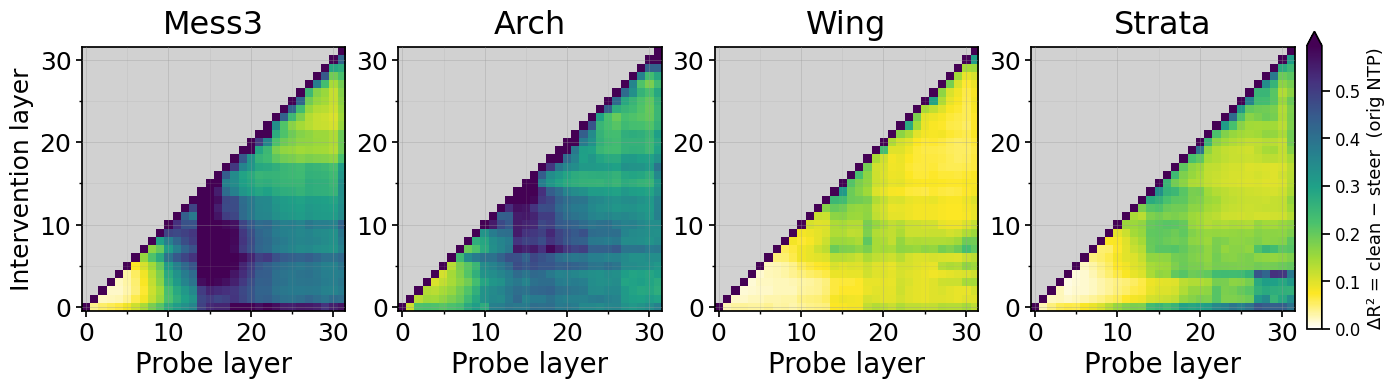

wrote: plots/destroy_gap_qwen35_9b_ntp_new.pdf


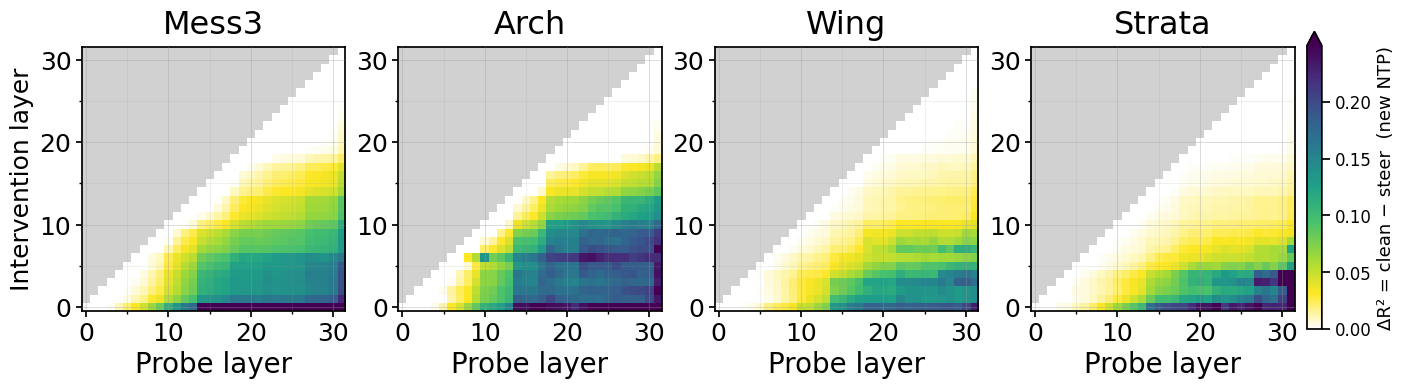

wrote: plots/destroy_gap_qwen35_9b_log_ntp_orig.pdf


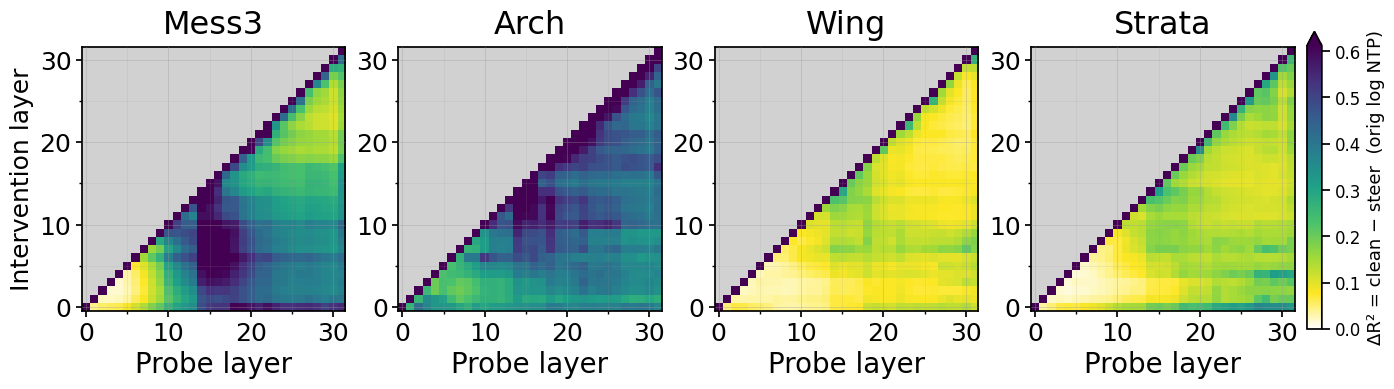

wrote: plots/destroy_gap_qwen35_9b_log_ntp_new.pdf


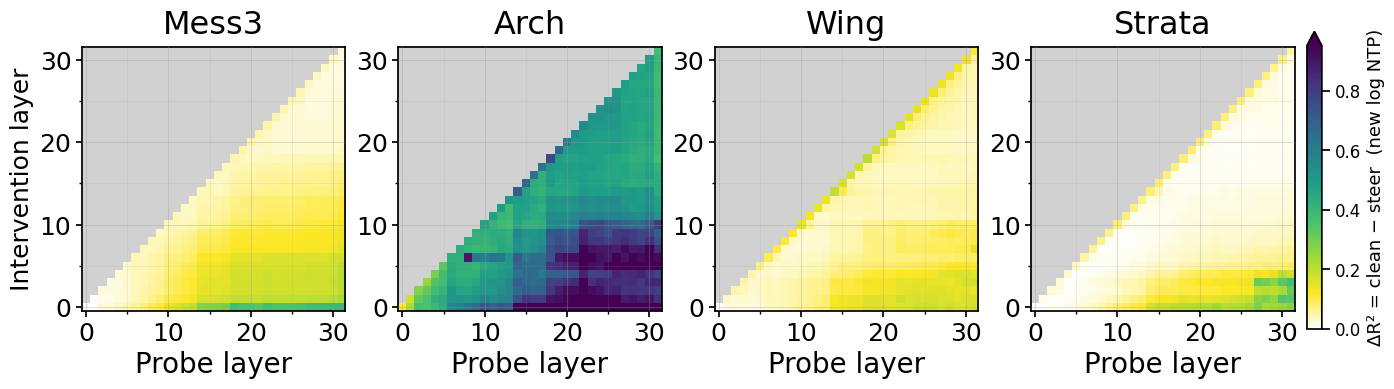

wrote: plots/destroy_gap_qwen35_4b_ntp_orig.pdf


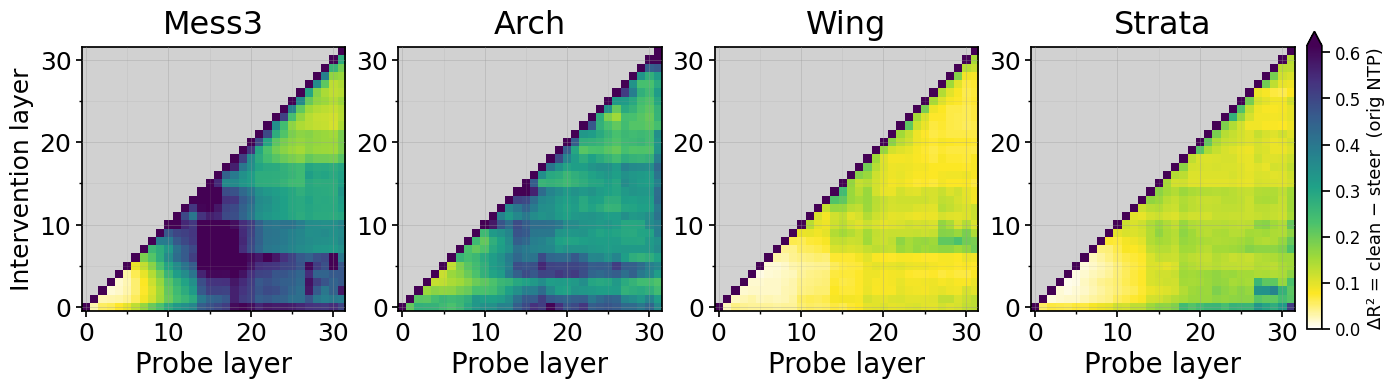

wrote: plots/destroy_gap_qwen35_4b_ntp_new.pdf


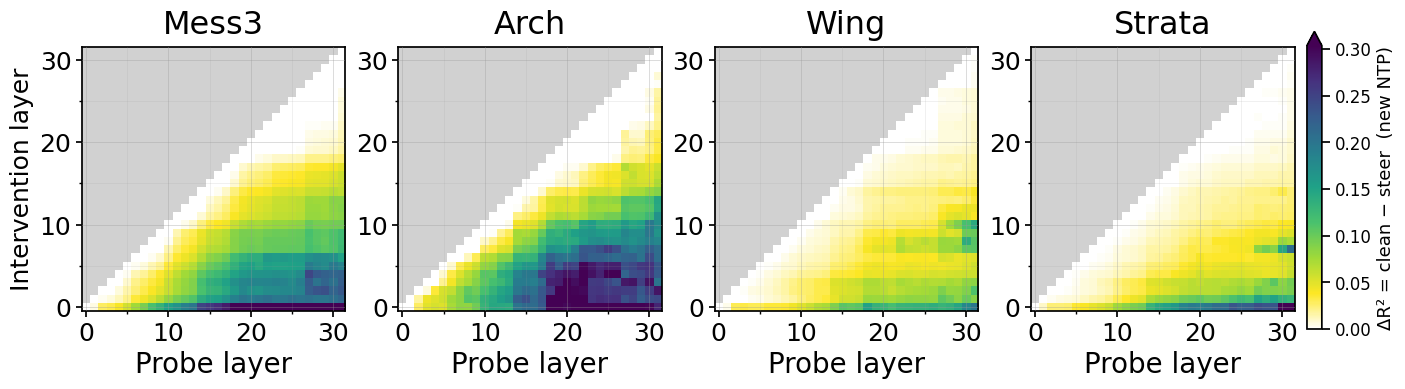

wrote: plots/destroy_gap_qwen35_4b_log_ntp_orig.pdf


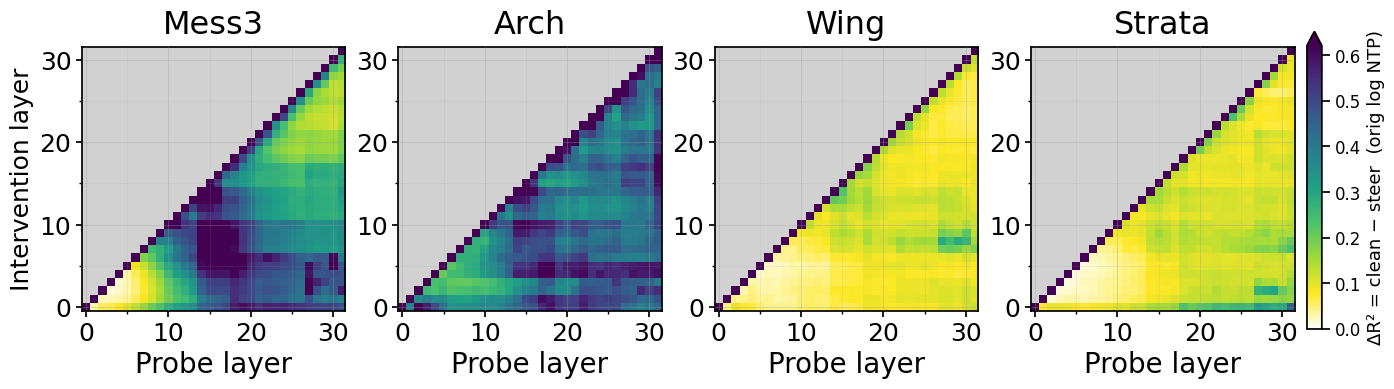

wrote: plots/destroy_gap_qwen35_4b_log_ntp_new.pdf


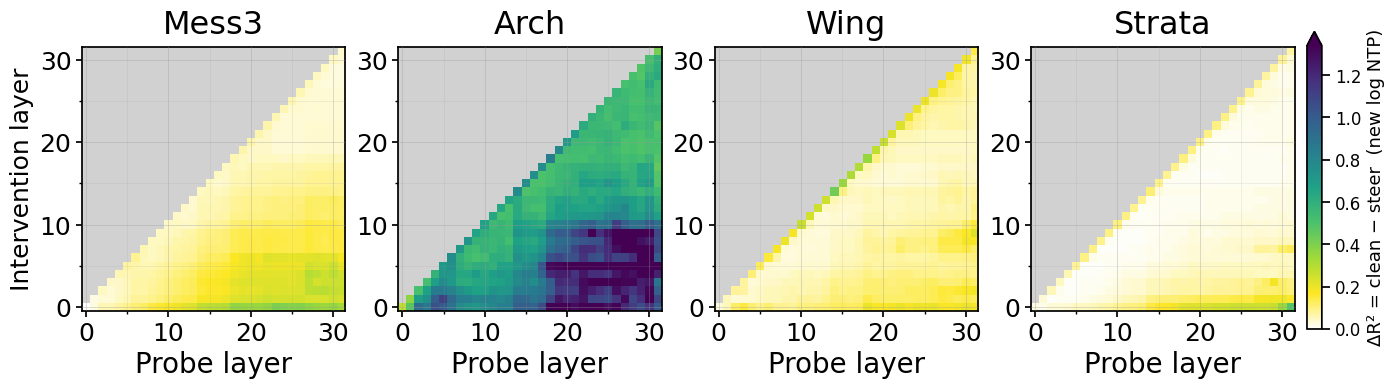

wrote: plots/destroy_gap_llama_31_8b_ntp_orig.pdf


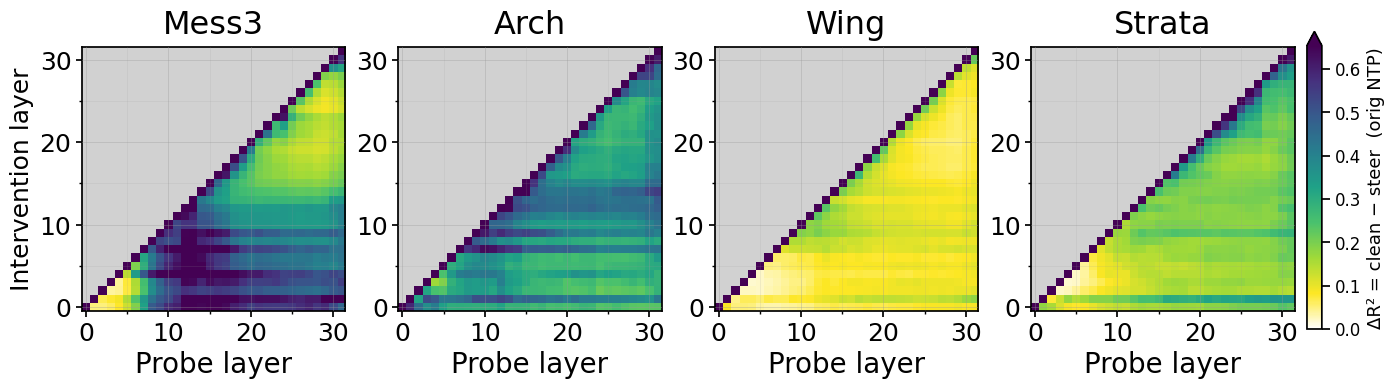

wrote: plots/destroy_gap_llama_31_8b_ntp_new.pdf


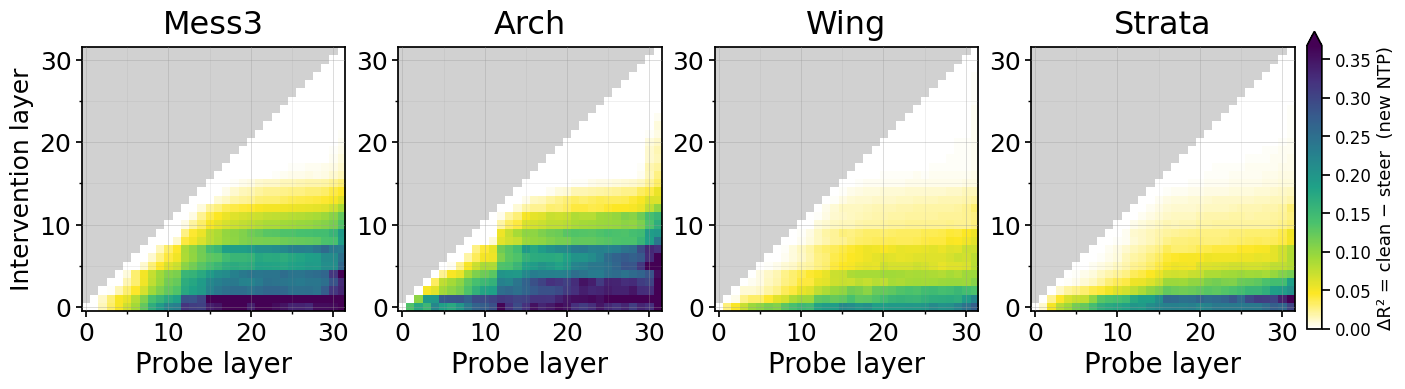

wrote: plots/destroy_gap_llama_31_8b_log_ntp_orig.pdf


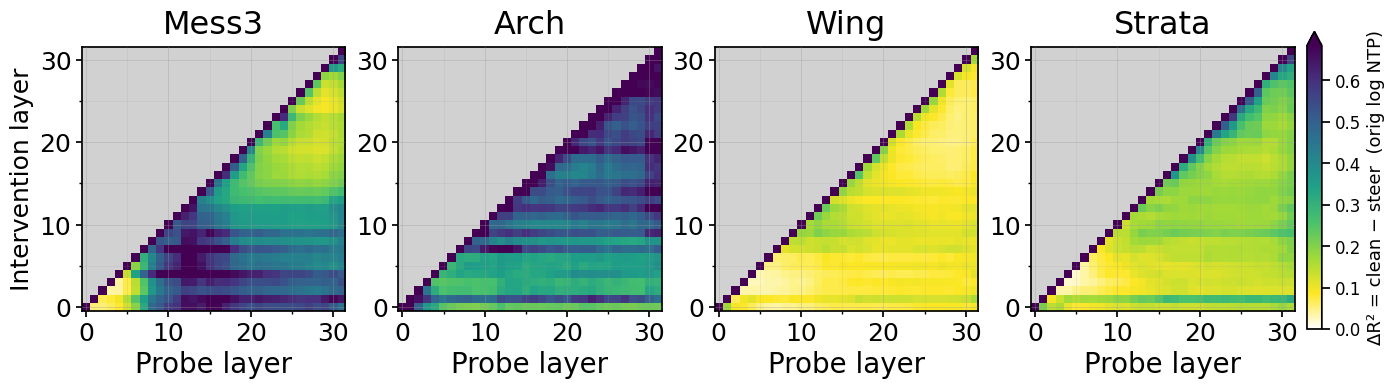

wrote: plots/destroy_gap_llama_31_8b_log_ntp_new.pdf


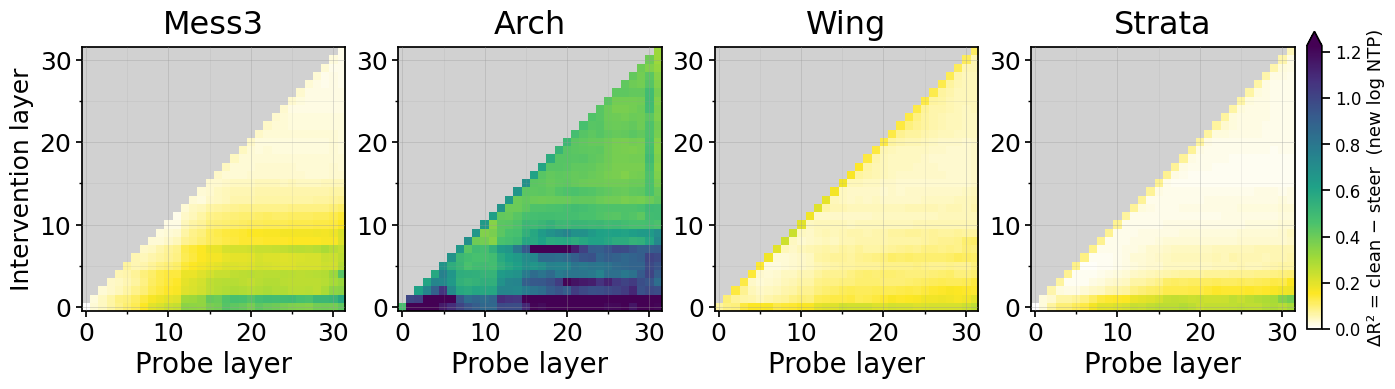

wrote: plots/destroy_gap_llama_32_3b_ntp_orig.pdf


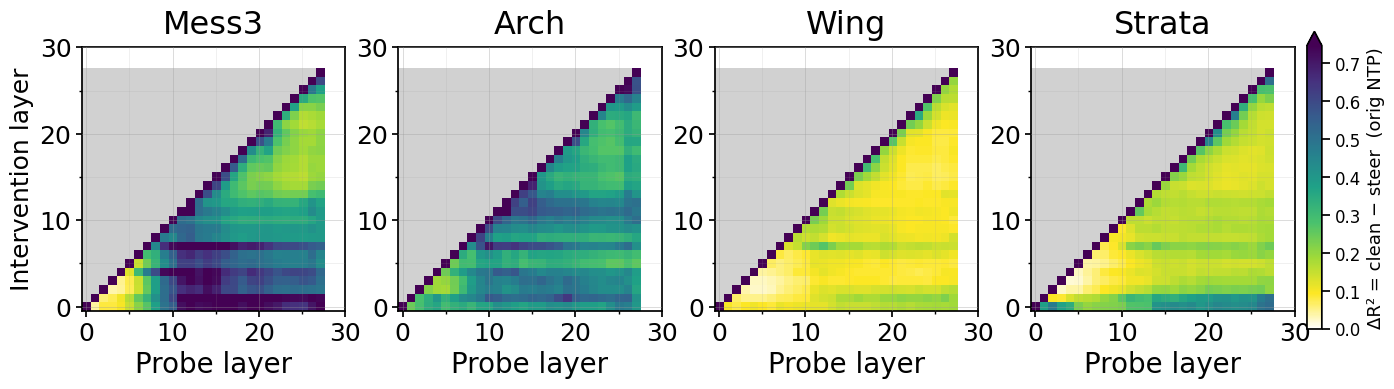

wrote: plots/destroy_gap_llama_32_3b_ntp_new.pdf


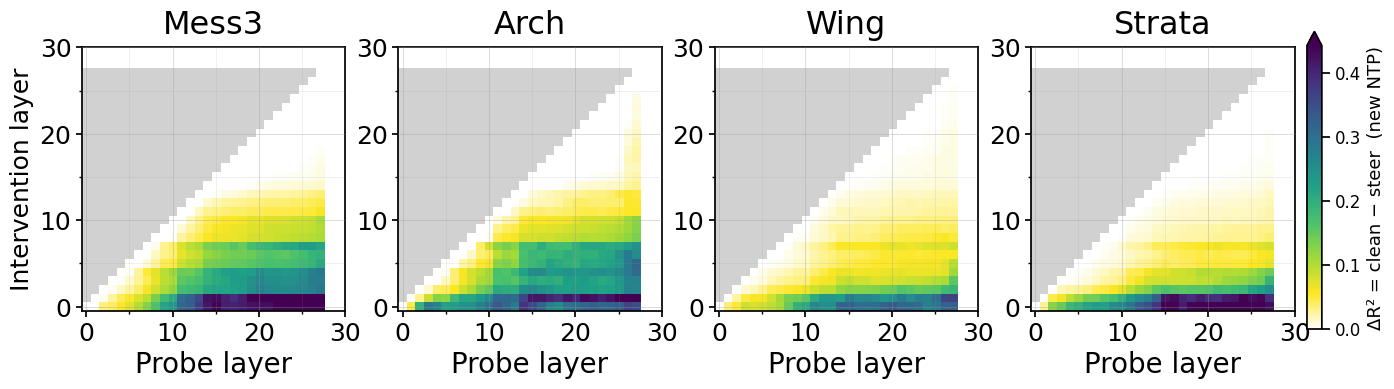

wrote: plots/destroy_gap_llama_32_3b_log_ntp_orig.pdf


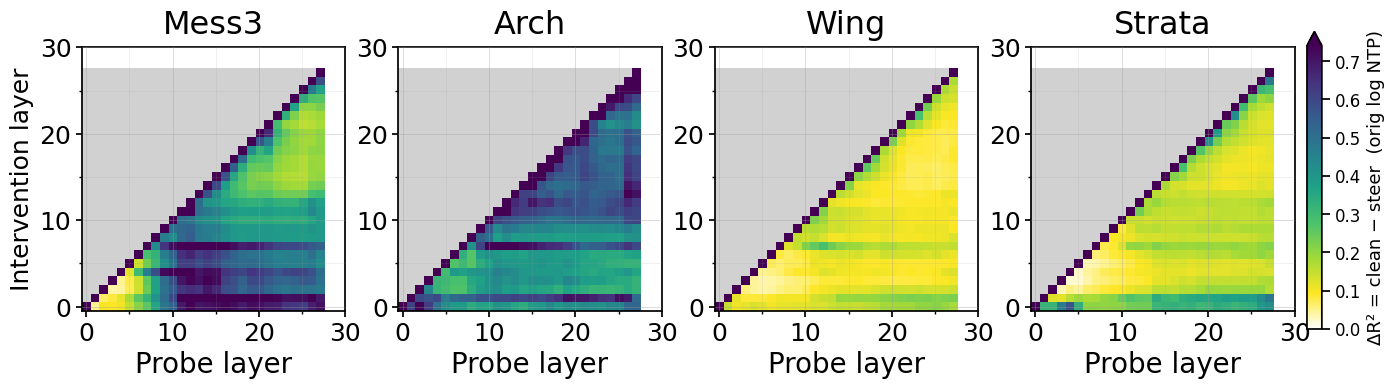

KeyboardInterrupt: 

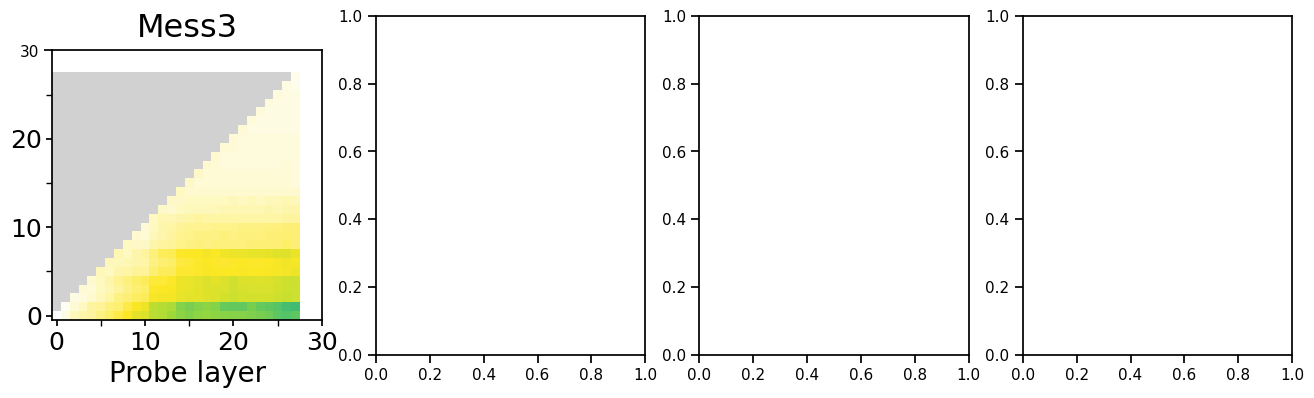

In [ ]:
# Self-contained: run after cell 0, or on its own.
import os
import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt, seaborn as sns
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.ticker import MultipleLocator

RESULTS_DIR = '../results'; PLOT_DIR = 'plots'; os.makedirs(PLOT_DIR, exist_ok=True)
MODEL_KEYS = ['qwen35_9b', 'qwen35_4b', 'llama_31_8b', 'llama_32_3b', 'gemma_4_e4b', 'gemma_4_e2b']
TARGETS = [('Mess3','a=0.01, x=0.02'), ('Arch','a=0.99'),
           ('Wing','a=0.98, x=0.4'), ('Strata','a=0.97, t0=0.38, t1=0.54')]
matplotlib.rcParams.update({'font.family':'sans-serif','font.sans-serif':['DejaVu Sans'],'font.weight':'light'})
sns.set_context('notebook')
OBS_TARGET = {'ntp':'act→ntp', 'log_ntp':'act→log_ntp', 'belief':'act→beliefs'}
PRETTY = {'ntp':'NTP', 'log_ntp':'log NTP', 'belief':'beliefs'}

def destroy_gap_heatmap(model_key, tk='ntp', ref='orig', save=True):
    """ΔR² = clean(r) − R²_steer over intervention layer L (y) × decode layer (x).
    white_viridis: white = ΔR²≈0 (decoded as well as clean), → yellow → … → dark purple = large gap."""
    dd = pd.read_csv(f'{RESULTS_DIR}/decode_destroy_{model_key}.csv')
    ob = pd.read_csv(f'{RESULTS_DIR}/obsprob_{model_key}.csv')
    dd = dd[(dd.target_kind == tk) & (dd.ref == ref) & (dd.hmm != 'Spiral')]
    _vir = plt.get_cmap('viridis')
    cmap_g = LinearSegmentedColormap.from_list(
        'white_viridis', [(1, 1, 1)] + [_vir(x) for x in np.linspace(1.0, 0.0, 8)])
    cmap_g.set_bad('0.82')
    cleans = {hp: ob[(ob.hmm == hp[0]) & (ob.param == hp[1]) & (ob.target == OBS_TARGET[tk])]
              .groupby('layer')['R2'].mean() for hp in TARGETS}

    gap_pool, mats = [], {}
    for hmm, param in TARGETS:
        cell = dd[(dd.hmm == hmm) & (dd.param == param)]; clean = cleans[(hmm, param)]
        Ls = sorted(cell.intervene_layer.unique()); Rs = sorted(cell.readout_layer.unique())
        li = {L: j for j, L in enumerate(Ls)}; ri = {r: j for j, r in enumerate(Rs)}
        G = np.full((len(Ls), len(Rs)), np.nan)
        for (L, r), v in cell.groupby(['intervene_layer', 'readout_layer'])['value'].mean().items():
            G[li[L], ri[r]] = clean.get(r, np.nan) - v
            if r >= L + 2: gap_pool.append(clean.get(r, np.nan) - v)
        mats[(hmm, param)] = (G, Ls, Rs)
    norm_g = Normalize(0, np.nanpercentile(gap_pool, 98))

    fig, axes = plt.subplots(1, len(TARGETS), figsize=(16, 4.4))
    for i, (hmm, param) in enumerate(TARGETS):
        G, Ls, Rs = mats[(hmm, param)]; ax = axes[i]
        ext = [Rs[0]-.5, Rs[-1]+.5, Ls[0]-.5, Ls[-1]+.5]
        ax.imshow(G, origin='lower', aspect='auto', cmap=cmap_g, norm=norm_g, extent=ext)
        ax.set_box_aspect(1)
        ax.set_title(hmm, fontsize=23, pad=10)
        ax.set_xlabel('Probe layer', fontsize=20)
        ax.set_xticks([0, 10, 20, 30]); ax.set_yticks([0, 10, 20, 30])
        ax.xaxis.set_minor_locator(MultipleLocator(5)); ax.yaxis.set_minor_locator(MultipleLocator(5))
        ax.tick_params(which='major', labelsize=18, length=4)
        ax.tick_params(which='minor', length=2)
        ax.set_axisbelow(False)
        ax.grid(True, which='major', color='0.6', alpha=0.4, lw=0.6)
        ax.grid(True, which='minor', color='0.6', alpha=0.25, lw=0.4)
        if i == 0: ax.set_ylabel('Intervention layer', fontsize=18)

    sm = ScalarMappable(cmap=cmap_g, norm=norm_g); sm.set_array([])
    cb = fig.colorbar(sm, ax=list(axes), fraction=0.012, pad=0.01, extend='max')
    cb.set_label(f'ΔR² = R² − steer  ({ref} {PRETTY[tk]})', fontsize=13); cb.ax.tick_params(labelsize=12)
    if save:
        out = f'{PLOT_DIR}/destroy_gap_{model_key}_{tk}_{ref}.pdf'
        fig.savefig(out, bbox_inches='tight'); print('wrote:', out)
    plt.show(); plt.close(fig)

for mk in MODEL_KEYS:
    for tk in ['ntp', 'log_ntp']:
        for ref in ['orig', 'new']:
            destroy_gap_heatmap(mk, tk=tk, ref=ref)

wrote: plots/destroy_aligned_delta_qwen35_9b_ntp.pdf


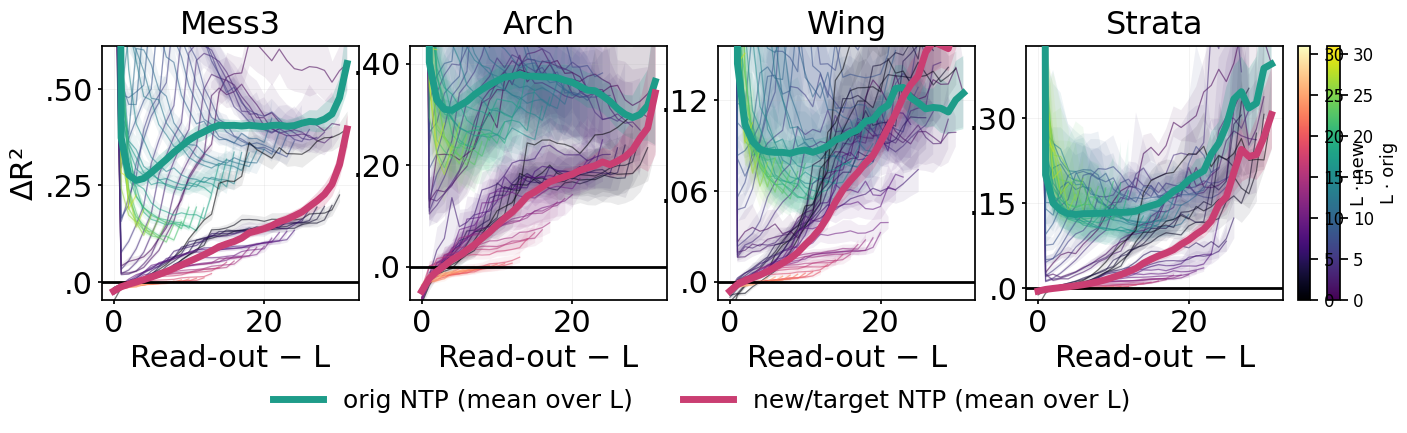

wrote: plots/destroy_aligned_delta_qwen35_9b_log_ntp.pdf


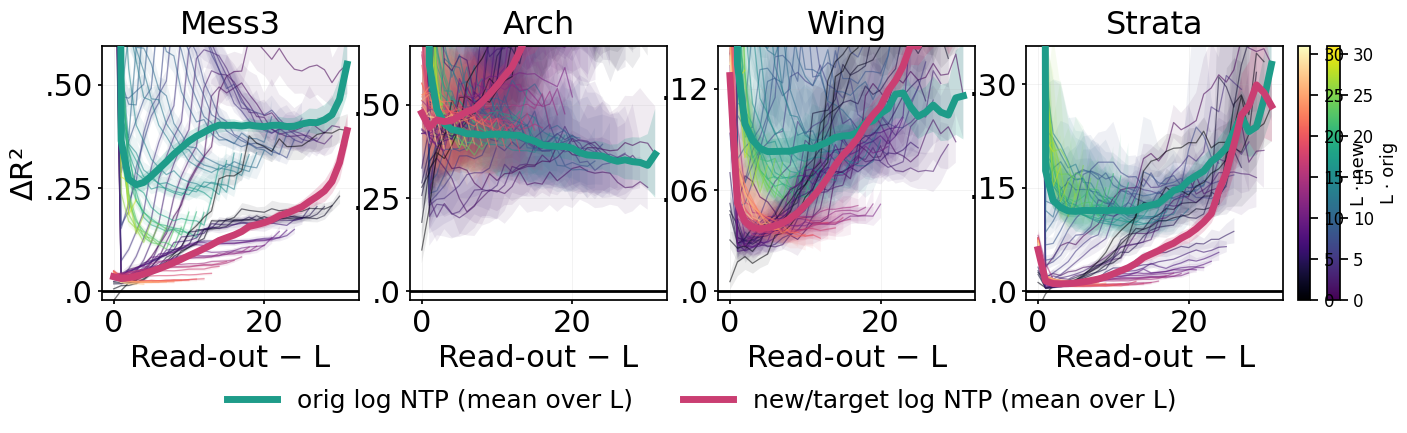

KeyboardInterrupt: 

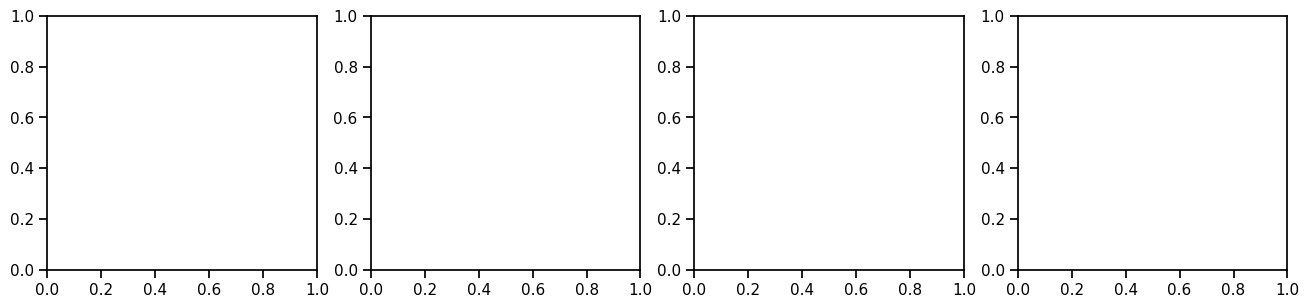

In [11]:
# Self-contained: run after cell 0, or on its own.
import os
import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt, seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

RESULTS_DIR = '../results'; PLOT_DIR = 'plots'; os.makedirs(PLOT_DIR, exist_ok=True)
MODEL_KEYS = ['qwen35_9b', 'qwen35_4b', 'llama_31_8b', 'llama_32_3b', 'gemma_4_e4b', 'gemma_4_e2b']
TARGETS = [('Mess3','a=0.01, x=0.02'), ('Arch','a=0.99'),
           ('Wing','a=0.98, x=0.4'), ('Strata','a=0.97, t0=0.38, t1=0.54')]
matplotlib.rcParams.update({'font.family':'sans-serif','font.sans-serif':['DejaVu Sans'],'font.weight':'light'})
sns.set_context('notebook')

ORIG_CMAP, NEW_CMAP = 'viridis', 'magma'          # NEW_CMAP = the contrasting one; swap freely

def fmt_tick(v):
    s = f'{v:.1f}' if v == int(v) else f'{v:.2f}'
    if '.' in s and -1 < v < 1: s = s.lstrip('0')
    return s
OBS_TARGET = {'ntp':'act→ntp', 'log_ntp':'act→log_ntp', 'belief':'act→beliefs'}
PRETTY = {'ntp':'NTP', 'log_ntp':'log NTP', 'belief':'beliefs'}

def destroy_aligned_delta(model_key, tk='ntp', save=True):
    """x = read-out − intervention (Δ; 0 = intervention layer). hue = intervention layer L.
    y = ΔR² = R²_clean(read-out) − R²_steer. Seaborn aggregates the 10 seeds (mean + 95% CI).
    viridis = orig NTP per-L; magma = new/target NTP per-L; thick lines = mean over L."""
    dd = pd.read_csv(f'{RESULTS_DIR}/decode_destroy_{model_key}.csv')
    ob = pd.read_csv(f'{RESULTS_DIR}/obsprob_{model_key}.csv')
    dd = dd[(dd.target_kind == tk) & (dd.hmm != 'Spiral')]
    Ls = sorted(dd.intervene_layer.unique()); hn = (min(Ls), max(Ls))
    orig_mean_c = plt.get_cmap(ORIG_CMAP)(0.55); new_mean_c = plt.get_cmap(NEW_CMAP)(0.55)

    fig, axes = plt.subplots(1, len(TARGETS), figsize=(16, 3.3))
    for i, (hmm, param) in enumerate(TARGETS):
        ax = axes[i]
        cell = dd[(dd.hmm == hmm) & (dd.param == param)].copy()
        clean = (ob[(ob.hmm == hmm) & (ob.param == param) & (ob.target == OBS_TARGET[tk])]
                 .groupby('layer')['R2'].mean())
        cell['delta'] = cell.readout_layer - cell.intervene_layer
        cell['delta_r2'] = cell.readout_layer.map(clean) - cell['value']
        orig = cell[cell.ref == 'orig']; new = cell[cell.ref == 'new']

        # faint per-L lines + 95% CI over seeds, one colormap per ref
        for df_, cmp_ in [(orig, ORIG_CMAP), (new, NEW_CMAP)]:
            sns.lineplot(data=df_, x='delta', y='delta_r2', hue='intervene_layer',
                         palette=cmp_, hue_norm=hn, legend=False, errorbar=('ci', 95),
                         n_boot=300, lw=0.9, alpha=0.55, err_kws={'alpha': 0.08, 'lw': 0}, ax=ax)
        # means over L
        sns.lineplot(data=orig, x='delta', y='delta_r2', errorbar=('ci', 95), n_boot=300,
                     color=orig_mean_c, lw=5, err_kws={'alpha': 0.2, 'lw': 0}, ax=ax, zorder=20)
        sns.lineplot(data=new, x='delta', y='delta_r2', errorbar=('ci', 95), n_boot=300,
                     color=new_mean_c, lw=5, err_kws={'alpha': 0.2, 'lw': 0}, ax=ax, zorder=21)
        ax.axhline(0, color='black', lw=2, zorder=10)

        gm = orig.groupby('delta')['delta_r2'].mean(); nm = new.groupby('delta')['delta_r2'].mean()
        top = gm[gm.index >= 1].max(); bot = min(0.0, gm.min(), nm.min())
        ax.set_ylim(bot - 0.04*(top-bot), top*1.08)
        ax.set_title(hmm, fontsize=23, pad=18, y=0.95)
        ax.set_xlabel('Read-out − L', fontsize=22); ax.set_ylabel('')
        ax.tick_params(axis='both', labelsize=22, length=3); ax.grid(True, alpha=0.2, linewidth=0.5)
        ax.yaxis.set_major_locator(MaxNLocator(nbins=3, min_n_ticks=3))
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: fmt_tick(v)))
        if i == 0: ax.set_ylabel('ΔR²', fontsize=22)

    norm = Normalize(*hn)
    for cmp_, lab in [(ORIG_CMAP, 'L · orig'), (NEW_CMAP, 'L · new')]:
        sm = ScalarMappable(cmap=cmp_, norm=norm); sm.set_array([])
        cb = fig.colorbar(sm, ax=list(axes), fraction=0.012, pad=0.012)
        cb.set_label(lab, fontsize=13); cb.ax.tick_params(labelsize=12)
    fig.legend(handles=[Line2D([], [], color=orig_mean_c, lw=5), Line2D([], [], color=new_mean_c, lw=5)],
               labels=[f'orig {PRETTY[tk]} (mean over L)', f'new/target {PRETTY[tk]} (mean over L)'],
               loc='lower center', ncol=2, fontsize=18, frameon=False, bbox_to_anchor=(0.5, -0.30))
    if save:
        out = f'{PLOT_DIR}/destroy_aligned_delta_{model_key}_{tk}.pdf'
        fig.savefig(out, bbox_inches='tight'); print('wrote:', out)
    plt.show(); plt.close(fig)

for mk in MODEL_KEYS:
    for tk in ['ntp', 'log_ntp']:
        destroy_aligned_delta(mk, tk=tk)